In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
data_path = ['..', '..', 'data']

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
data = pd.read_csv('/content/drive/MyDrive/ML/dataset.csv')
#data = pd.read_csv('/content/drive/MyDrive/ObesityDataSet.csv')

In [3]:
print(f"\nDataset Information:")
print(f"  Shape: {data.shape}")
print(f"  Rows: {data.shape[0]}")
print(f"  Columns: {data.shape[1]}")
print(f"\nColumn names:")
for i, col in enumerate(data.columns, 1):
    print(f"  {i:2d}. {col}")


Dataset Information:
  Shape: (2111, 17)
  Rows: 2111
  Columns: 17

Column names:
   1. Age
   2. Gender
   3. Height
   4. Weight
   5. CALC
   6. FAVC
   7. FCVC
   8. NCP
   9. SCC
  10. SMOKE
  11. CH2O
  12. family_history_with_overweight
  13. FAF
  14. TUE
  15. CAEC
  16. MTRANS
  17. NObeyesdad


In [4]:
print("\nColumn names and types:")
print(data.dtypes)


Column names and types:
Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64
NCP                               float64
SCC                                object
SMOKE                              object
CH2O                              float64
family_history_with_overweight     object
FAF                               float64
TUE                               float64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


Data quality assessment

In [5]:
missing_values = data.isnull().sum()
total_missing = missing_values.sum()
missing_percentage = (missing_values / len(data)) * 100

In [6]:
print(f"\nMissing Values Analysis:")
print(f"Total missing values: {total_missing}")
print(f"Percentage of dataset with missing values: {(total_missing/(data.shape[0]*data.shape[1])*100):.2f}%")


Missing Values Analysis:
Total missing values: 0
Percentage of dataset with missing values: 0.00%


In [7]:
if total_missing > 0:
    print("\nColumns with missing values:")
    missing_df = pd.DataFrame({
        'Column': missing_values[missing_values > 0].index,
        'Missing_Count': missing_values[missing_values > 0].values,
        'Percentage': missing_percentage[missing_values > 0].values
    })
    print(missing_df.to_string(index=False))

In [8]:
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 24


In [9]:
print("\nData Statistics (before cleaning):")
print(data.describe())


Data Statistics (before cleaning):
               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000

Data Cleaning

In [10]:
# Remove duplicates
if duplicates > 0:
    data = data.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")
    print(f"New shape: {data.shape}")

Removed 24 duplicate rows
New shape: (2087, 17)


In [11]:
# Handle missing values
if total_missing > 0:
    print("\nHandling missing values...")

    # Identify column types
    numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

    # Impute numerical columns with median
    if numerical_cols:
        numerical_imputer = SimpleImputer(strategy='median')
        data[numerical_cols] = numerical_imputer.fit_transform(data[numerical_cols])
        print(f"Imputed {len(numerical_cols)} numerical columns with median")

    # Impute categorical columns with mode
    if categorical_cols:
        categorical_imputer = SimpleImputer(strategy='most_frequent')
        data[categorical_cols] = categorical_imputer.fit_transform(data[categorical_cols])
        print(f"Imputed {len(categorical_cols)} categorical columns with mode")

    print(f"Missing values after imputation: {data.isnull().sum().sum()}")
else:
    print("No missing values found")

No missing values found


In [12]:
print(f"Clean dataset shape: {data.shape}")

Clean dataset shape: (2087, 17)


Feature Engineering

In [13]:
# Calculate BMI
if 'Height' in data.columns and 'Weight' in data.columns:
    data['BMI'] = data['Weight'] / (data['Height'] ** 2)
    print("Created BMI feature")
    print(f"   BMI Statistics:")
    print(f"   • Range: [{data['BMI'].min():.2f}, {data['BMI'].max():.2f}]")
    print(f"   • Mean ± Std: {data['BMI'].mean():.2f} ± {data['BMI'].std():.2f}")

    # BMI Categories (WHO standards)
    bmi_categories = pd.cut(data['BMI'],
                            bins=[0, 18.5, 25, 30, 35, 40, 100],
                            labels=['Underweight', 'Normal', 'Overweight',
                                   'Obese_I', 'Obese_II', 'Obese_III'])
    print("\n   BMI Category Distribution:")
    for category, count in bmi_categories.value_counts().sort_index().items():
        print(f"   • {category}: {count} ({count/len(bmi_categories)*100:.1f}%)")

Created BMI feature
   BMI Statistics:
   • Range: [13.00, 50.81]
   • Mean ± Std: 29.77 ± 8.02

   BMI Category Distribution:
   • Underweight: 266 (12.7%)
   • Normal: 295 (14.1%)
   • Overweight: 552 (26.4%)
   • Obese_I: 368 (17.6%)
   • Obese_II: 338 (16.2%)
   • Obese_III: 268 (12.8%)


In [14]:
# Features
print("\nFeatures Components:")
print("\n1. Demographics:")
print("   - Age: Affects metabolism and recommendation applicability")
print("   - Gender: Influences fat distribution and caloric requirements")
print("   - Height: Used for BMI calculation")
print("   - Weight: Used for BMI calculation")

print("\n2. Diet and Consumption:")
print("   - CALC: Frequency of caloric intake (Categorical)")
print("   - FAVC: Frequent consumption of high-calorie foods (Categorical)")
print("   - FCVC: Frequency of vegetable consumption (Numerical)")
print("   - NCP: Number of main meals (Numerical)")
print("   - SCC: Consumption of sugary beverages (Binary)")
print("   - CH2O: Daily water intake in liters (Numerical)")
print("   - CAEC: Consumption of food between meals (Categorical)")

print("\n3. Lifestyle:")
print("   - SMOKE: Smoking habits (Binary)")
print("   - TUE: Time using technology devices (Numerical)")
print("   - MTRANS: Transportation method (Categorical)")
print("   - FAF: Frequency of physical activity (Numerical)")

print("\n4. Other:")
print("   - family_history_with_overweight: Family history (Binary)")
print("   - NObeyesdad: Obesity level - TARGET VARIABLE (Categorical)")


Features Components:

1. Demographics:
   - Age: Affects metabolism and recommendation applicability
   - Gender: Influences fat distribution and caloric requirements
   - Height: Used for BMI calculation
   - Weight: Used for BMI calculation

2. Diet and Consumption:
   - CALC: Frequency of caloric intake (Categorical)
   - FAVC: Frequent consumption of high-calorie foods (Categorical)
   - FCVC: Frequency of vegetable consumption (Numerical)
   - NCP: Number of main meals (Numerical)
   - SCC: Consumption of sugary beverages (Binary)
   - CH2O: Daily water intake in liters (Numerical)
   - CAEC: Consumption of food between meals (Categorical)

3. Lifestyle:
   - SMOKE: Smoking habits (Binary)
   - TUE: Time using technology devices (Numerical)
   - MTRANS: Transportation method (Categorical)
   - FAF: Frequency of physical activity (Numerical)

4. Other:
   - family_history_with_overweight: Family history (Binary)
   - NObeyesdad: Obesity level - TARGET VARIABLE (Categorical)


Encode Categorical Variables

In [15]:
# Binary Features (yes/no → 1/0)
binary_features = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
print("\nEncoding binary features:")
for feature in binary_features:
    if feature in data.columns:
        unique_vals = data[feature].unique()
        print(f"  {feature}: {unique_vals}")
        # Map yes/no to 1/0
        data[feature] = data[feature].map({'yes': 1, 'no': 0})

        if data[feature].isnull().sum() > 0:
            print(f"    Warning: {feature} has unmapped values")

            for val in unique_vals:
                if val not in ['yes', 'no']:
                    print(f"    Mapping '{val}' to 0")
                    data.loc[data_original[feature] == val, feature] = 0
        print(f"  {feature}: encoded (yes=1, no=0)")


Encoding binary features:
  family_history_with_overweight: ['yes' 'no']
  family_history_with_overweight: encoded (yes=1, no=0)
  FAVC: ['no' 'yes']
  FAVC: encoded (yes=1, no=0)
  SMOKE: ['no' 'yes']
  SMOKE: encoded (yes=1, no=0)
  SCC: ['no' 'yes']
  SCC: encoded (yes=1, no=0)


In [16]:
# Ordinal Features (ordered categories)
ordinal_mappings = {
    'CAEC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'CALC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
}

for col, mapping in ordinal_mappings.items():
    if col in data.columns:
        unique_vals = data[col].unique()
        print(f"   {col}: {unique_vals}")
        data[col] = data[col].map(mapping)
        if data[col].isnull().sum() > 0:
            data[col].fillna(0, inplace=True)
        print(f"   Encoded {col}")

   CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
   Encoded CAEC
   CALC: ['no' 'Sometimes' 'Frequently' 'Always']
   Encoded CALC


In [17]:
# Nominal Features (no order)
nominal_cols = ['Gender', 'MTRANS']
for col in nominal_cols:
    if col in data.columns:
        unique_vals = data[col].unique()
        print(f"   {col}: {unique_vals}")
        dummies = pd.get_dummies(data[col], prefix=col, drop_first=False)
        data = pd.concat([data, dummies], axis=1)
        data.drop(col, axis=1, inplace=True)
        print(f"   Created {len(dummies.columns)} columns for {col}")

   Gender: ['Female' 'Male']
   Created 2 columns for Gender
   MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
   Created 5 columns for MTRANS


In [18]:
# Target Variable (NObeyesdad)
if 'NObeyesdad' in data.columns:
    unique_obesity = data['NObeyesdad'].unique()
    print(f"   Unique obesity levels: {unique_obesity}")

    label_encoder = LabelEncoder()
    data['NObeyesdad_encoded'] = label_encoder.fit_transform(data['NObeyesdad'])

    target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print("\n   Obesity Level Mapping:")
    for level, code in sorted(target_mapping.items(), key=lambda x: x[1]):
        count = (data['NObeyesdad_encoded'] == code).sum()
        print(f"   {code}: {level:25s} ({count} samples)")

   Unique obesity levels: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']

   Obesity Level Mapping:
   0: Insufficient_Weight       (267 samples)
   1: Normal_Weight             (282 samples)
   2: Obesity_Type_I            (351 samples)
   3: Obesity_Type_II           (297 samples)
   4: Obesity_Type_III          (324 samples)
   5: Overweight_Level_I        (276 samples)
   6: Overweight_Level_II       (290 samples)


In [19]:
print(f"\nEncoded Dataset Shape: {data.shape}")


Encoded Dataset Shape: (2087, 24)


/tmp/ipython-input-1230836614.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
/tmp/ipython-input-1230836614.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='NObeyesdad', y='FAF', ax=ax, palette='pastel')
/tmp/ipython-input-1230836614.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipython-input-1230836614.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)


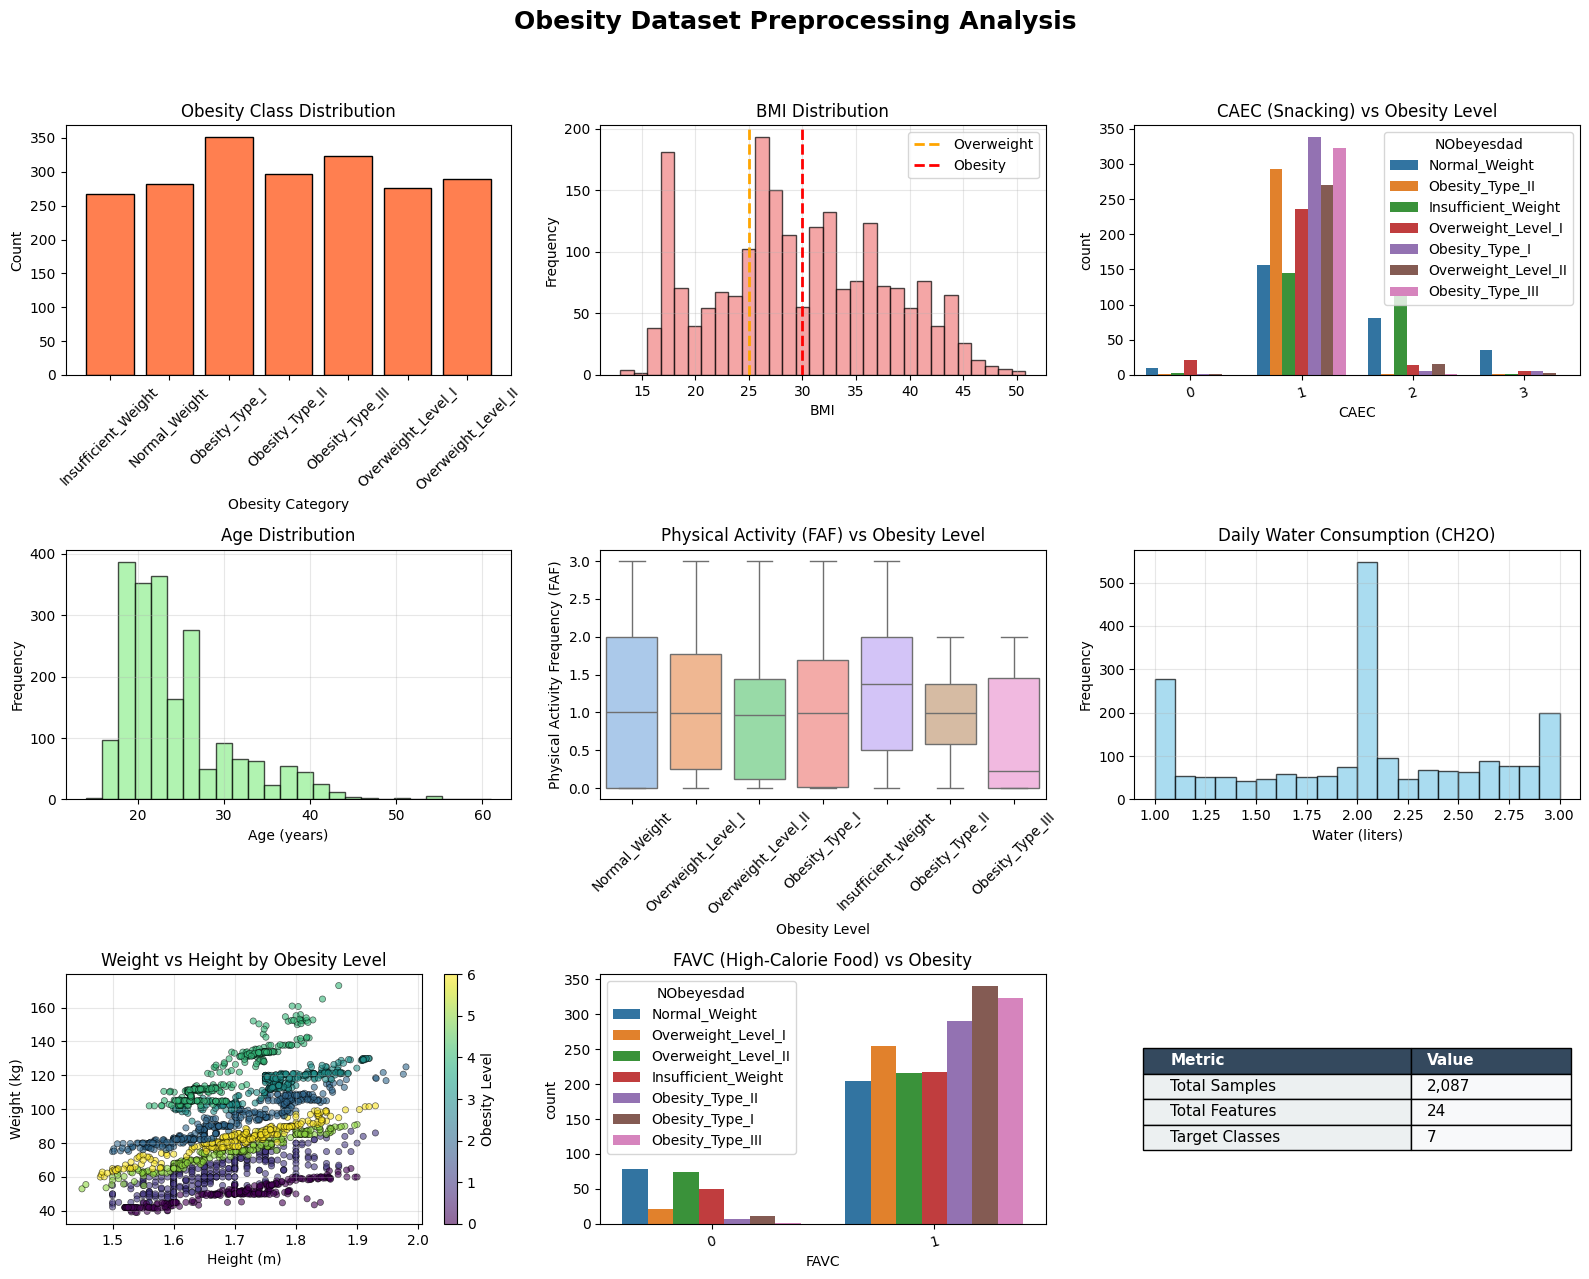

In [20]:
class_names = np.unique(data['NObeyesdad'])
class_counts = data['NObeyesdad'].value_counts().sort_index()

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Obesity Dataset Preprocessing Analysis', fontsize=18, fontweight='bold')

# === 1. Class Distribution ===
ax = axes[0, 0]
ax.bar(class_names, class_counts.values, color='coral', edgecolor='black')
ax.set_title('Obesity Class Distribution')
ax.set_xlabel('Obesity Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# === 2. BMI Distribution ===
ax = axes[0, 1]
if 'BMI' in data.columns:
    data['BMI'].hist(bins=30, ax=ax, color='lightcoral', edgecolor='black', alpha=0.7)
    ax.axvline(25, color='orange', linestyle='--', label='Overweight', linewidth=2)
    ax.axvline(30, color='red', linestyle='--', label='Obesity', linewidth=2)
    ax.set_title('BMI Distribution')
    ax.set_xlabel('BMI')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

# === 3. CAEC vs Obesity ===
ax = axes[0, 2]
if 'CAEC' in data.columns:
    sns.countplot(data=data, x='CAEC', hue='NObeyesdad', ax=ax)
    ax.set_title('CAEC (Snacking) vs Obesity Level')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

# === 4. Age Distribution ===
ax = axes[1, 0]
if 'Age' in data.columns:
    data['Age'].hist(bins=25, ax=ax, color='lightgreen', edgecolor='black', alpha=0.7)
    ax.set_title('Age Distribution')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# === 5. FAF vs Obesity Level ===
ax = axes[1, 1]
if 'FAF' in data.columns:
    sns.boxplot(data=data, x='NObeyesdad', y='FAF', ax=ax, palette='pastel')
    ax.set_title('Physical Activity (FAF) vs Obesity Level')
    ax.set_xlabel('Obesity Level')
    ax.set_ylabel('Physical Activity Frequency (FAF)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# === 6. CH2O Water Consumption ===
ax = axes[1, 2]
if 'CH2O' in data.columns:
    data['CH2O'].hist(bins=20, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title('Daily Water Consumption (CH2O)')
    ax.set_xlabel('Water (liters)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# === 7. Height vs Weight Scatter ===
ax = axes[2, 0]
if 'Weight' in data.columns and 'Height' in data.columns:
    scatter = ax.scatter(data['Height'], data['Weight'],
                         c=data['NObeyesdad_encoded'], cmap='viridis',
                         alpha=0.6, s=20, edgecolors='black', linewidth=0.5)
    ax.set_title('Weight vs Height by Obesity Level')
    ax.set_xlabel('Height (m)')
    ax.set_ylabel('Weight (kg)')
    plt.colorbar(scatter, ax=ax, label='Obesity Level')
    ax.grid(True, alpha=0.3)

# === 8. FAVC (High-Calorie Food) vs Obesity ===
ax = axes[2, 1]
if 'FAVC' in data.columns:
    sns.countplot(data=data, x='FAVC', hue='NObeyesdad', ax=ax)
    ax.set_title('FAVC (High-Calorie Food) vs Obesity')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

# === 9. Summary Table ===
ax = axes[2, 2]
ax.axis('tight')
ax.axis('off')
summary_data = [
    ['Metric', 'Value'],
    ['Total Samples', f'{len(data):,}'],
    ['Total Features', f'{data.shape[1]}'],
    ['Target Classes', f'{len(class_names)}']
]
table = ax.table(cellText=summary_data, cellLoc='left', loc='center',
                 colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
# Header row
for i in range(2):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')
# Data rows
for i in range(1, len(summary_data)):
    table[(i, 0)].set_facecolor('#ecf0f1')
    table[(i, 1)].set_facecolor('#f8f9fa')

# === Layout ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [21]:
!pip install "stable-baselines3[extra]" gymnasium
!pip install import-ipynb

**ENV**

In [22]:
import numpy as np
from typing import Dict, Any, Optional, Union, Tuple

# Gym/Gymnasium compatibility
try:
    import gymnasium as gym
    from gymnasium import spaces
    GYMNASIUM = True
except Exception:
    import gym
    from gym import spaces
    GYMNASIUM = False


class HealthCoachEnv(gym.Env):
    """
    Key upgrades:
    - Multi-objective dense reward (class change + BMI distance + lifestyle score)
    - Delayed effects & momentum in BMI dynamics (EMA of lifestyle, weight inertia)
    - Stochastic compliance (patient may only partially follow recommendations)
    - Configurable difficulty modes ("easy"/"medium"/"hard")
    - Optional random events (e.g., holiday/illness) that perturb behaviors
    - Rich logging: full step history in info on termination
    - Proper seeding and reset(options) for reproducibility & curriculum
    - Early termination on unsafe BMI / persistent deterioration
    - Flexible episode length (fixed or sampled range)

    Action spaces:
      - Discrete(8)  : behavior-specific nudges
      - Box(8,) [-1,1]: signed intensity per behavior
    """

    metadata = {"render_modes": ["human", "rgb_array"]}

    def __init__(
        self,
        action_type: str = "discrete",
        episode_len: int = 30,
        episode_len_range: Optional[Tuple[int, int]] = None,  # e.g., (21, 45)
        noise_std: float = 0.02,
        reward_scale: float = 1.0,
        seed: Optional[int] = None,
        difficulty: str = "medium",  # "easy", "medium", "hard"
        compliance_prob: float = 0.85,  # prob patient follows suggestion fully
        partial_compliance_scale: float = 0.5,  # factor if partially complying
        event_prob: float = 0.05,  # chance of random daily event
        enable_events: bool = True,
        enable_early_terminate: bool = True,
        target_bmi: float = 22.0,
        dataset: Optional[str] = None
    ):
        super().__init__()

        # --------- Config ---------
        self.action_type = action_type
        self.episode_len_base = int(episode_len)
        self.episode_len_range = episode_len_range
        self.noise_std = float(noise_std)
        self.reward_scale = float(reward_scale)
        self.difficulty = difficulty
        self.compliance_prob = float(compliance_prob)
        self.partial_compliance_scale = float(partial_compliance_scale)
        self.event_prob = float(event_prob)
        self.enable_events = bool(enable_events)
        self.enable_early_terminate = bool(enable_early_terminate)
        self.target_bmi = float(target_bmi)
        self.dataset = dataset
        self.use_dataset = dataset is not None

        # Seed & RNG
        self._np_random = np.random.RandomState(seed)

        # --------- Action Space ---------
        if action_type == "discrete":
            self.action_space = spaces.Discrete(8)
            self.action_meaning = {
                0: "Reduce caloric intake",
                1: "Increase vegetables",
                2: "Reduce sugary drinks",
                3: "Increase water intake",
                4: "Limit snacking",
                5: "Encourage smoking cessation",
                6: "Decrease screen time",
                7: "Increase physical activity",
            }
        else:
            self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(8,), dtype=np.float32)
            self.action_meaning = [
                "Caloric intake adj",
                "Vegetable consumption adj",
                "Sugary drinks adj",
                "Water intake adj",
                "Snacking frequency adj",
                "Smoking behavior adj",
                "Screen time adj",
                "Physical activity adj",
            ]

        # --------- Observation Space ---------
        self.obs_dim = 16
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(self.obs_dim,), dtype=np.float32)

        # --------- Environment parameters ---------
        self.bmi_bounds = (16.0, 45.0)
        self.progress_threshold = 8

        # Dynamics parameters (difficulty-dependent scaling)
        diff_map = {
            "easy": dict(momentum=0.75, lifestyle_scale=1.15, noise=0.75, inertia=0.8),
            "medium": dict(momentum=0.6, lifestyle_scale=1.0, noise=1.0, inertia=1.0),
            "hard": dict(momentum=0.45, lifestyle_scale=0.8, noise=1.25, inertia=1.2),
        }
        d = diff_map.get(self.difficulty, diff_map["medium"])
        self.momentum_alpha = float(d["momentum"])  # EMA of lifestyle effects
        self.lifestyle_gain = float(d["lifestyle_scale"])  # responsiveness
        self.noise_gain = float(d["noise"])  # stochasticity
        self.weight_inertia = float(d["inertia"])  # resistance to BMI change

        # Internal state
        self._init_internal_state()

    # -------------------- Utilities --------------------
    def seed(self, seed: Optional[int] = None):
        self._np_random.seed(seed)

    def _init_internal_state(self):
        self._bmi = None
        self._lifestyle = None  # 8 features in [0,1]
        self._ema_lifestyle = None  # EMA to capture delayed effects
        self._obesity_class = None
        self._progress = None
        self._step_count = None
        self._initial_obesity_class = None
        self._episode_len = self._sample_episode_len()
        self._history = []  # per-step logs
        self._worsen_streak = 0

    def _sample_episode_len(self) -> int:
        if self.episode_len_range is None:
            return self.episode_len_base
        lo, hi = self.episode_len_range
        return int(self._np_random.randint(lo, hi + 1))

    def _normalize(self, x, lo, hi):
        return float(np.clip((x - lo) / (hi - lo + 1e-9), 0.0, 1.0))

    def _class_from_bmi(self, bmi: float) -> int:
        if bmi < 18.5:
          return 0  # Underweight
        elif bmi < 25:
            return 1  # Normal
        elif bmi < 30:
            return 2  # Overweight
        elif bmi < 35:
            return 3  # Obese I
        elif bmi < 40:
            return 4  # Obese II
        else:
            return 5  # Obese III

    def _compute_obs(self) -> np.ndarray:
        bmi_norm = self._normalize(self._bmi, *self.bmi_bounds)
        lifestyle = np.clip(self._lifestyle, 0.0, 1.0)
        obese_oh = np.zeros(5, dtype=np.float32)
        obese_oh[self._obesity_class] = 1.0
        progress_norm = self._normalize(self._progress, 0, self.progress_threshold * 2)
        day_frac = self._step_count / max(1, self._episode_len)
        obs = np.concatenate([[bmi_norm], lifestyle, obese_oh, [progress_norm, day_frac]]).astype(np.float32)
        if self.noise_std > 0:
            obs = np.clip(obs + self._np_random.normal(0.0, self.noise_std * self.noise_gain, obs.shape), 0.0, 1.0)
        return obs

    # -------------------- Actions & Dynamics --------------------
    def _apply_discrete(self, a: int):
        effects = {
            0: (0, -0.05), 1: (1, +0.06), 2: (2, -0.05), 3: (3, +0.05),
            4: (4, -0.04), 5: (5, -0.08), 6: (6, -0.04), 7: (7, +0.07)
        }
        healthy_dir = {0: -1, 1: +1, 2: -1, 3: +1, 4: -1, 5: -1, 6: -1, 7: +1}
        if a in effects:
            idx, base_delta = effects[a]
            # Compliance sampling
            r = self._np_random.rand()
            if r > self.compliance_prob:
                # partial or no compliance
                if r < (1.0 + self.compliance_prob) / 2.0:
                    delta = base_delta * self.partial_compliance_scale
                else:
                    delta = 0.0
            else:
                delta = base_delta

            old = self._lifestyle[idx]
            self._lifestyle[idx] = np.clip(old + delta, 0.0, 1.0)
            improved = (self._lifestyle[idx] - old) * healthy_dir[idx] > 1e-6
            worsened = (old - self._lifestyle[idx]) * healthy_dir[idx] > 1e-6
            return improved, worsened
        return False, False

    def _apply_continuous(self, acts: np.ndarray):
        acts = np.clip(np.asarray(acts, dtype=np.float32), -1.0, 1.0)
        scales = np.array([0.04, 0.05, 0.04, 0.04, 0.03, 0.06, 0.03, 0.05], dtype=np.float32)
        healthy_sign = np.array([-1, +1, -1, +1, -1, -1, -1, +1], dtype=np.float32)

        # Compliance mask per-dimension
        mask = np.ones_like(acts)
        rand = self._np_random.rand(*acts.shape)
        no_comply = rand > self.compliance_prob
        partial = (rand <= (1.0 + self.compliance_prob) / 2.0) & no_comply
        mask[no_comply] = 0.0
        mask[partial] = self.partial_compliance_scale

        deltas = acts * scales * healthy_sign * mask
        old = self._lifestyle.copy()
        self._lifestyle = np.clip(self._lifestyle + deltas, 0.0, 1.0)
        # Improvement/worsening amounts w.r.t healthy direction
        imp = np.sum(np.maximum(0.0, (self._lifestyle - old) * healthy_sign))
        wor = np.sum(np.maximum(0.0, (old - self._lifestyle) * healthy_sign))
        return imp, wor

    def _random_event(self):
        """Occasional shocks: holidays (worse diet), illness (lower activity), etc."""
        if not self.enable_events: return
        if self._np_random.rand() > self.event_prob: return
        # sample an event
        e = self._np_random.choice(["holiday", "illness", "stress"])  # extend as needed
        if e == "holiday":
            # more calories, sugar, snacking; maybe more screen time; slightly less activity
            idx = [0, 2, 4, 6]
            self._lifestyle[idx] = np.clip(self._lifestyle[idx] + 0.05, 0.0, 1.0)
            self._lifestyle[7] = np.clip(self._lifestyle[7] - 0.03, 0.0, 1.0)
        elif e == "illness":
            # lower activity & water, possibly more screen time
            self._lifestyle[7] = np.clip(self._lifestyle[7] - 0.06, 0.0, 1.0)
            self._lifestyle[3] = np.clip(self._lifestyle[3] - 0.03, 0.0, 1.0)
            self._lifestyle[6] = np.clip(self._lifestyle[6] + 0.03, 0.0, 1.0)
        elif e == "stress":
            # more snacking/sugary drinks, less sleep proxy via screen time
            self._lifestyle[4] = np.clip(self._lifestyle[4] + 0.05, 0.0, 1.0)
            self._lifestyle[2] = np.clip(self._lifestyle[2] + 0.04, 0.0, 1.0)
            self._lifestyle[6] = np.clip(self._lifestyle[6] + 0.02, 0.0, 1.0)

    def _bmi_update(self):
        """BMI dynamics with delayed effects and inertia.
        We use an EMA of lifestyle (ema_lifestyle) to model gradual impact.
        Then apply weighted positive/negative factors, scaled by difficulty,
        and divided by inertia to slow drastic changes.
        """
        if self._ema_lifestyle is None:
            self._ema_lifestyle = self._lifestyle.copy()
        else:
            self._ema_lifestyle = (
                self.momentum_alpha * self._ema_lifestyle
                + (1.0 - self.momentum_alpha) * self._lifestyle
            )

        neg = (
            0.08 * self._ema_lifestyle[0] +  # caloric intake
            0.06 * self._ema_lifestyle[2] +  # sugary drinks
            0.04 * self._ema_lifestyle[4] +  # snacking
            0.03 * self._ema_lifestyle[5] +  # smoking
            0.02 * self._ema_lifestyle[6]    # screen time
        )
        pos = (
            0.07 * self._ema_lifestyle[1] +  # vegetables
            0.04 * self._ema_lifestyle[3] +  # water
            0.10 * self._ema_lifestyle[7]    # physical activity
        )
        delta = (pos - neg) * self.lifestyle_gain
        delta += self._np_random.normal(0.0, 0.015 * self.noise_gain)

        # inertia: higher values dampen change
        self._bmi = np.clip(self._bmi + delta / self.weight_inertia, *self.bmi_bounds)


    # -------------------- Reward --------------------
    def _lifestyle_health_score(self) -> float:
        # Map each factor to healthy direction and average to [0,1]
        healthy_sign = np.array([-1, +1, -1, +1, -1, -1, -1, +1], dtype=np.float32)
        x = np.clip(self._lifestyle, 0.0, 1.0)
        # transform to health-oriented [0,1]
        transformed = 0.5 * (1.0 + healthy_sign * (x * 2 - 1))
        return float(np.mean(transformed))

    def _compute_reward(self, old_class: int, imp: bool, wor: bool) -> float:
        """
        Cobb-Douglas reward based on co-creation: R = effort^α1 × service_quality^α2
        Effort is derived from healthy behavior direction.
        Service quality is estimated from system support (e.g., health score, EMA).
        """
        # Coefficients based on paper assumptions
        alpha1 = 0.55  # user effort contribution
        alpha2 = 0.35  # system contribution (must ensure α1 + α2 < 1)

        # Proxy for user effort: sum of healthy directions (normalized)
        healthy_sign = np.array([-1, +1, -1, +1, -1, -1, -1, +1], dtype=np.float32)
        effort_vector = (self._lifestyle - 0.5) * 2.0 * healthy_sign  # deviation from unhealthy center
        effort = float(np.clip(np.mean(np.maximum(effort_vector, 0.0)), 0.0, 1.0)) + 1e-4  # add small term to avoid zero

        # Proxy for system support: lifestyle health score ∈ [0,1]
        quality = self._lifestyle_health_score() + 1e-4  # again, prevent zero

        # Cobb–Douglas reward: multiplicative co-creation
        reward = (effort ** alpha1) * (quality ** alpha2)

        # Bonus reward for improving obesity class
        class_change = old_class - self._obesity_class
        if class_change > 0:
            reward += 2.0 * class_change  # adjustable
        elif class_change < 0:
            reward -= 1.5 * abs(class_change)  # penalty

        # Optional: penalty for unsafe BMI
        if self._bmi > 40:
            reward -= 0.5
        elif self._bmi < 18.5:
            reward -= 0.3

        return reward * self.reward_scale

    # -------------------- API --------------------
    def reset(self, *, seed: Optional[int] = None, options: Optional[Dict[str, Any]] = None):
        if seed is not None:
            self._np_random.seed(seed)
        self._init_internal_state()

        options = options or {}

        if self.use_dataset:
          row = self.dataset.sample(n=1, random_state=self._np_random).iloc[0]

          self._bmi = float(np.clip(row['BMI'], *self.bmi_bounds))

          # Extract your 8 lifestyle features — adjust column names to match your data
          self._lifestyle = np.array([
              row['CALC'],    # calories
              row['FCVC'],    # veggies
              row['SCC'],     # sugary drinks
              row['CH2O'],    # water intake
              row['CAEC'],    # snacking
              row['SMOKE'],   # smoking
              row['TUE'],     # screen time
              row['FAF']      # physical activity
          ], dtype=np.float32)

        # Starting BMI: allow overrides; else sample overweight→obese
        if "start_bmi" in options:
            self._bmi = float(options["start_bmi"])
        else:
            self._bmi = self._np_random.uniform(27.0, 38.0)

        # Lifestyle init (allow override)
        if "start_lifestyle" in options:
            x = np.asarray(options["start_lifestyle"], dtype=np.float32)
            assert x.shape == (8,)
            self._lifestyle = np.clip(x, 0.0, 1.0)
        else:
            self._lifestyle = np.array([
                self._np_random.uniform(0.5, 0.9),  # calories (high)
                self._np_random.uniform(0.1, 0.5),  # vegetables (low)
                self._np_random.uniform(0.4, 0.8),  # sugary drinks (high)
                self._np_random.uniform(0.2, 0.6),  # water (low)
                self._np_random.uniform(0.3, 0.7),  # snacking (mid-high)
                self._np_random.uniform(0.0, 0.4),  # smoking (var)
                self._np_random.uniform(0.5, 0.9),  # screen time (high)
                self._np_random.uniform(0.1, 0.4),  # activity (low)
            ], dtype=np.float32)

        self._obesity_class = self._class_from_bmi(self._bmi)
        self._initial_obesity_class = self._obesity_class
        self._progress = 0.0
        self._step_count = 0
        self._ema_lifestyle = None
        self._history.clear()
        self._worsen_streak = 0

        obs = self._compute_obs()
        if GYMNASIUM:
            return obs, {}
        return obs

    def step(self, action: Union[int, np.ndarray]):
        old_class = self._obesity_class
        old_bmi = self._bmi

        # Apply action
        if self.action_type == "discrete":
            imp, wor = self._apply_discrete(int(action))
        else:
            imp_amt, wor_amt = self._apply_continuous(np.asarray(action))
            imp = bool(imp_amt > wor_amt + 1e-6)
            wor = bool(wor_amt > imp_amt + 1e-6)

        # Random daily event
        self._random_event()

        # Update BMI with delayed effects
        self._bmi_update()

        # Update class & progress
        self._obesity_class = self._class_from_bmi(self._bmi)
        if imp: self._progress += 1.0
        if wor: self._progress = max(0.0, self._progress - 0.5)
        if self._progress >= self.progress_threshold and self._obesity_class > 0:
            self._obesity_class = max(0, self._obesity_class - 1)
            self._progress = 0.0

        # Worsening streak (for early terminate)
        self._worsen_streak = self._worsen_streak + 1 if wor else 0

        # Reward
        reward = self._compute_reward(old_class, imp, wor)

        # Step count & termination
        self._step_count += 1
        terminated = self._step_count >= self._episode_len
        truncated = False

        # Early terminate on unsafe BMI or persistent worsening
        if self.enable_early_terminate:
            if self._bmi >= 45.0 or self._bmi <= 16.0:
                terminated = True
            if self._worsen_streak >= 5:
                terminated = True

        obs = self._compute_obs()

        # Log
        info = {
            "bmi": float(self._bmi),
            "bmi_change": float(self._bmi - old_bmi),
            "obesity_class": int(self._obesity_class),
            "class_change": int(old_class - self._obesity_class),
            "progress": float(self._progress),
            "step": int(self._step_count),
            "lifestyle": self._lifestyle.copy(),
        }
        self._history.append(info.copy())

        # Attach episode history when done
        if terminated:
            info["episode_history"] = self._history

        if GYMNASIUM:
            return obs, reward, terminated, truncated, info
        else:
            done = terminated or truncated
            return obs, reward, done, info

    # -------------------- Misc --------------------
    def render(self, mode: str = "human"):
        if mode == "human":
            print(f"Day {self._step_count}/{self._episode_len}")
            print(f"BMI: {self._bmi:.2f} (Class {self._obesity_class})  Progress: {self._progress:.1f}/{self.progress_threshold}")
            labels = ["Caloric", "Veggies", "Sugar", "Water", "Snack", "Smoke", "Screen", "Activity"]
            for k, v in zip(labels, self._lifestyle):
                print(f"  {k:8s}: {v:.2f}")
            print("-" * 36)

    def get_action_meanings(self):
        if self.action_type == "discrete":
            return self.action_meaning
        return {i: m for i, m in enumerate(self.action_meaning)}

# Convenience factory
def create_health_coach_env(algorithm: str, **kwargs) -> HealthCoachEnv:
    alg = algorithm.upper()
    if alg == "DQN":
        return HealthCoachEnv(action_type="discrete", **kwargs)
    elif alg in ["PPO", "AC"]:
        return HealthCoachEnv(action_type="discrete", **kwargs)
    elif alg in ["PPO_CONTINUOUS", "AC_CONTINUOUS", "SAC"]:
        return HealthCoachEnv(action_type="continuous", **kwargs)
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

DQN

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque, namedtuple
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional
import pandas as pd

# Experience tuple for replay buffer
Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

class DQN(nn.Module):
    """Deep Q-Network for Health Coach Environment"""

    def __init__(self, state_size: int = 16, action_size: int = 8, hidden_size: int = 256):
        super(DQN, self).__init__()

        # Network architecture optimized for health coaching
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc4 = nn.Linear(hidden_size // 2, action_size)

        # Batch normalization for stable training
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.1)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize network weights using Xavier initialization"""
        for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.constant_(layer.bias, 0.01)

    def forward(self, x):
        # Ensure input is properly shaped
        if x.dim() == 1:
            x = x.unsqueeze(0)

        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class ReplayBuffer:
    """Experience Replay Buffer for DQN"""

    def __init__(self, capacity: int = 1000000):
        self.buffer = deque(maxlen=capacity)
        self.capacity = capacity

    def push(self, state, action, reward, next_state, done):
        """Add experience to buffer"""
        experience = Experience(state, action, reward, next_state, done)
        self.buffer.append(experience)

    def sample(self, batch_size: int) -> List[Experience]:
        """Sample random batch of experiences"""
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

class DQNAgent:
    """DQN Agent for Health Coach Environment"""

    def __init__(
        self,
        state_size: int = 16,
        action_size: int = 8,
        lr: float = 0.00025,
        gamma: float = 0.99,
        eps_start: float = 1.0,
        eps_end: float = 0.05,
        eps_decay_steps: int = 15000,
        buffer_capacity: int = 1000000,
        batch_size: int = 64,
        target_update_every: int = 2000,
        device: Optional[str] = None
    ):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = lr
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay_steps = eps_decay_steps
        self.batch_size = batch_size
        self.target_update_every = target_update_every

        # Device setup
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        # Networks
        self.q_network = DQN(state_size, action_size).to(self.device)
        self.target_network = DQN(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

        # Experience replay
        self.memory = ReplayBuffer(buffer_capacity)

        # Training tracking
        self.step_count = 0
        self.episode_count = 0
        self.losses = []

        # Initialize target network
        self.update_target_network()

        print(f"DQN Agent initialized on {self.device}")
        print(f"Network architecture: {state_size} -> 256 -> 256 -> 128 -> {action_size}")

    def get_epsilon(self) -> float:
        """Get current epsilon for epsilon-greedy exploration"""
        if self.step_count < self.eps_decay_steps:
            progress = self.step_count / self.eps_decay_steps
            return self.eps_start + (self.eps_end - self.eps_start) * progress
        return self.eps_end

    def act(self, state: np.ndarray, training: bool = True) -> int:
        """Choose action using epsilon-greedy policy"""
        if training and random.random() < self.get_epsilon():
            return random.randrange(self.action_size)

        # Convert to tensor and get Q-values
        state_tensor = torch.FloatTensor(state).to(self.device)

        # Set network to evaluation mode for inference
        self.q_network.eval()
        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        # Set back to training mode if training
        if training:
            self.q_network.train()

        return q_values.cpu().argmax().item()

    def step(self, state, action, reward, next_state, done):
        """Store experience and learn if enough samples available"""
        # Store experience
        self.memory.push(state, action, reward, next_state, done)
        self.step_count += 1

        # Learn if we have enough experiences
        if len(self.memory) > self.batch_size:
            self.learn()

        # Update target network periodically
        if self.step_count % self.target_update_every == 0:
            self.update_target_network()

    def learn(self):
        """Update Q-network using batch of experiences"""
        if len(self.memory) < self.batch_size:
            return

        # Sample experiences
        experiences = self.memory.sample(self.batch_size)

        # Convert to tensors
        states = torch.FloatTensor([e.state for e in experiences]).to(self.device)
        actions = torch.LongTensor([e.action for e in experiences]).to(self.device)
        rewards = torch.FloatTensor([e.reward for e in experiences]).to(self.device)
        next_states = torch.FloatTensor([e.next_state for e in experiences]).to(self.device)
        dones = torch.BoolTensor([e.done for e in experiences]).to(self.device)

        # Current Q values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1))

        # Next Q values from target network
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0]
            target_q_values = rewards + (self.gamma * next_q_values * ~dones)

        # Compute loss
        loss = F.mse_loss(current_q_values.squeeze(), target_q_values)

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=10.0)

        self.optimizer.step()

        # Track loss
        self.losses.append(loss.item())

    def update_target_network(self):
        """Copy weights from main network to target network"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def save(self, filepath: str):
        """Save agent state"""
        torch.save({
            'q_network_state_dict': self.q_network.state_dict(),
            'target_network_state_dict': self.target_network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'step_count': self.step_count,
            'episode_count': self.episode_count,
            'losses': self.losses
        }, filepath)

    def load(self, filepath: str):
        """Load agent state"""
        checkpoint = torch.load(filepath, map_location=self.device)
        self.q_network.load_state_dict(checkpoint['q_network_state_dict'])
        self.target_network.load_state_dict(checkpoint['target_network_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.step_count = checkpoint['step_count']
        self.episode_count = checkpoint['episode_count']
        self.losses = checkpoint['losses']

def train_dqn_agent(
    env,
    agent: DQNAgent,
    episodes: int = 500,
    warmup_steps: int = 1000,
    max_steps_per_ep: int = 100,
    log_every: int = 10,
    save_every: Optional[int] = None,
    save_path: Optional[str] = None,
    do_save: bool = False
):
    """Train DQN agent on Health Coach environment"""

    # Training metrics
    episode_rewards = []
    episode_lengths = []
    bmi_improvements = []
    class_improvements = []
    all_actions = []
    recent_rewards = deque(maxlen=100)

    print("Starting DQN training...")
    print(f"Warmup steps: {warmup_steps}, Episodes: {episodes}")
    print(f"Environment episode length: {env._episode_len}, Max steps override: {max_steps_per_ep}")

    for episode in range(episodes):
        state = env.reset()
        if isinstance(state, tuple):  # Gymnasium returns (obs, info)
            state = state[0]

        episode_reward = 0
        steps = 0
        initial_bmi = env._bmi
        initial_class = env._obesity_class

        # Episode loop
        for step in range(max_steps_per_ep):
            # Choose action
            action = agent.act(state, training=True)
            all_actions.append(action)

            # Take action
            result = env.step(action)
            if len(result) == 4:  # Gym format
                next_state, reward, done, info = result
            else:  # Gymnasium format
                next_state, reward, terminated, truncated, info = result
                done = terminated or truncated

            # Store experience (only after warmup)
            if agent.step_count >= warmup_steps:
                agent.step(state, action, reward, next_state, done)
            else:
                agent.step_count += 1
                agent.memory.push(state, action, reward, next_state, done)

            episode_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        # Episode completed
        agent.episode_count += 1
        episode_rewards.append(episode_reward)
        episode_lengths.append(steps)
        recent_rewards.append(episode_reward)

        # Track health improvements
        final_bmi = env._bmi
        final_class = env._obesity_class
        bmi_improvement = initial_bmi - final_bmi
        class_improvement = initial_class - final_class
        bmi_improvements.append(bmi_improvement)
        class_improvements.append(class_improvement)

        # Logging
        if (episode + 1) % log_every == 0:
            avg_reward = np.mean(recent_rewards)
            avg_bmi_imp = np.mean(bmi_improvements[-log_every:])
            avg_class_imp = np.mean(class_improvements[-log_every:])
            current_eps = agent.get_epsilon()
            avg_loss = np.mean(agent.losses[-100:]) if agent.losses else 0

            print(f"Episode {episode+1:3d} | "
                  f"Reward: {episode_reward:6.2f} | "
                  f"Avg100: {avg_reward:6.2f} | "
                  f"BMI Δ: {bmi_improvement:+5.2f} | "
                  f"Class Δ: {class_improvement:+2.0f} | "
                  f"ε: {current_eps:.3f} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Steps: {steps:2d}")

            if do_save and save_every and (episode + 1) % save_every == 0 and save_path:
                agent.save(f"{save_path.split('.')[0]}_ep{episode+1}.pth")
                print(f"Model saved at episode {episode+1}")

      # Final save
    if do_save and save_path:
        agent.save(save_path)
        print(f"Training completed! Final model saved as {save_path}")
    else:
        print("Training completed! (no files saved)")

    # Return training metrics
    return {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'bmi_improvements': bmi_improvements,
        'class_improvements': class_improvements,
        'losses': agent.losses,
        "actions": all_actions
    }

def evaluate_agent(env, agent: DQNAgent, num_episodes: int = 10, render: bool = True):
    """Evaluate trained agent"""
    print(f"\n🔍 Evaluating agent over {num_episodes} episodes...")

    total_rewards = []
    bmi_changes = []
    class_changes = []

    for episode in range(num_episodes):
        state = env.reset()

        if isinstance(state, tuple):
            state = state[0]

        episode_reward = 0
        initial_bmi = env._bmi
        initial_class = env._obesity_class
        done = False
        step_count = 0

        while not done and step_count < 100:
            action = agent.act(state, training=False)  # No exploration
            result = env.step(action)

            if len(result) == 4:
                state, reward, done, info = result
            else:
                state, reward, terminated, truncated, info = result
                done = terminated or truncated

            episode_reward += reward
            step_count += 1

            if render and episode == 0:
                env.render()

        final_bmi = env._bmi
        final_class = env._obesity_class

        total_rewards.append(episode_reward)
        bmi_changes.append(initial_bmi - final_bmi)
        class_changes.append(initial_class - final_class)

        print(f"Episode {episode+1}: Reward={episode_reward:.2f}, "
              f"BMI: {initial_bmi:.2f}→{final_bmi:.2f} (Δ{initial_bmi - final_bmi:+.2f}), "
              f"Class: {initial_class}→{final_class} (Δ{initial_class - final_class:+d})")

    print(f"\n✅ Evaluation Summary:")
    print(f"Average Reward: {np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}")
    print(f"Average BMI Change: {np.mean(bmi_changes):+.2f} ± {np.std(bmi_changes):.2f}")
    print(f"Average Class Change: {np.mean(class_changes):+.2f} ± {np.std(class_changes):.2f}")

    return total_rewards, bmi_changes, class_changes

def plot_training_results(metrics: dict):
    """Plot training metrics: rewards, BMI/class improvement, loss"""

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

    # 1. Episode Rewards
    ax1.plot(metrics['episode_rewards'], label='Raw')
    ax1.plot(pd.Series(metrics['episode_rewards']).rolling(50).mean(), 'r-', alpha=0.7, label='Moving Avg')
    ax1.set_title('Episode Rewards')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.grid(True)
    ax1.legend()

    # 2. BMI Improvements
    ax2.plot(metrics['bmi_improvements'], label='Raw')
    ax2.plot(pd.Series(metrics['bmi_improvements']).rolling(50).mean(), 'r-', alpha=0.7, label='Moving Avg')
    ax2.set_title('BMI Improvements')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('BMI Reduction')
    ax2.grid(True)
    ax2.legend()

    # 3. Class Improvements
    ax3.plot(metrics['class_improvements'], label='Raw')
    ax3.plot(pd.Series(metrics['class_improvements']).rolling(50).mean(), 'r-', alpha=0.7, label='Moving Avg')
    ax3.set_title('Obesity Class Improvements')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Class Reduction')
    ax3.grid(True)
    ax3.legend()

    # 4. Training Loss
    if metrics['losses']:
        ax4.plot(metrics['losses'], label='Raw')
        ax4.plot(pd.Series(metrics['losses']).rolling(100).mean(), 'r-', alpha=0.7, label='Moving Avg')
        ax4.set_title('Training Loss')
        ax4.set_xlabel('Training Step')
        ax4.set_ylabel('Loss')
        ax4.grid(True)
        ax4.legend()
    else:
        ax4.set_title('No loss data recorded.')
        ax4.axis('off')

    plt.tight_layout()
    plt.show()


def ensemble_act(state, agents):
    state_tensor = torch.FloatTensor(state).to(agents[0].device)
    if state_tensor.dim() == 1:
        state_tensor = state_tensor.unsqueeze(0)
    q_values = []
    with torch.no_grad():
        for agent in agents:
            agent.q_network.eval()
            q_values.append(agent.q_network(state_tensor))
    avg_q = torch.stack(q_values).mean(dim=0)
    return torch.argmax(avg_q).item()

def evaluate_ensemble(env, agents, num_episodes=10, render=False):
    print(f"\nEvaluating ENSEMBLE agent over {num_episodes} episodes...")
    total_rewards, bmi_changes, class_changes = [], [], []
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple): state = state[0]
        done, step_count, ep_reward = False, 0, 0
        init_bmi, init_class = env._bmi, env._obesity_class

        while not done and step_count < 100:
            action = ensemble_act(state, agents)
            result = env.step(action)
            if len(result) == 4:
                state, reward, done, _ = result
            else:
                state, reward, terminated, truncated, _ = result
                done = terminated or truncated
            ep_reward += reward
            step_count += 1

        final_bmi = env._bmi
        final_class = env._obesity_class
        total_rewards.append(ep_reward)
        bmi_changes.append(init_bmi - final_bmi)
        class_changes.append(init_class - final_class)

        print(f"Ensemble Episode {episode+1}: Reward={ep_reward:.2f}, "
              f"BMI Δ={init_bmi-final_bmi:+.2f}, Class Δ={init_class-final_class:+d}")

    print("\nEnsemble Evaluation Results:")
    print(f"Average Reward: {np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}")
    print(f"Average BMI Change: {np.mean(bmi_changes):+.2f} ± {np.std(bmi_changes):.2f}")
    print(f"Average Class Change: {np.mean(class_changes):+.2f} ± {np.std(class_changes):.2f}")
    return total_rewards, bmi_changes, class_changes

def run_experiment(config_id, params, save_prefix="dqn_exp"):
  env = create_health_coach_env("DQN", episode_len=30, difficulty="medium", dataset=data)

  agent = DQNAgent(
  state_size=16,
  action_size=8,
  lr=params["lr"],
  gamma=params["gamma"],
  eps_start=1.0,
  eps_end=params["eps_end"],
  eps_decay_steps=params["eps_decay_steps"],
  buffer_capacity=1000000,
  batch_size=params["batch_size"],
  target_update_every=params["target_update_every"]
  )

  metrics = train_dqn_agent(
  env=env,
  agent=agent,
  episodes=300,
  warmup_steps=1000,
  max_steps_per_ep=100,
  log_every=10,
  save_every=None,
  save_path=None,
  do_save=False
  )
  return metrics, agent

def run_all(
    data,
    episode_len=30,
    difficulty="medium",
    episodes_per_config=300,
    eval_episodes=5
):
    """
    Run the full DQN experiment across hyperparameter configs and return a final results dict.
    Assumes `create_health_coach_env` and `data` exist in the scope that calls this function.
    """
    param_grid = [
        {"lr": 0.00025, "batch_size": 64,  "eps_decay_steps": 15000, "gamma": 0.99,  "eps_end": 0.05,  "target_update_every": 2000},
        {"lr": 0.0001,  "batch_size": 64,  "eps_decay_steps": 10000, "gamma": 0.95,  "eps_end": 0.01,  "target_update_every": 1000},
        {"lr": 0.0005,  "batch_size": 128, "eps_decay_steps": 20000, "gamma": 0.999, "eps_end": 0.005, "target_update_every": 5000},
    ]

    def run_experiment(config_id, params, save_prefix="dqn_exp"):
        env = create_health_coach_env("DQN", episode_len=episode_len, difficulty=difficulty, dataset=data)
        agent = DQNAgent(
            state_size=16,
            action_size=8,
            lr=params["lr"],
            gamma=params["gamma"],
            eps_start=1.0,
            eps_end=params["eps_end"],
            eps_decay_steps=params["eps_decay_steps"],
            buffer_capacity=1000000,
            batch_size=params["batch_size"],
            target_update_every=params["target_update_every"]
        )

        metrics = train_dqn_agent(
            env=env,
            agent=agent,
            episodes=episodes_per_config,
            warmup_steps=1000,
            max_steps_per_ep=100,
            log_every=10,
            save_every=None,
            save_path=None,
            do_save=False
        )
        return metrics, agent

    results = {}
    agents = []

    for i, config in enumerate(param_grid):
        print(f"\n--- Running config {i}: {config} ---")
        metrics, agent = run_experiment(i, config)
        agents.append(agent)
        results[i] = {
            "config": config,
            "metrics": metrics,
            "avg_final_reward": float(np.mean(metrics['episode_rewards'][-50:])),
            "avg_final_bmi": float(np.mean(metrics['bmi_improvements'][-50:]))
        }

    print("\n=== Hyperparameter Comparison Summary ===")
    for i, result in results.items():
        print(f"Config {i}: {result['config']}")
        print(f" Avg Final Reward: {result['avg_final_reward']:.2f}")
        print(f" Avg Final BMI Δ: {result['avg_final_bmi']:+.2f}\n")

    # pick best (reward first, then BMI improvement as tie-breaker)
    best_id = max(
        results.keys(),
        key=lambda k: (results[k]["avg_final_reward"], results[k]["avg_final_bmi"])
    )
    best_config = results[best_id]["config"]
    best_agent = agents[best_id]
    BEST_DQN_PARAMS = dict(best_config)
    print(f"*** BEST CONFIG SELECTED: id={best_id}, params={BEST_DQN_PARAMS} ***")

    # Final evaluation for best agent and for the ensemble
    final_env = create_health_coach_env("DQN", episode_len=episode_len, difficulty=difficulty, dataset=data)
    best_eval = evaluate_agent(final_env, best_agent, num_episodes=eval_episodes, render=False)
    ensemble_eval = evaluate_ensemble(final_env, agents, num_episodes=eval_episodes, render=False)

    # Build a single returnable payload
    final_results = {
        "best_config_id": int(best_id),
        "best_config": BEST_DQN_PARAMS,
        "best_agent_metrics": results[best_id]["metrics"],  # training curves
        "all_configs_summary": {
            k: {
                "config": v["config"],
                "avg_final_reward": v["avg_final_reward"],
                "avg_final_bmi": v["avg_final_bmi"]
            }
            for k, v in results.items()
        },
        "best_eval": {
            "total_rewards": best_eval[0],
            "bmi_changes": best_eval[1],
            "class_changes": best_eval[2]
        },
        "ensemble_eval": {
            "total_rewards": ensemble_eval[0],
            "bmi_changes": ensemble_eval[1],
            "class_changes": ensemble_eval[2]
        }
    }

    return final_results


if __name__ == "__main__":

    out = run_all(data, episode_len=30, difficulty="medium", episodes_per_config=300, eval_episodes=5)

    print("\n== FINAL RESULTS ==")
    print("Best config:", out["best_config"])
    print("Best eval avg reward:", float(np.mean(out["best_eval"]["total_rewards"])))
    print("Ensemble eval avg reward:", float(np.mean(out["ensemble_eval"]["total_rewards"])))


--- Running config 0: {'lr': 0.00025, 'batch_size': 64, 'eps_decay_steps': 15000, 'gamma': 0.99, 'eps_end': 0.05, 'target_update_every': 2000} ---
DQN Agent initialized on cpu
Network architecture: 16 -> 256 -> 256 -> 128 -> 8
Starting DQN training...
Warmup steps: 1000, Episodes: 300
Environment episode length: 30, Max steps override: 100
Episode  10 | Reward:  10.10 | Avg100:  10.16 | BMI Δ: +0.98 | Class Δ: +0 | ε: 0.981 | Loss: 0.0000 | Steps: 30
Episode  20 | Reward:   6.97 | Avg100:  10.38 | BMI Δ: +0.72 | Class Δ: +0 | ε: 0.962 | Loss: 0.0000 | Steps: 30
Episode  30 | Reward:   7.30 | Avg100:  10.43 | BMI Δ: +2.76 | Class Δ: +1 | ε: 0.943 | Loss: 0.0000 | Steps: 30


/tmp/ipython-input-3365502637.py:173: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor([e.state for e in experiences]).to(self.device)


Episode  40 | Reward:   8.38 | Avg100:  10.16 | BMI Δ: +1.63 | Class Δ: +0 | ε: 0.924 | Loss: 0.4240 | Steps: 30
Episode  50 | Reward:  12.11 | Avg100:  10.07 | BMI Δ: +1.19 | Class Δ: +1 | ε: 0.905 | Loss: 0.3236 | Steps: 30
Episode  60 | Reward:  11.61 | Avg100:  10.14 | BMI Δ: +1.05 | Class Δ: +1 | ε: 0.886 | Loss: 0.2828 | Steps: 30
Episode  70 | Reward:  11.30 | Avg100:  10.17 | BMI Δ: -0.41 | Class Δ: +0 | ε: 0.867 | Loss: 0.4920 | Steps: 30
Episode  80 | Reward:   9.40 | Avg100:  10.13 | BMI Δ: +1.06 | Class Δ: +0 | ε: 0.848 | Loss: 0.2653 | Steps: 30
Episode  90 | Reward:  10.16 | Avg100:  10.19 | BMI Δ: +1.79 | Class Δ: +1 | ε: 0.829 | Loss: 0.2517 | Steps: 30
Episode 100 | Reward:  10.43 | Avg100:  10.21 | BMI Δ: +0.62 | Class Δ: +0 | ε: 0.810 | Loss: 0.2268 | Steps: 30
Episode 110 | Reward:  11.28 | Avg100:  10.28 | BMI Δ: +1.67 | Class Δ: +1 | ε: 0.791 | Loss: 0.2271 | Steps: 30
Episode 120 | Reward:  10.37 | Avg100:  10.28 | BMI Δ: +1.18 | Class Δ: +1 | ε: 0.772 | Loss: 0.

**Exploration**

=== Training Epsilon-Greedy Agent ===
DQN Agent initialized on cpu
Network architecture: 16 -> 256 -> 256 -> 128 -> 8
Starting DQN training...
Warmup steps: 1000, Episodes: 300
Environment episode length: 30, Max steps override: 100
Episode  10 | Reward:   6.95 | Avg100:   9.53 | BMI Δ: +1.49 | Class Δ: +0 | ε: 0.970 | Loss: 0.0000 | Steps: 30
Episode  20 | Reward:  11.01 | Avg100:  10.13 | BMI Δ: +1.09 | Class Δ: +0 | ε: 0.941 | Loss: 0.0000 | Steps: 30
Episode  30 | Reward:   8.92 | Avg100:  10.07 | BMI Δ: +1.79 | Class Δ: +0 | ε: 0.911 | Loss: 0.0000 | Steps: 30
Episode  40 | Reward:  10.92 | Avg100:  10.08 | BMI Δ: +0.25 | Class Δ: +0 | ε: 0.881 | Loss: 0.7052 | Steps: 30
Episode  50 | Reward:  11.90 | Avg100:   9.97 | BMI Δ: +0.82 | Class Δ: +1 | ε: 0.852 | Loss: 0.4908 | Steps: 30
Episode  60 | Reward:  12.31 | Avg100:  10.01 | BMI Δ: +0.78 | Class Δ: +1 | ε: 0.822 | Loss: 0.4233 | Steps: 30
Episode  70 | Reward:   9.41 | Avg100:  10.14 | BMI Δ: +1.18 | Class Δ: +1 | ε: 0.792 | L

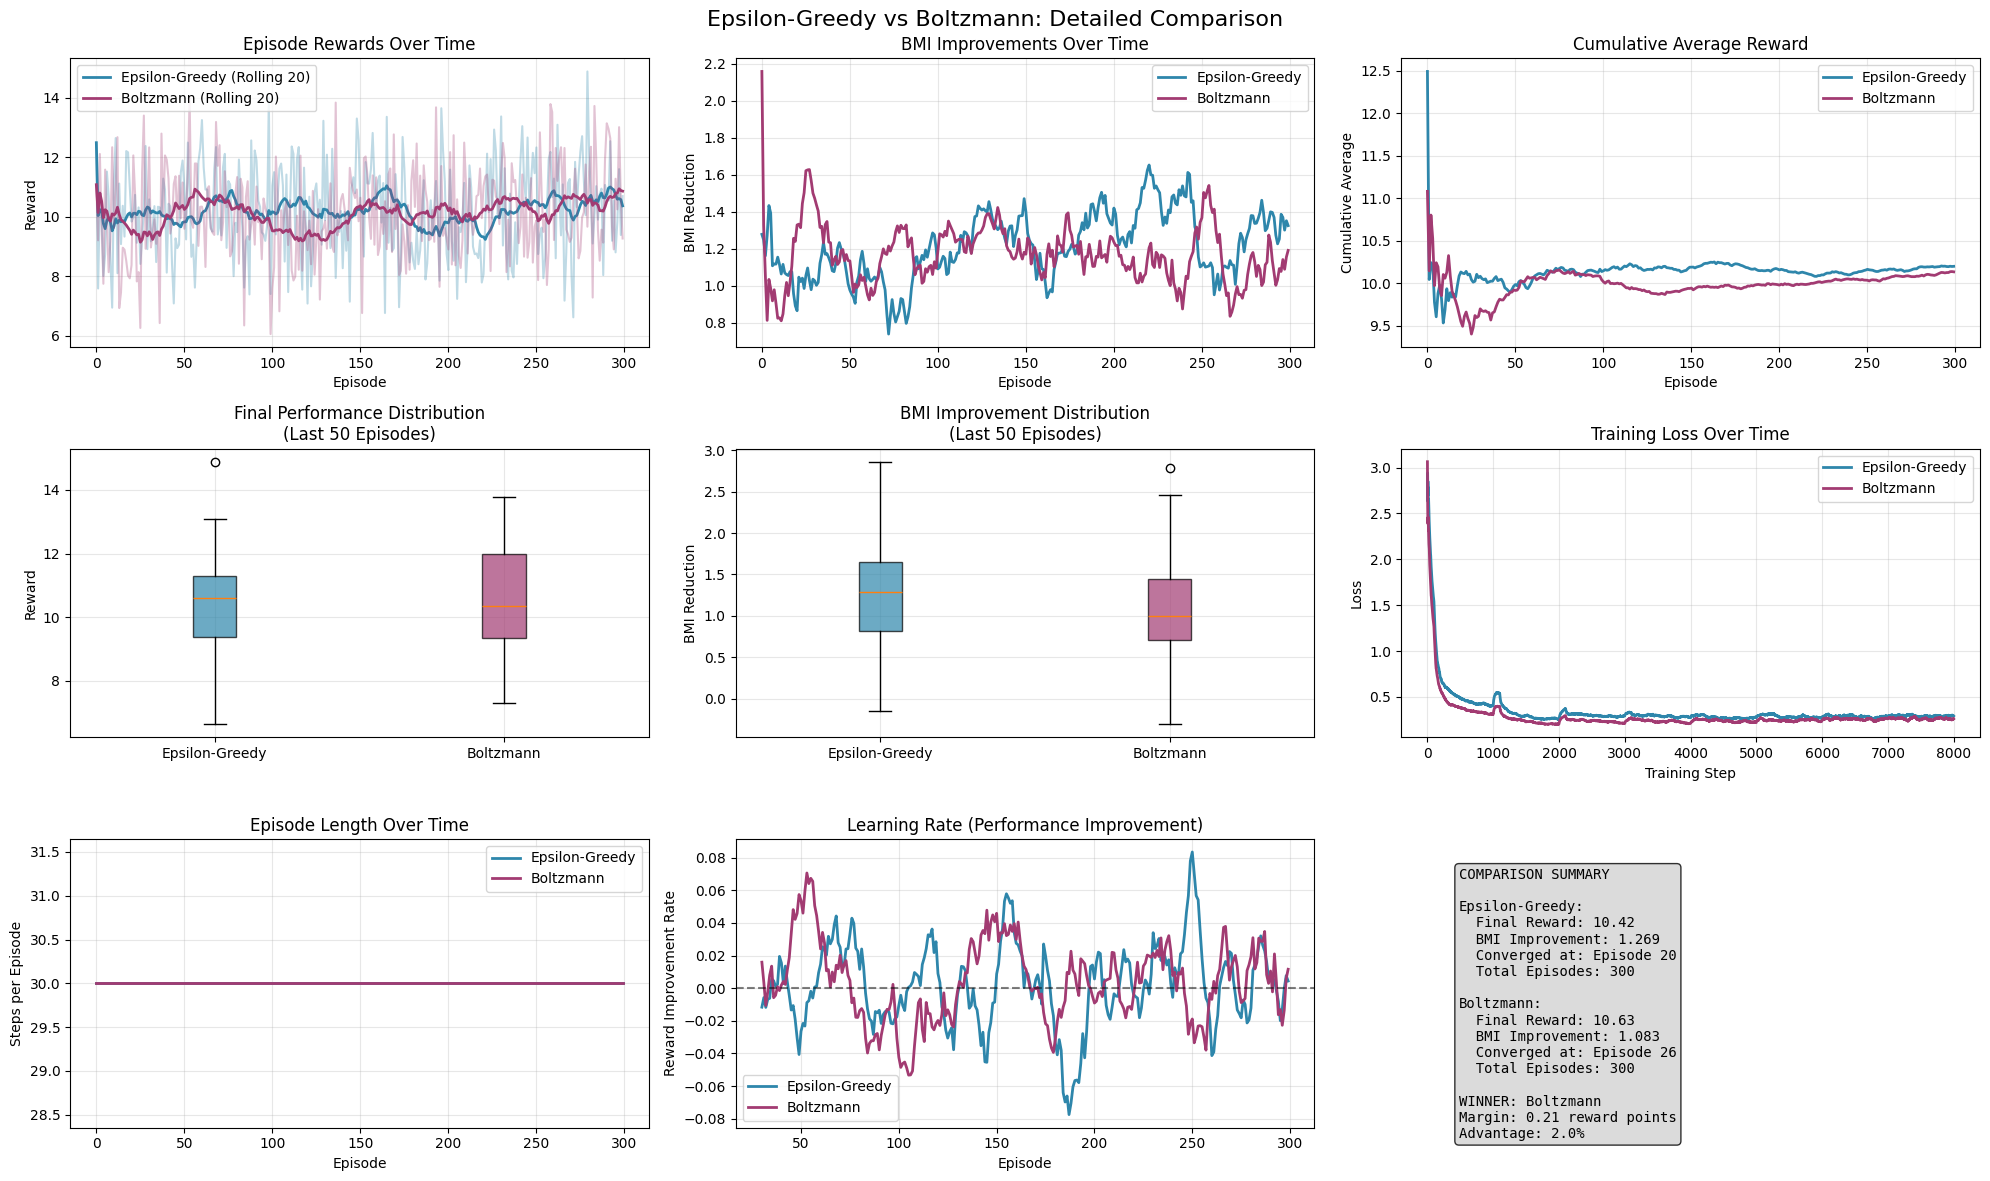


[✓] BEST STRATEGY SELECTED: Boltzmann

[✓] Best Hyperparameters Used (from previous search):
   lr: 0.0001
   gamma: 0.95
   eps_end: 0.01
   eps_decay_steps: 10000
   batch_size: 64
   target_update_every: 1000
DQN Agent initialized on cpu
Network architecture: 16 -> 256 -> 256 -> 128 -> 8

[✓] Retraining best agent from scratch using Boltzmann + previous best params...
Starting DQN training...
Warmup steps: 1000, Episodes: 300
Environment episode length: 30, Max steps override: 100
Episode  10 | Reward:  11.41 | Avg100:  10.33 | BMI Δ: +0.69 | Class Δ: +0 | ε: 0.970 | Loss: 0.0000 | Steps: 30
Episode  20 | Reward:  11.23 | Avg100:  10.46 | BMI Δ: +0.93 | Class Δ: +0 | ε: 0.941 | Loss: 0.0000 | Steps: 30
Episode  30 | Reward:   6.53 | Avg100:  10.14 | BMI Δ: +2.92 | Class Δ: +1 | ε: 0.911 | Loss: 0.0000 | Steps: 30
Episode  40 | Reward:  10.30 | Avg100:  10.06 | BMI Δ: +0.49 | Class Δ: +0 | ε: 0.881 | Loss: 0.4976 | Steps: 30
Episode  50 | Reward:   9.67 | Avg100:  10.09 | BMI Δ: +1.

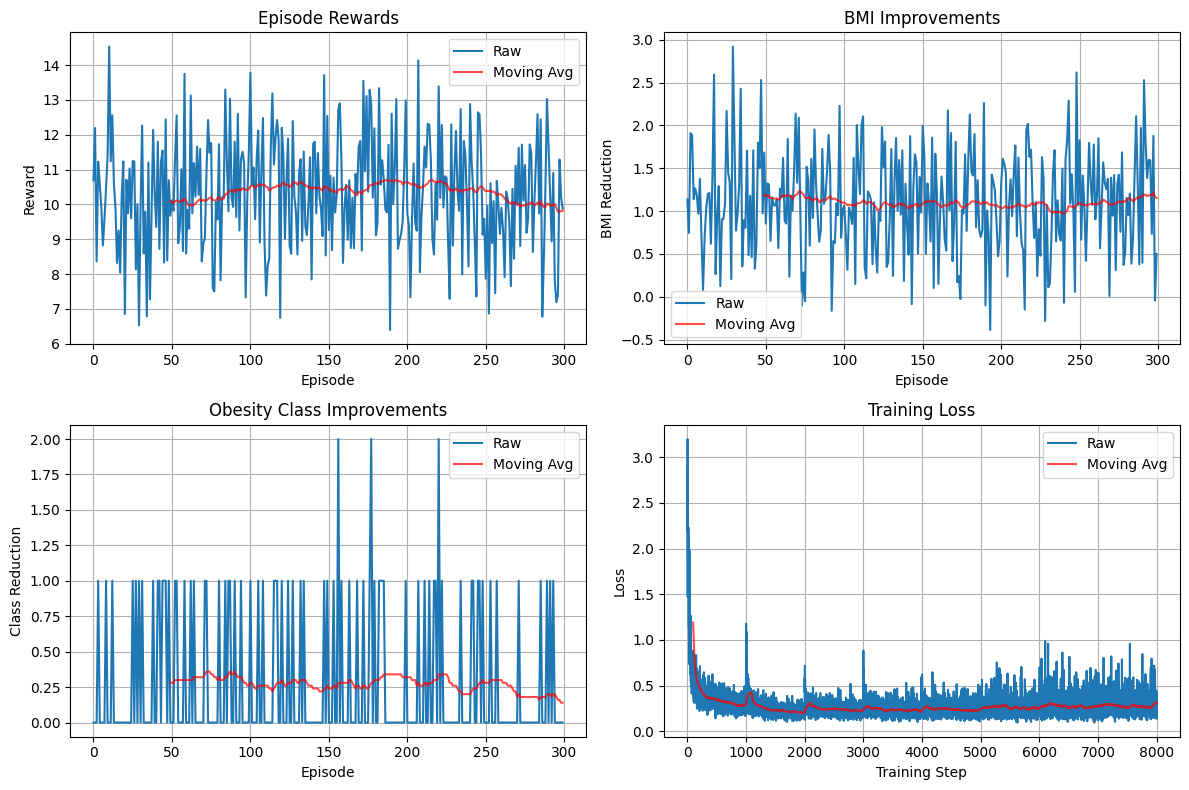

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Optional
import seaborn as sns

class StrategyComparison:
    """Compare Epsilon-Greedy vs Boltzmann exploration strategies"""

    def __init__(self, env, base_agent_class):
        self.env = env
        self.base_agent_class = base_agent_class
        self.results = {}

    def get_best_strategy_name(self) -> str:
      """Return strategy name with highest average final reward"""
      if not self.results:
          return None
      return max(self.results.items(), key=lambda x: np.mean(x[1]['metrics']['episode_rewards'][-50:]))[0]

    def create_epsilon_greedy_agent(self, **agent_kwargs):
        """Create standard epsilon-greedy agent"""
        return self.base_agent_class(**agent_kwargs)

    def create_boltzmann_agent(self, temp_start=5.0, temp_end=0.1, decay_steps=15000, **agent_kwargs):
      """Create agent with Boltzmann exploration"""
      agent = self.base_agent_class(**agent_kwargs)

      # Override the act method for Boltzmann exploration
      original_act = agent.act

      def boltzmann_act(state, training=True):
          if not training:
              return original_act(state, training=False)

          # Get Q-values
          state_tensor = torch.FloatTensor(state).to(agent.device)
          agent.q_network.eval()
          with torch.no_grad():
              q_values = agent.q_network(state_tensor)
          if training:
              agent.q_network.train()

          # Boltzmann temperature decay
          if agent.step_count < decay_steps:
              progress = agent.step_count / decay_steps
              temp = temp_start * (temp_end / temp_start) ** progress
          else:
              temp = temp_end

          # --- Stable softmax ---
          q_vals = q_values.cpu().numpy().flatten()
          z = q_vals / temp
          z -= np.max(z)

          exp_values = np.exp(z)
          sum_exp = np.sum(exp_values)

          if sum_exp == 0 or np.isnan(sum_exp):
              probs = np.ones_like(exp_values) / len(exp_values)
          else:
              probs = exp_values / sum_exp

          # Sample action
          action = np.random.choice(len(probs), p=probs)
          return action

      agent.act = boltzmann_act
      agent.temp_start = temp_start
      agent.temp_end = temp_end
      agent.decay_steps = decay_steps

      return agent


    def train_and_compare(self,
                         agent_kwargs: Dict,
                         train_kwargs: Dict,
                         boltzmann_temp_start: float = 5.0,
                         boltzmann_temp_end: float = 0.1,
                         boltzmann_decay_steps: int = 15000):
        """Train both agents and compare results"""

        results = {}

        # Train Epsilon-Greedy Agent
        print("=== Training Epsilon-Greedy Agent ===")
        eps_agent = self.create_epsilon_greedy_agent(**agent_kwargs)
        eps_metrics = train_dqn_agent(env=self.env, agent=eps_agent, **train_kwargs)

        results['Epsilon-Greedy'] = {
            'agent': eps_agent,
            'metrics': eps_metrics,
            'strategy_type': 'epsilon_greedy'
        }

        # Reset environment seed for fair comparison
        if hasattr(self.env, 'seed'):
            self.env.seed(42)

        # Train Boltzmann Agent
        print("\n=== Training Boltzmann Agent ===")
        boltz_agent = self.create_boltzmann_agent(
            temp_start=boltzmann_temp_start,
            temp_end=boltzmann_temp_end,
            decay_steps=boltzmann_decay_steps,
            **agent_kwargs
        )
        boltz_metrics = train_dqn_agent(env=self.env, agent=boltz_agent, **train_kwargs)

        results['Boltzmann'] = {
            'agent': boltz_agent,
            'metrics': boltz_metrics,
            'strategy_type': 'boltzmann'
        }

        self.results = results
        return results

    def analyze_results(self) -> pd.DataFrame:
        """Analyze and compare the results"""

        if not self.results:
            print("No results to analyze. Run train_and_compare first.")
            return pd.DataFrame()

        analysis_data = []

        for strategy_name, result in self.results.items():
            metrics = result['metrics']

            # Calculate key statistics
            episode_rewards = metrics['episode_rewards']
            bmi_improvements = metrics['bmi_improvements']
            episode_lengths = metrics['episode_lengths']

            # Final performance (last 50 episodes)
            final_rewards = episode_rewards[-50:]
            final_bmi = bmi_improvements[-50:]

            # Learning curve analysis
            early_rewards = episode_rewards[:50]  # First 50 episodes
            mid_rewards = episode_rewards[200:250] if len(episode_rewards) > 250 else episode_rewards[len(episode_rewards)//2:]

            # Convergence analysis
            convergence_episode = self._find_convergence_point(episode_rewards)

            # Stability analysis (variance in final performance)
            stability_score = 100 - np.std(final_rewards)  # Lower variance = higher stability

            analysis_data.append({
                'Strategy': strategy_name,
                'Final Avg Reward': f"{np.mean(final_rewards):.2f}",
                'Final Std Reward': f"{np.std(final_rewards):.2f}",
                'Final BMI Improvement': f"{np.mean(final_bmi):.3f}",
                'BMI Std': f"{np.std(final_bmi):.3f}",
                'Early Performance': f"{np.mean(early_rewards):.2f}",
                'Mid Performance': f"{np.mean(mid_rewards):.2f}",
                'Convergence Episode': convergence_episode,
                'Stability Score': f"{stability_score:.1f}",
                'Total Episodes': len(episode_rewards),
                'Avg Episode Length': f"{np.mean(episode_lengths):.1f}",
                'Best Single Episode': f"{np.max(episode_rewards):.2f}",
                'Learning Rate': f"{(np.mean(final_rewards) - np.mean(early_rewards)):.2f}"
            })

        return pd.DataFrame(analysis_data)

    def _find_convergence_point(self, rewards: List[float], window=20, threshold=0.95) -> int:
        """Find when the agent converged to final performance"""
        if len(rewards) < window * 2:
            return len(rewards)

        final_performance = np.mean(rewards[-window:])
        target = threshold * final_performance

        for i in range(window, len(rewards) - window):
            if np.mean(rewards[i:i+window]) >= target:
                return i

        return len(rewards)

    def plot_detailed_comparison(self, figsize=(20, 12)):
        """Create comprehensive comparison plots"""

        if not self.results:
            print("No results to plot. Run train_and_compare first.")
            return

        fig, axes = plt.subplots(3, 3, figsize=figsize)
        fig.suptitle('Epsilon-Greedy vs Boltzmann: Detailed Comparison', fontsize=16)

        colors = ['#2E86AB', '#A23B72']  # Blue for Epsilon, Purple for Boltzmann

        # 1. Episode Rewards with Rolling Average
        ax = axes[0, 0]
        for i, (name, result) in enumerate(self.results.items()):
            rewards = result['metrics']['episode_rewards']
            episodes = range(len(rewards))

            # Plot raw rewards (light)
            ax.plot(episodes, rewards, alpha=0.3, color=colors[i])

            # Plot rolling average (bold)
            window = 20
            rolling_avg = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
            ax.plot(episodes, rolling_avg, label=f'{name} (Rolling {window})',
                   color=colors[i], linewidth=2)

        ax.set_title('Episode Rewards Over Time')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Reward')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # 2. BMI Improvements
        ax = axes[0, 1]
        for i, (name, result) in enumerate(self.results.items()):
            bmi_imps = result['metrics']['bmi_improvements']
            episodes = range(len(bmi_imps))

            # Rolling average for BMI
            window = 15
            rolling_bmi = pd.Series(bmi_imps).rolling(window=window, min_periods=1).mean()
            ax.plot(episodes, rolling_bmi, label=f'{name}', color=colors[i], linewidth=2)

        ax.set_title('BMI Improvements Over Time')
        ax.set_xlabel('Episode')
        ax.set_ylabel('BMI Reduction')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # 3. Learning Progress (Cumulative)
        ax = axes[0, 2]
        for i, (name, result) in enumerate(self.results.items()):
            rewards = result['metrics']['episode_rewards']
            # Cumulative average
            cumulative_avg = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
            ax.plot(cumulative_avg, label=f'{name}', color=colors[i], linewidth=2)

        ax.set_title('Cumulative Average Reward')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Cumulative Average')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # 4. Final Performance Distribution
        ax = axes[1, 0]
        final_rewards = {}
        for name, result in self.results.items():
            final_rewards[name] = result['metrics']['episode_rewards'][-50:]

        positions = [1, 2]
        bp = ax.boxplot([final_rewards[name] for name in self.results.keys()],
                       positions=positions, patch_artist=True)

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticklabels(self.results.keys())
        ax.set_title('Final Performance Distribution\n(Last 50 Episodes)')
        ax.set_ylabel('Reward')
        ax.grid(True, alpha=0.3)

        # 5. BMI Improvement Distribution
        ax = axes[1, 1]
        final_bmi = {}
        for name, result in self.results.items():
            final_bmi[name] = result['metrics']['bmi_improvements'][-50:]

        bp = ax.boxplot([final_bmi[name] for name in self.results.keys()],
                       positions=positions, patch_artist=True)

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticklabels(self.results.keys())
        ax.set_title('BMI Improvement Distribution\n(Last 50 Episodes)')
        ax.set_ylabel('BMI Reduction')
        ax.grid(True, alpha=0.3)

        # 6. Training Loss Comparison
        ax = axes[1, 2]
        for i, (name, result) in enumerate(self.results.items()):
            losses = result['metrics']['losses']
            if losses:
                # Smooth losses
                window = 100
                smooth_losses = pd.Series(losses).rolling(window=window, min_periods=1).mean()
                ax.plot(smooth_losses, label=f'{name}', color=colors[i], linewidth=2)

        ax.set_title('Training Loss Over Time')
        ax.set_xlabel('Training Step')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # 7. Episode Length Comparison
        ax = axes[2, 0]
        for i, (name, result) in enumerate(self.results.items()):
            lengths = result['metrics']['episode_lengths']
            window = 20
            rolling_lengths = pd.Series(lengths).rolling(window=window, min_periods=1).mean()
            ax.plot(rolling_lengths, label=f'{name}', color=colors[i], linewidth=2)

        ax.set_title('Episode Length Over Time')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Steps per Episode')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # 8. Performance Improvement Rate
        ax = axes[2, 1]
        for i, (name, result) in enumerate(self.results.items()):
            rewards = result['metrics']['episode_rewards']
            # Calculate improvement rate (derivative of rolling average)
            window = 30
            rolling_avg = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
            improvement_rate = rolling_avg.diff().rolling(10).mean()  # Smooth the derivative

            ax.plot(improvement_rate[window:], label=f'{name}', color=colors[i], linewidth=2)

        ax.set_title('Learning Rate (Performance Improvement)')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Reward Improvement Rate')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

        # 9. Summary Statistics
        ax = axes[2, 2]
        ax.axis('off')  # Turn off axis for text

        # Create summary text
        summary_text = "COMPARISON SUMMARY\n\n"

        for name, result in self.results.items():
            metrics = result['metrics']
            final_reward = np.mean(metrics['episode_rewards'][-50:])
            final_bmi = np.mean(metrics['bmi_improvements'][-50:])
            convergence = self._find_convergence_point(metrics['episode_rewards'])

            summary_text += f"{name}:\n"
            summary_text += f"  Final Reward: {final_reward:.2f}\n"
            summary_text += f"  BMI Improvement: {final_bmi:.3f}\n"
            summary_text += f"  Converged at: Episode {convergence}\n"
            summary_text += f"  Total Episodes: {len(metrics['episode_rewards'])}\n\n"

        # Determine winner
        eps_reward = np.mean(self.results['Epsilon-Greedy']['metrics']['episode_rewards'][-50:])
        boltz_reward = np.mean(self.results['Boltzmann']['metrics']['episode_rewards'][-50:])

        if eps_reward > boltz_reward:
            winner = "Epsilon-Greedy"
            margin = eps_reward - boltz_reward
        else:
            winner = "Boltzmann"
            margin = boltz_reward - eps_reward

        summary_text += f"WINNER: {winner}\n"
        summary_text += f"Margin: {margin:.2f} reward points\n"
        summary_text += f"Advantage: {(margin/max(eps_reward, boltz_reward)*100):.1f}%"

        ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

        plt.tight_layout()
        plt.show()

    def get_recommendation(self) -> str:
        """Get final recommendation based on results"""

        if not self.results:
            return "No results available. Run train_and_compare first."

        eps_metrics = self.results['Epsilon-Greedy']['metrics']
        boltz_metrics = self.results['Boltzmann']['metrics']

        # Compare final performance
        eps_final = np.mean(eps_metrics['episode_rewards'][-50:])
        boltz_final = np.mean(boltz_metrics['episode_rewards'][-50:])

        # Compare BMI improvements
        eps_bmi = np.mean(eps_metrics['bmi_improvements'][-50:])
        boltz_bmi = np.mean(boltz_metrics['bmi_improvements'][-50:])

        # Compare convergence speed
        eps_conv = self._find_convergence_point(eps_metrics['episode_rewards'])
        boltz_conv = self._find_convergence_point(boltz_metrics['episode_rewards'])

        # Compare stability
        eps_stability = np.std(eps_metrics['episode_rewards'][-50:])
        boltz_stability = np.std(boltz_metrics['episode_rewards'][-50:])

        recommendation = f"""
RECOMMENDATION ANALYSIS:
========================

PERFORMANCE:
- Epsilon-Greedy: {eps_final:.2f} ± {eps_stability:.2f}
- Boltzmann: {boltz_final:.2f} ± {boltz_stability:.2f}
Winner: {'Epsilon-Greedy' if eps_final > boltz_final else 'Boltzmann'}

HEALTH OUTCOMES (BMI):
- Epsilon-Greedy: {eps_bmi:.3f} BMI reduction
- Boltzmann: {boltz_bmi:.3f} BMI reduction
Winner: {'Epsilon-Greedy' if eps_bmi > boltz_bmi else 'Boltzmann'}

LEARNING SPEED:
- Epsilon-Greedy: Converged at episode {eps_conv}
- Boltzmann: Converged at episode {boltz_conv}
Winner: {'Epsilon-Greedy' if eps_conv < boltz_conv else 'Boltzmann'}

STABILITY:
- Epsilon-Greedy: {eps_stability:.2f} std deviation
- Boltzmann: {boltz_stability:.2f} std deviation
Winner: {'Epsilon-Greedy' if eps_stability < boltz_stability else 'Boltzmann'}

FINAL RECOMMENDATION:
"""

        # Scoring system
        eps_score = 0
        boltz_score = 0

        if eps_final > boltz_final: eps_score += 2
        else: boltz_score += 2

        if eps_bmi > boltz_bmi: eps_score += 2
        else: boltz_score += 2

        if eps_conv < boltz_conv: eps_score += 1
        else: boltz_score += 1

        if eps_stability < boltz_stability: eps_score += 1
        else: boltz_score += 1

        if eps_score > boltz_score:
            recommendation += f"Use EPSILON-GREEDY (Score: {eps_score} vs {boltz_score})\n"
            recommendation += "Epsilon-greedy wins on most important metrics for healthcare RL."
        elif boltz_score > eps_score:
            recommendation += f"Use BOLTZMANN (Score: {boltz_score} vs {eps_score})\n"
            recommendation += "Boltzmann exploration shows superior performance for your health coaching task."
        else:
            recommendation += f"TIE (Score: {eps_score} vs {boltz_score})\n"
            recommendation += "Both strategies perform similarly. Stick with Epsilon-Greedy for simplicity."

        return recommendation

# Usage function
def compare_exploration_strategies(env, data=None, best_params_from_prev: Optional[dict] = None,
                                   episodes_per_strategy: int = 300, eval_episode_len: int = 30):
    """
    Full pipeline to compare exploration strategies (Epsilon-Greedy vs Boltzmann)
    using the BEST params discovered previously.

    """

    if best_params_from_prev is None:
        raise ValueError("best_params_from_prev is required. "
                         "Example: best_params_from_prev = run_all(data)[\"best_config\"]")

    # 1) Lock the agent hyperparameters to the previous best config
    BEST_DQN_PARAMS = {
        "state_size": 16,
        "action_size": 8,
        "lr": best_params_from_prev["lr"],
        "gamma": best_params_from_prev["gamma"],
        "eps_start": 1.0,
        "eps_end": best_params_from_prev["eps_end"],
        "eps_decay_steps": best_params_from_prev["eps_decay_steps"],
        "buffer_capacity": 1_000_000,
        "batch_size": best_params_from_prev["batch_size"],
        "target_update_every": best_params_from_prev["target_update_every"]
    }

    train_kwargs = {
        "episodes": episodes_per_strategy,
        "warmup_steps": 1000,
        "max_steps_per_ep": 100,
        "log_every": 10,
        "save_every": None,
        "save_path": None,
        "do_save": False
    }

    # 2) Run strategy comparison with fixed best params
    comparator = StrategyComparison(env, DQNAgent)
    results = comparator.train_and_compare(
        agent_kwargs=BEST_DQN_PARAMS,
        train_kwargs=train_kwargs,
        boltzmann_temp_start=5.0,
        boltzmann_temp_end=0.1,
        boltzmann_decay_steps=BEST_DQN_PARAMS["eps_decay_steps"]  # match decay horizon
    )

    analysis_df = comparator.analyze_results()
    comparator.plot_detailed_comparison()

    best_strategy = comparator.get_best_strategy_name()
    best_agent_ref = results[best_strategy]['agent']
    best_metrics = results[best_strategy]['metrics']

    print(f"\n[✓] BEST STRATEGY SELECTED: {best_strategy}")

    print("\n[✓] Best Hyperparameters Used (from previous search):")
    for k in ["lr","gamma","eps_end","eps_decay_steps","batch_size","target_update_every"]:
        print(f"   {k}: {BEST_DQN_PARAMS[k]}")

    # 3) Retrain the winner from scratch on a fresh env, still using the same best params
    final_env = create_health_coach_env("DQN", episode_len=eval_episode_len, difficulty="medium", dataset=data)
    comparator_final = StrategyComparison(final_env, DQNAgent)

    if best_strategy == 'Epsilon-Greedy':
        best_agent = comparator_final.create_epsilon_greedy_agent(**BEST_DQN_PARAMS)
    else:
        # Keep Boltzmann exploration but same core hyperparams
        best_agent = comparator_final.create_boltzmann_agent(
            temp_start=5.0,
            temp_end=0.1,
            decay_steps=BEST_DQN_PARAMS["eps_decay_steps"],
            **BEST_DQN_PARAMS
        )

    print(f"\n[✓] Retraining best agent from scratch using {best_strategy} + previous best params...")

    final_metrics = train_dqn_agent(
        env=final_env,
        agent=best_agent,
        episodes=episodes_per_strategy,
        warmup_steps=1000,
        max_steps_per_ep=100,
        log_every=10,
        save_every=None,
        save_path=None,
        do_save=False
    )

    plot_training_results(final_metrics)

    return results, analysis_df, comparator, best_strategy, BEST_DQN_PARAMS, final_metrics, best_agent


# Example usage:
if __name__ == "__main__":
    # 1) Get best config from your previous search:
    # out = run_all(data, episode_len=30, difficulty="medium", episodes_per_config=300, eval_episodes=5)
    # best_params = out["best_config"]

    # If you already have best_params saved/loaded, provide it here:
    best_params = out["best_config"]  # or replace with: out["best_config"]

    # 2) Create a comparison env
    env = create_health_coach_env("DQN", episode_len=30, difficulty="medium", dataset=data)

    # 3) Run the comparison *using the best params*
    results, analysis_df, comparator, best_strategy, best_params_used, final_metrics, trained_agent = \
        compare_exploration_strategies(env, data, best_params_from_prev=best_params,
                                       episodes_per_strategy=300, eval_episode_len=30)


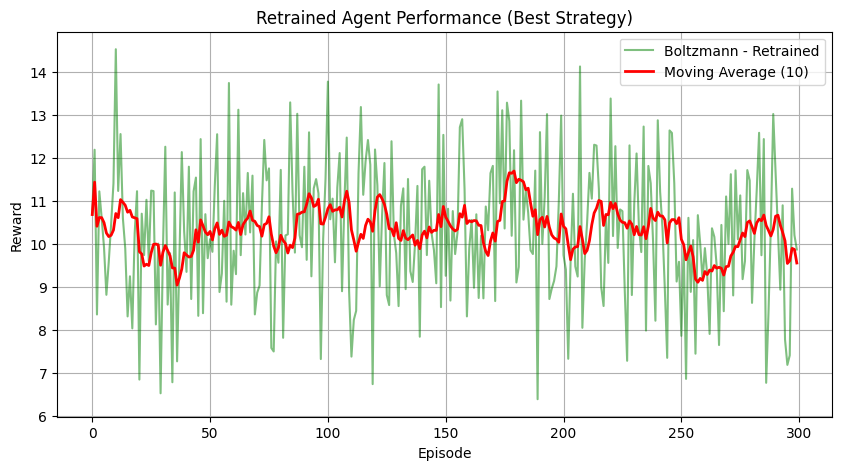

In [25]:
# Extract rewards from final training result
rewards = final_metrics['episode_rewards']

# Plot moving average
rolling_avg = pd.Series(rewards).rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(rewards, label=f"{best_strategy} - Retrained", color='green', alpha=0.5)
plt.plot(rolling_avg, label="Moving Average (10)", color='red', linewidth=2)
plt.title("Retrained Agent Performance (Best Strategy)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.show()


Evaluation

In [26]:
class StrategyEvaluator:
    """Post-training evaluation of exploration strategy results"""

    def __init__(self, strategy_results: Dict[str, Dict]):
        self.results = strategy_results

    def plot_evaluation_summary(self, figsize=(18, 12)):
        fig, axes = plt.subplots(4, 3, figsize=figsize)
        fig.suptitle("Strategy Evaluation Summary", fontsize=16, fontweight='bold')
        colors = ['#2E86AB', '#A23B72']  # Epsilon-Greedy, Boltzmann

        for i, (strategy_name, result) in enumerate(self.results.items()):
            metrics = result['metrics']
            rewards = metrics['episode_rewards']
            bmi = metrics['bmi_improvements']
            actions = metrics.get('actions', [])
            lengths = metrics['episode_lengths']

            color = colors[i]
            episodes = np.arange(len(rewards))

            # 1. Reward Distribution
            ax = axes[0, 0]
            sns.histplot(rewards[-50:], kde=True, bins=20, color=color, label=strategy_name, ax=ax)
            ax.set_title("Reward Distribution")
            ax.set_xlabel("Reward")
            ax.legend()

            # 2. Rewards over Episodes
            ax = axes[0, 1]
            ax.plot(episodes, rewards, label=strategy_name, color=color, alpha=0.5)
            ax.plot(episodes, pd.Series(rewards).rolling(20).mean(), linewidth=2, color=color)
            ax.set_title("Rewards Over Episodes")
            ax.set_xlabel("Episode")
            ax.set_ylabel("Reward")
            ax.legend()

            # 3. Success Rate
            ax = axes[0, 2]
            success = [1 if r > 10 else 0 for r in rewards]
            rolling_success = pd.Series(success).rolling(20).mean()
            ax.plot(rolling_success, label=strategy_name, color=color)
            ax.set_title("Success Rate (Reward > 10)")
            ax.set_ylabel("Success Rate")
            ax.set_xlabel("Episode")
            ax.legend()

            # 4. BMI Improvements
            ax = axes[1, 0]
            ax.plot(bmi, label=strategy_name, color=color)
            ax.set_title("BMI Improvements")
            ax.set_xlabel("Episode")
            ax.set_ylabel("Δ BMI")
            ax.legend()

            # 5. Action Distribution
            ax = axes[1, 1]
            if actions:
                sns.histplot(actions, bins=8, color=color, ax=ax)
                ax.set_title("Action Distribution")
                ax.set_xlabel("Action ID")

            # 6. BMI Success Rate
            ax = axes[1, 2]
            bmi_success = [1 if b < 0 else 0 for b in bmi]
            rolling_bmi = pd.Series(bmi_success).rolling(20).mean()
            ax.plot(rolling_bmi, label=strategy_name, color=color)
            ax.set_title("BMI Compliance Rate")
            ax.set_ylabel("Compliance Rate")
            ax.legend()

            # 7. Reward vs BMI Correlation
            ax = axes[2, 0]
            ax.scatter(rewards, bmi, label=strategy_name, alpha=0.6, color=color)
            ax.set_xlabel("Reward")
            ax.set_ylabel("BMI Change")
            ax.set_title("Reward vs BMI Correlation")
            ax.legend()

            # 8. Reward Variability (rolling std)
            ax = axes[2, 1]
            rolling_std = pd.Series(rewards).rolling(30).std()
            ax.plot(rolling_std, color=color, label=strategy_name)
            ax.set_title("Reward Variability")
            ax.set_ylabel("Std Dev (Rolling)")
            ax.legend()

            # 9. Health Outcome Stats
            ax = axes[2, 2]
            ax.axis('off')
            reward_mean = np.mean(rewards[-50:])
            reward_std = np.std(rewards[-50:])
            bmi_mean = np.mean(bmi[-50:])
            stat_summary = f"{strategy_name}\nReward: {reward_mean:.2f} ± {reward_std:.2f}\nBMI Δ: {bmi_mean:.3f}"
            ax.text(0.1, 0.7 - i*0.2, stat_summary, fontsize=10, fontfamily='monospace')

            # 10. Success/Failure Pie
            if i == 0:
                ax = axes[3, 0]  # Epsilon-Greedy
            else:
                ax = axes[3, 1]  # Boltzmann

            num_success = sum(np.array(rewards) > 10)
            num_failure = len(rewards) - num_success
            ax.pie([num_success, num_failure], labels=["Success", "Failure"],
                  colors=[color, 'lightgray'], autopct='%1.1f%%')
            ax.set_title(f"{strategy_name} Success Ratio")

        # 12. Leave last plot empty or use for legend
        axes[3, 2].axis('off')

        plt.tight_layout()
        plt.show()

    def generate_statistics_summary(self) -> pd.DataFrame:
        """Generate a table of performance statistics"""
        records = []
        for name, result in self.results.items():
            m = result['metrics']
            rewards = np.array(m['episode_rewards'])
            bmi = np.array(m['bmi_improvements'])
            records.append({
                'Strategy': name,
                'Avg Reward': np.mean(rewards),
                'Max Reward': np.max(rewards),
                'Min Reward': np.min(rewards),
                'Final 50 Avg Reward': np.mean(rewards[-50:]),
                'Std Dev Reward': np.std(rewards[-50:]),
                'Avg BMI Δ': np.mean(bmi),
                'Final 50 BMI Δ': np.mean(bmi[-50:]),
                'Total Episodes': len(rewards),
                'Success %': np.mean(rewards > 10) * 100
            })
        return pd.DataFrame(records)


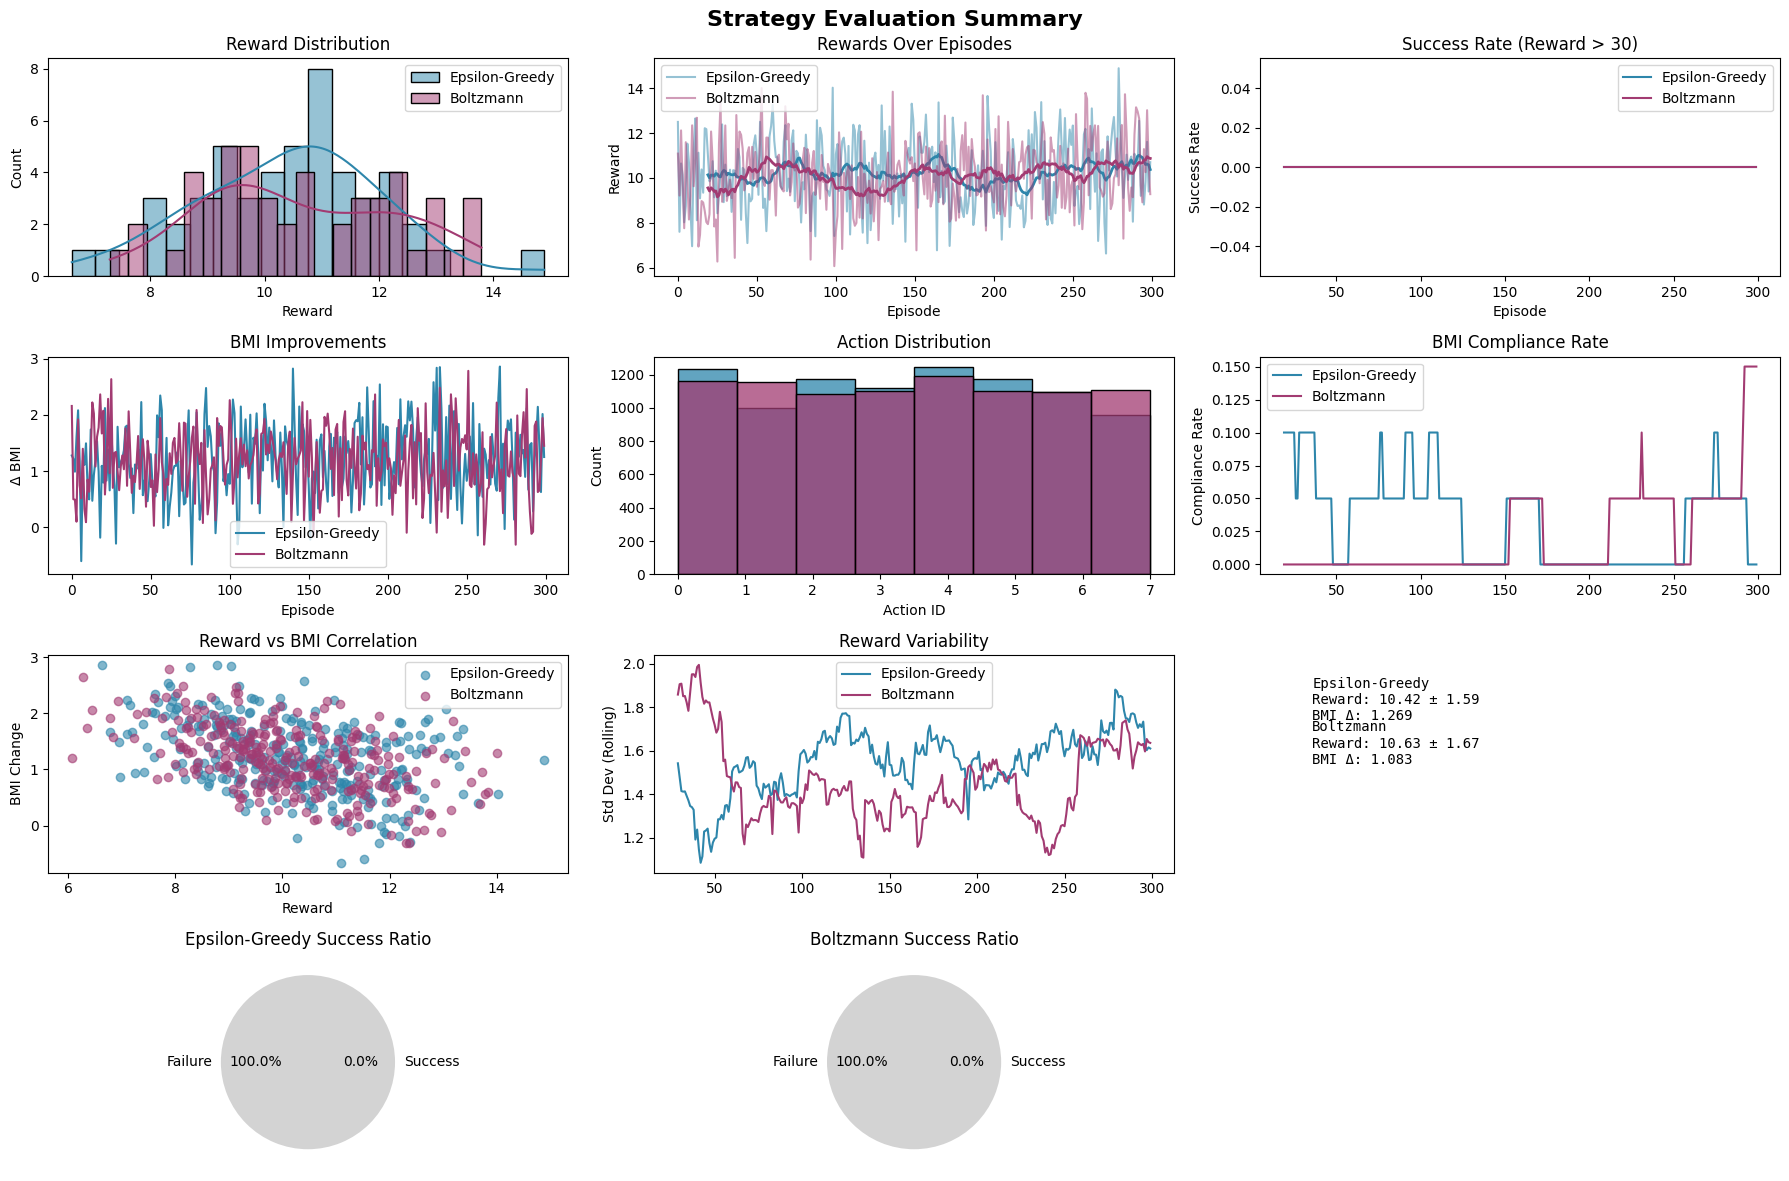

         Strategy  Avg Reward  Max Reward  Min Reward  Final 50 Avg Reward  \
0  Epsilon-Greedy   10.200520   14.888448    6.627061            10.420969   
1       Boltzmann   10.135905   14.004210    6.064900            10.628365   

   Std Dev Reward  Avg BMI Δ  Final 50 BMI Δ  Total Episodes  Success %  
0        1.587142   1.217816        1.268792             300        0.0  
1        1.672558   1.170616        1.083457             300        0.0  


In [27]:
evaluator = StrategyEvaluator(results)
evaluator.plot_evaluation_summary()

summary_df = evaluator.generate_statistics_summary()
print(summary_df)


Generalization

In [28]:
generalization_env = create_health_coach_env(
    algorithm="DQN",
    difficulty="hard",
    episode_len=30,
    enable_events=True,
    event_prob=0.1
)


In [29]:
def safe_reset(env, **kwargs):
    out = env.reset(**kwargs)
    if isinstance(out, tuple) and len(out) == 2:
        return out
    return out, {}

def safe_step(env, action):
    out = env.step(action)
    if isinstance(out, tuple) and len(out) == 5:
        obs, reward, terminated, truncated, info = out
        done = terminated or truncated
        return obs, reward, done, info
    return out

def evaluate_on_generalization_env(agent, env, episodes=100, max_steps=100):
    rewards, bmi_deltas, success_flags = [], [], []
    episode_lengths = []
    for ep in range(episodes):
        state, _ = safe_reset(env)
        done = False
        total_reward = 0
        step = 0
        while not done and step < max_steps:
            action = agent.act(state, training=False)
            next_state, reward, done, info = safe_step(env, action)
            total_reward += reward
            state = next_state
            step += 1
        rewards.append(total_reward)
        bmi_deltas.append(info.get("bmi_change", 0))
        success_flags.append(total_reward > 10)
        episode_lengths.append(step)
    return {
        "rewards": rewards,
        "bmi_improvements": bmi_deltas,
        "success_rate": np.mean(success_flags),
        "episode_lengths": episode_lengths
    }


In [30]:
best_eps_agent = results['Epsilon-Greedy']['agent']
best_boltz_agent = results['Boltzmann']['agent']

eps_generalization_metrics = evaluate_on_generalization_env(best_eps_agent, generalization_env)
boltz_generalization_metrics = evaluate_on_generalization_env(best_boltz_agent, generalization_env)


In [31]:
def plot_generalization_comparison(metrics_eps, metrics_boltz):
    plt.figure(figsize=(14, 5))

    # Reward distribution
    plt.subplot(1, 2, 1)
    sns.histplot(metrics_eps["rewards"], color='#2E86AB', label='Epsilon-Greedy', kde=True)
    sns.histplot(metrics_boltz["rewards"], color='#A23B72', label='Boltzmann', kde=True)
    plt.title("Generalization: Reward Distribution")
    plt.xlabel("Total Reward")
    plt.legend()

    # BMI Improvement
    plt.subplot(1, 2, 2)
    sns.boxplot(data=[metrics_eps["bmi_improvements"], metrics_boltz["bmi_improvements"]],
                palette=['#2E86AB', '#A23B72'])
    plt.xticks([0, 1], ['Epsilon-Greedy', 'Boltzmann'])
    plt.ylabel("BMI Improvement")
    plt.title("Generalization: BMI Reduction")

    plt.tight_layout()
    plt.show()

    # Print Summary
    print("=== GENERALIZATION PERFORMANCE ===")
    print(f"Epsilon-Greedy: Avg Reward = {np.mean(metrics_eps['rewards']):.2f}, Success Rate = {metrics_eps['success_rate']*100:.1f}%")
    print(f"Boltzmann     : Avg Reward = {np.mean(metrics_boltz['rewards']):.2f}, Success Rate = {metrics_boltz['success_rate']*100:.1f}%")

plot_generalization_comparison(eps_generalization_metrics, boltz_generalization_metrics)


In [32]:
df_gen = pd.DataFrame([
    {
        "Strategy": "Epsilon-Greedy",
        "Avg Reward": np.mean(eps_generalization_metrics['rewards']),
        "Success Rate": eps_generalization_metrics['success_rate'],
        "BMI Δ": np.mean(eps_generalization_metrics['bmi_improvements']),
        "Episode Length": np.mean(eps_generalization_metrics['episode_lengths']),
    },
    {
        "Strategy": "Boltzmann",
        "Avg Reward": np.mean(boltz_generalization_metrics['rewards']),
        "Success Rate": boltz_generalization_metrics['success_rate'],
        "BMI Δ": np.mean(boltz_generalization_metrics['bmi_improvements']),
        "Episode Length": np.mean(boltz_generalization_metrics['episode_lengths']),
    }

])

df_gen.style.format({
    "Avg Reward": "{:.2f}",
    "Success Rate": "{:.1%}",
    "BMI Δ": "{:.3f}",
    "Episode Length": "{:.1f}"
})



,Strategy,Avg Reward,Success Rate,BMI Δ,Episode Length
0,Epsilon-Greedy,10.30,0.0%,-0.017,30.0
1,Boltzmann,9.96,0.0%,-0.019,30.0


In [33]:
DQNmodel = trained_agent

PPO

In [34]:
import os
import csv
import math
import copy
import time
import random
from dataclasses import dataclass, asdict
from pprint import pformat
from typing import Tuple, Dict, Any, List
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

try:
    import gymnasium as gym
    GYMNASIUM = True
except Exception:
    import gym
    GYMNASIUM = False

import torch
import torch.nn as nn
import torch.optim as optim

In [35]:
def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

PPO Configurations

In [36]:
@dataclass
class PPOConfig:
    # Training horizon
    total_env_steps: int = 40_000
    steps_per_rollout: int = 2048
    update_epochs: int = 10
    minibatch_size: int = 128
    # Learning
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_eps: float = 0.20
    ent_coef: float = 0.01
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    lr: float = 3e-4
    target_kl: float = 0.015
    # Network
    hidden_sizes: Tuple[int, int] = (128, 128)
    # Exploration schedule
    entropy_anneal: bool = True
    ent_coef_final: float = 0.005
    # Ablation: ε-greedy toggle
    epsilon_greedy_eval: bool = False
    # Repro/Device
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    # Logging & IO
    log_dir: str = "./ppo_logs"
    save_best: bool = True
    eval_every_steps: int = 20_000
    eval_episodes: int = 8
    # Curriculum boundaries (episodes)
    curriculum_boundaries: Tuple[int, int] = (6, 18)

PPO Network

In [37]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128, 128), last_act=None):
        super().__init__()
        layers = []
        dims = [in_dim] + list(hidden)
        for i in range(len(dims)-1):
            layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU()]
        layers += [nn.Linear(dims[-1], out_dim)]
        self.net = nn.Sequential(*layers)
        self.last_act = last_act

    def forward(self, x):
        x = self.net(x)
        if self.last_act:
            x = self.last_act(x)
        return x

class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(128, 128)):
        super().__init__()
        self.actor = MLP(obs_dim, act_dim, hidden, last_act=nn.Softmax(dim=-1))
        self.critic = MLP(obs_dim, 1, hidden, last_act=None)

    def forward(self, obs):
        probs = self.actor(obs)
        value = self.critic(obs)
        return probs, value

In [38]:
class RolloutBuffer:
    def __init__(self):
        self.clear()

    def add(self, obs, act, logp, val, rew, done):
        self.obs.append(obs)
        self.acts.append(act)
        self.logps.append(logp)
        self.vals.append(val)
        self.rews.append(rew)
        self.dones.append(done)

    def compute_advantages(self, last_value, gamma, lam):
        n = len(self.rews)
        self.advs = [0.0] * n
        gae = 0.0
        for t in reversed(range(n)):
            next_nonterminal = 1.0 - self.dones[t]
            next_value = self.vals[t+1] if t < n-1 else last_value
            delta = self.rews[t] + gamma * next_value * next_nonterminal - self.vals[t]
            gae = delta + gamma * lam * next_nonterminal * gae
            self.advs[t] = gae
        self.returns = [a + v for a, v in zip(self.advs, self.vals)]

    def get(self, device):
        obs = torch.tensor(np.array(self.obs), dtype=torch.float32, device=device)
        acts = torch.tensor(np.array(self.acts), dtype=torch.int64, device=device)
        old_logps = torch.tensor(np.array(self.logps), dtype=torch.float32, device=device)
        vals = torch.tensor(np.array(self.vals), dtype=torch.float32, device=device)
        advs = torch.tensor(np.array(self.advs), dtype=torch.float32, device=device)
        rets = torch.tensor(np.array(self.returns), dtype=torch.float32, device=device)
        # Advantage normalization
        advs = (advs - advs.mean()) / (advs.std() + 1e-8)
        return obs, acts, old_logps, vals, advs, rets

    def clear(self):
        self.obs, self.acts, self.logps, self.vals, self.rews, self.dones = [], [], [], [], [], []
        self.advs, self.returns = [], []

Reward Shaping & Curriculum Wrappers

In [39]:
class RewardShapingWrapper(gym.Wrapper):
    def __init__(self, env, lifestyle_weight=0.5, bmi_weight=0.05):
        super().__init__(env)
        self.lifestyle_weight = lifestyle_weight
        self.bmi_weight = bmi_weight

    def step(self, action):
        out = self.env.step(action)
        if GYMNASIUM:
            obs, r, terminated, truncated, info = out
            done = bool(terminated or truncated)
        else:
            obs, r, done, info = out

        x = info.get("lifestyle", None)
        if x is not None:
            signs = np.array([-1, +1, -1, +1, -1, -1, -1, +1], dtype=np.float32)
            health_score = np.mean(0.5 * (1 + signs * (2*np.clip(x, 0, 1) - 1)))
            r += self.lifestyle_weight * (health_score - 0.5)

        bmi = info.get("bmi", None)
        if bmi is not None and hasattr(self.env, "target_bmi"):
            r -= self.bmi_weight * abs(bmi - self.env.target_bmi)

        if GYMNASIUM:
            return obs, r, terminated, truncated, info
        else:
            return obs, r, done, info

class CurriculumWrapper(gym.Wrapper):
    def __init__(self, env, med_start=6, hard_start=18):
        super().__init__(env)
        self.ep = 0
        self.med_start = med_start
        self.hard_start = hard_start

    def reset(self, **kwargs):
        self.ep += 1
        if self.ep < self.med_start:
            self.env.difficulty = "easy"
        elif self.ep < self.hard_start:
            self.env.difficulty = "medium"
        else:
            self.env.difficulty = "hard"
        return self.env.reset(**kwargs)

PPO Implementation and Training Loop

In [40]:
def _rule(ch='-', n=70):
    return ch * n

def _banner(title: str):
    print("\n" + _rule('='))
    print(title)
    print(_rule('='))

def _kv_line(k: str, v: str, kpad: int = 20):
    print(f"{k:<{kpad}} {v}")

def _fmt_hp(hp: dict) -> str:
    parts = []
    for k in ["lr","gamma","clip_eps","ent_coef","hidden_sizes"]:
        if k in hp:
            parts.append(f"{k}={hp[k]}")
    return " | ".join(parts)

def _print_eval_line(steps, epoch, eval_m, upd_stats, ent_coef):
    print(
      "steps {:7d} | ep {:3d} | "
      "R_eval {:+6.2f} ± {:4.2f} | succ {:4.2f} | BMI Δ {:>+6.3f} | class Δ {:>+4.2f} | "
      "\npi {:>+7.4f} | vf {:>+7.4f} | H {:>5.3f} | clip {:>4.2f} | KL {:>6.4f} | ε_eval {:>4.2f} | ent_coef {:>5.3f}"
      .format(
        steps, epoch,
        eval_m["return_mean"], eval_m["return_std"],
        eval_m["success_rate"],
        eval_m["bmi_reduction_mean"],
        eval_m["class_improve_mean"],
        upd_stats["policy_loss"], upd_stats["value_loss"],
        upd_stats["entropy"], upd_stats["clip_frac"],
        upd_stats["kl"],
        1.0 if eval_m.get("epsilon_eval", 0.0) else 0.0,
        ent_coef
      )
    )

def _print_trial_summary(metrics):
    print("\nEnsemble Evaluation Results:")
    _kv_line("Average Reward:", f"{metrics['return_mean']:.2f} ± {metrics['return_std']:.2f}")
    _kv_line("Average Len:",    f"{metrics['len_mean']:.2f}")
    _kv_line("Success Rate:",   f"{metrics['success_rate']:.2f}")
    _kv_line("Avg BMI Change:", f"{metrics['bmi_reduction_mean']:+.2f}")
    _kv_line("Avg Class Change:", f"{metrics['class_improve_mean']:+.2f}")
    print(_rule())

In [41]:
def _moving_avg(y, k=5):
    if not y: return []
    k = max(1, int(k))
    out, s, q = [], 0.0, []
    for v in y:
        q.append(v); s += v
        if len(q) > k: s -= q.pop(0)
        out.append(s / len(q))
    return out

def _cummean(y):
    out = []
    s = 0.0
    for i, v in enumerate(y, 1):
        s += v
        out.append(s / i)
    return out

In [42]:
class PPOTrainer:
    def __init__(self, env, cfg: PPOConfig):
        self.env = env
        self.cfg = cfg
        self.device = torch.device(cfg.device)

        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.n
        self.obs_dim = obs_dim
        self.act_dim = act_dim

        self.model = ActorCritic(obs_dim, act_dim, cfg.hidden_sizes).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=cfg.lr)

        ensure_dir(cfg.log_dir)
        self.train_csv = os.path.join(cfg.log_dir, "ppo_train_log.csv")
        if not os.path.exists(self.train_csv):
            with open(self.train_csv, "w", newline="") as f:
                csv.writer(f).writerow([
                    "steps","epoch","return_mean","return_std","len_mean",
                    "policy_loss","value_loss","entropy","clip_frac","kl","ent_coef"
                ])

        self.best_eval = -1e9
        self.best_state = None
        self.global_ep = 0
        self._env_steps = 0

        self.trace = {
            # per-rollout training curve
            "train_steps": [],
            "train_ret":   [],

            # periodic evaluation curves (step-based)
            "steps":    [],
            "eval_ret": [],
            "bmi":      [],
            "cls":      [],
            "succ":     [],

            # per-episode series (logged inside _rollout)
            "ep_idx":   [],
            "ep_steps": [],
            "ep_ret":   [],
            "ep_len":   [],
            "ep_bmi":   [],
            "ep_cls":   [],
            "ep_succ":  [],
        }

        print("[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | "
              f"entropy={cfg.ent_coef:.3f} | epochs={cfg.update_epochs} | "
              f"mb={cfg.minibatch_size} | rollout={cfg.steps_per_rollout}")

        print(_rule())
        print("Network architecture:")
        print(f"  Input: {obs_dim}  -> hidden: {list(cfg.hidden_sizes)} -> Policy logits: {act_dim} | Value: 1")
        print(_rule())

    def _dist_and_value(self, obs_t):
        probs, value = self.model(obs_t)
        return torch.distributions.Categorical(probs), value

    def _select_action(self, obs_np, epsilon_greedy=False):
        obs_t = torch.tensor(obs_np, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            dist, value = self._dist_and_value(obs_t)
        if epsilon_greedy and (np.random.rand() < 0.1):
            a = np.random.randint(dist.probs.shape[-1])
            logp = math.log(1.0 / dist.probs.shape[-1])
        else:
            a_t = dist.sample()
            a = int(a_t.item())
            logp = float(dist.log_prob(a_t).item())
        return a, logp, float(value.squeeze().cpu().numpy())

    # Rollout
    def _rollout(self, steps: int):
        buf = RolloutBuffer()
        reset_out = self.env.reset()
        obs = reset_out[0] if (GYMNASIUM and isinstance(reset_out, tuple)) else reset_out

        ep_return, ep_len = 0.0, 0
        ep_returns, ep_lens = [], []

        # NEW: track per-episode domain info
        start_bmi, start_class = None, None
        last_info: Dict[str, Any] = {}

        for _ in range(steps):
            a, logp, val = self._select_action(obs, epsilon_greedy=False)
            step_out = self.env.step(a)
            if GYMNASIUM:
                next_obs, rew, terminated, truncated, info = step_out
                done = bool(terminated or truncated)
            else:
                next_obs, rew, done, info = step_out

            # record into rollout buffer
            buf.add(obs, a, logp, val, float(rew), float(done))

            # NEW: increment global env step counter
            self._env_steps += 1

            # per-episode accumulators
            obs = next_obs
            ep_return += float(rew)
            ep_len += 1
            last_info = info

            # NEW: capture starting BMI/class from first step’s info
            if start_bmi is None:   start_bmi = info.get("bmi", None)
            if start_class is None: start_class = info.get("obesity_class", None)

            if done:
                # Episode-level stats
                ep_returns.append(ep_return)
                ep_lens.append(ep_len)

                # NEW: compute end-of-episode BMI/class
                end_bmi = last_info.get("bmi", start_bmi)
                end_class = last_info.get("obesity_class", start_class)

                bmi_reduction = 0.0
                if (start_bmi is not None) and (end_bmi is not None):
                    bmi_reduction = float(start_bmi - end_bmi)

                cls_improve = 0.0
                if (start_class is not None) and (end_class is not None):
                    try:
                        cls_improve = float(max(0, int(start_class) - int(end_class)))
                    except Exception:
                        cls_improve = 0.0

                # NEW: success = any improvement
                ep_success = 1.0 if ((bmi_reduction > 0) or (cls_improve > 0)) else 0.0

                # NEW: push per-episode series
                self.global_ep += 1
                self.trace["ep_idx"].append(self.global_ep)
                self.trace["ep_steps"].append(self._env_steps)   # x-axis alternative
                self.trace["ep_ret"].append(ep_return)
                self.trace["ep_len"].append(ep_len)
                self.trace["ep_bmi"].append(bmi_reduction)
                self.trace["ep_cls"].append(cls_improve)
                self.trace["ep_succ"].append(ep_success)

                # reset episode accumulators
                reset_out = self.env.reset()
                obs = reset_out[0] if (GYMNASIUM and isinstance(reset_out, tuple)) else reset_out
                ep_return, ep_len = 0.0, 0
                start_bmi, start_class = None, None
                last_info = {}

        with torch.no_grad():
            last_v = self._dist_and_value(
                torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
            )[1]
            last_v = float(last_v.squeeze().cpu().numpy())
        buf.compute_advantages(last_v, self.cfg.gamma, self.cfg.gae_lambda)

        return buf, (
            float(np.mean(ep_returns)) if ep_returns else 0.0,
            float(np.std(ep_returns)) if ep_returns else 0.0,
            float(np.mean(ep_lens)) if ep_lens else 0.0
        )

    def _ppo_update(self, buf: RolloutBuffer, ent_coef_current: float):
        obs, acts, old_logps, old_vals, advs, rets = buf.get(self.device)
        n = obs.shape[0]
        inds = np.arange(n)
        clip_fracs, approx_kls = [], []
        policy_losses, value_losses, entropies = [], [], []

        for _ in range(self.cfg.update_epochs):
            np.random.shuffle(inds)
            for start in range(0, n, self.cfg.minibatch_size):
                mb = inds[start:start+self.cfg.minibatch_size]
                dist, value = self._dist_and_value(obs[mb])
                logp = dist.log_prob(acts[mb])
                ratio = torch.exp(logp - old_logps[mb])
                with torch.no_grad():
                    approx_kl = (old_logps[mb] - logp).mean().cpu().item()
                approx_kls.append(approx_kl)

                # Clipped policy loss
                unclipped = ratio * advs[mb]
                clipped = torch.clamp(ratio, 1.0 - self.cfg.clip_eps, 1.0 + self.cfg.clip_eps) * advs[mb]
                policy_loss = -torch.min(unclipped, clipped).mean()

                # Clipped value loss
                v_pred = value.squeeze()
                v_clip = old_vals[mb] + (v_pred - old_vals[mb]).clamp(-0.2, 0.2)
                v_loss_unclipped = (v_pred - rets[mb])**2
                v_loss_clipped = (v_clip - rets[mb])**2
                value_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()

                entropy = dist.entropy().mean()
                loss = policy_loss + self.cfg.vf_coef * value_loss - ent_coef_current * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.max_grad_norm)
                self.optimizer.step()

                clip_frac = (torch.gt(ratio, 1.0 + self.cfg.clip_eps) | torch.lt(ratio, 1.0 - self.cfg.clip_eps)).float().mean().item()
                clip_fracs.append(clip_frac)
                policy_losses.append(policy_loss.item())
                value_losses.append(value_loss.item())
                entropies.append(entropy.item())

            # Early stop by KL
            mean_kl = float(np.mean(approx_kls[-(max(1, n//self.cfg.minibatch_size)):]))
            if mean_kl > 1.5 * self.cfg.target_kl:
                break

        return {
            "policy_loss": float(np.mean(policy_losses)) if policy_losses else 0.0,
            "value_loss": float(np.mean(value_losses)) if value_losses else 0.0,
            "entropy": float(np.mean(entropies)) if entropies else 0.0,
            "clip_frac": float(np.mean(clip_fracs)) if clip_fracs else 0.0,
            "kl": float(np.mean(approx_kls)) if approx_kls else 0.0,
        }

    def evaluate(self, episodes=8, epsilon_greedy=False):
        returns, lens = [], []
        bmi_reductions, class_improvements = [], []
        success = 0
        for _ in range(episodes):
            reset_out = self.env.reset()
            obs = reset_out[0] if (GYMNASIUM and isinstance(reset_out, tuple)) else reset_out
            done = False
            ep_ret, ep_len = 0.0, 0
            start_bmi, start_class = None, None
            last_info: Dict[str, Any] = {}
            while not done:
                a, _, _ = self._select_action(obs, epsilon_greedy=epsilon_greedy)
                step_out = self.env.step(a)
                if GYMNASIUM:
                    obs, r, terminated, truncated, info = step_out
                    done = bool(terminated or truncated)
                else:
                    obs, r, done, info = step_out
                ep_ret += float(r)
                ep_len += 1
                last_info = info
                if start_bmi is None: start_bmi = info.get("bmi", None)
                if start_class is None: start_class = info.get("obesity_class", None)

            end_bmi = last_info.get("bmi", start_bmi)
            end_class = last_info.get("obesity_class", start_class)
            if start_bmi is not None and end_bmi is not None:
                bmi_reductions.append(float(start_bmi - end_bmi))
                if end_bmi < start_bmi: success += 1
            if (start_class is not None) and (end_class is not None):
                class_improvements.append(max(0, int(start_class) - int(end_class)))

            returns.append(ep_ret)
            lens.append(ep_len)

        metrics = {
            "return_mean": float(np.mean(returns)) if returns else 0.0,
            "return_std": float(np.std(returns)) if returns else 0.0,
            "len_mean": float(np.mean(lens)) if lens else 0.0,
            "success_rate": float(success / max(1, episodes)),
            "bmi_reduction_mean": float(np.mean(bmi_reductions)) if bmi_reductions else 0.0,
            "class_improve_mean": float(np.mean(class_improvements)) if class_improvements else 0.0,
        }
        return metrics

    # Training loop w/ logging & plots data
    def train(self):
        cfg = self.cfg
        set_global_seed(cfg.seed)
        total_steps = 0
        epoch = 0

        print("="*90)
        print("PPO Training Started | device={} | seed={}".format(cfg.device, cfg.seed))
        print("="*90)

        next_eval = self.cfg.eval_every_steps
        roll = self.cfg.steps_per_rollout
        if next_eval % roll != 0:
            next_eval = ((next_eval + roll - 1) // roll) * roll

        init_m = self.evaluate(self.cfg.eval_episodes, epsilon_greedy=self.cfg.epsilon_greedy_eval)
        self.trace["steps"].append(0)
        self.trace["eval_ret"].append(init_m["return_mean"])
        self.trace["bmi"].append(init_m["bmi_reduction_mean"])
        self.trace["cls"].append(init_m["class_improve_mean"])
        self.trace["succ"].append(init_m["success_rate"])

        if cfg.entropy_anneal:
            ent_coef_current = cfg.ent_coef
            anneal_steps = max(1, cfg.total_env_steps // 2)
        else:
            ent_coef_current = cfg.ent_coef
            anneal_steps = None

        while total_steps < cfg.total_env_steps:
            # Entropy annealing schedule
            if cfg.entropy_anneal and (anneal_steps is not None) and (total_steps < anneal_steps):
                frac = total_steps / float(anneal_steps)
                ent_coef_current = cfg.ent_coef * (1 - frac) + cfg.ent_coef_final * frac

            buf, roll_stats = self._rollout(cfg.steps_per_rollout)
            total_steps += cfg.steps_per_rollout
            epoch += 1
            upd_stats = self._ppo_update(buf, ent_coef_current)

            # per-rollout training curve (mean episode return during rollout)
            roll_mean_ret, roll_std, roll_len = roll_stats
            self.trace["train_steps"].append(total_steps)
            self.trace["train_ret"].append(roll_mean_ret)

            # periodic evaluation (multiple points over time)
            if (total_steps >= next_eval) or (total_steps >= cfg.total_env_steps):
                eval_m = self.evaluate(cfg.eval_episodes, epsilon_greedy=cfg.epsilon_greedy_eval)

                _print_eval_line(total_steps, epoch, eval_m, upd_stats, ent_coef_current)   # keep your nice one-liner
                with open(self.train_csv, "a", newline="") as f:
                    csv.writer(f).writerow([
                        total_steps, epoch,
                        eval_m["return_mean"], eval_m["return_std"], eval_m["len_mean"],
                        upd_stats["policy_loss"], upd_stats["value_loss"], upd_stats["entropy"],
                        upd_stats["clip_frac"], upd_stats["kl"], ent_coef_current
                    ])

                self.trace["steps"].append(total_steps)
                self.trace["eval_ret"].append(eval_m["return_mean"])
                self.trace["bmi"].append(eval_m["bmi_reduction_mean"])
                self.trace["cls"].append(eval_m["class_improve_mean"])
                self.trace["succ"].append(eval_m["success_rate"])

                if self.cfg.save_best and eval_m["return_mean"] > self.best_eval:
                    self.best_eval = eval_m["return_mean"]
                    self.best_state = copy.deepcopy(self.model.state_dict())
                    torch.save(self.best_state, os.path.join(cfg.log_dir, "ppo_best.pt"))
                    print(f">>> [BEST UPDATE] New best eval return = {self.best_eval:.3f} (model saved)")

                next_eval += self.cfg.eval_every_steps

        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)

        print("="*90)
        print("PPO Training Complete.")
        print("Best eval mean return: {:.3f}".format(self.best_eval))
        print("="*90)

        self._make_plots()

        return self.best_eval

    def _make_plots(self):
        # Per-episode: Return vs Episode
        if self.trace["ep_idx"]:
            x  = self.trace["ep_idx"]
            yr = self.trace["ep_ret"]
            yr_s = _moving_avg(yr, k=11) if len(yr) >= 11 else yr

            plt.figure()
            plt.plot(x, yr,  alpha=0.35, linewidth=1.0, label="raw")
            plt.plot(x, yr_s, linewidth=2.0, label="ma11")
            plt.xlabel("Episode")
            plt.ylabel("Return (undiscounted)")
            plt.title("PPO: Episode Return vs Episode")
            plt.grid(True, alpha=0.3); plt.legend()
            p = os.path.join(self.cfg.log_dir, "ppo_ep_return.png")
            plt.savefig(p, bbox_inches="tight"); plt.show()

        # Per-episode: BMI Reduction & Class Improvement vs Episode
        if self.trace["ep_idx"]:
            x  = self.trace["ep_idx"]
            yb = self.trace["ep_bmi"]; yb_s = _moving_avg(yb, k=11) if len(yb) >= 11 else yb
            yc = self.trace["ep_cls"]; yc_s = _moving_avg(yc, k=11) if len(yc) >= 11 else yc

            plt.figure()
            plt.plot(x, yb,  alpha=0.35, linewidth=1.0, label="BMI Δ (raw)")
            plt.plot(x, yb_s, linewidth=2.0, label="BMI Δ (ma11)")
            plt.plot(x, yc,  alpha=0.35, linewidth=1.0, label="Class Δ (raw)")
            plt.plot(x, yc_s, linewidth=2.0, label="Class Δ (ma11)")
            plt.xlabel("Episode")
            plt.ylabel("Improvement")
            plt.title("PPO: BMI Reduction & Class Improvement per Episode")
            plt.grid(True, alpha=0.3); plt.legend()
            p2 = os.path.join(self.cfg.log_dir, "ppo_ep_kpis_bmi_class.png")
            plt.savefig(p2, bbox_inches="tight"); plt.show()

        # Per-episode: Success rate
        if self.trace["ep_idx"]:
            x   = self.trace["ep_idx"]
            y   = self.trace["ep_succ"]
            ma  = _moving_avg(y, k=21)
            cum = _cummean(y)

            plt.figure()

            plt.plot(x, np.array(ma)*100,  linewidth=2.0, label="Success rate (MA21)")
            plt.plot(x, np.array(cum)*100, linewidth=2.0, label="Success rate (cumulative)")
            plt.ylim(0, 100)
            plt.xlabel("Episode")
            plt.ylabel("Success rate (%)")
            plt.title("PPO: Success Rate per Episode")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

            overall = float(np.mean(y))*100
            last100 = float(np.mean(y[-100:]))*100 if len(y) >= 100 else overall
            print(f"Overall success rate: {overall:.2f}% | Last-100 episodes: {last100:.2f}%")

In [43]:
def build_wrapped_env(cfg: PPOConfig, curriculum=True, shaping=True, dataset=None):
    env_core = HealthCoachEnv(action_type="discrete", seed=cfg.seed,dataset=dataset)
    if curriculum:
        env_core = CurriculumWrapper(env_core,
                                     med_start=cfg.curriculum_boundaries[0],
                                     hard_start=cfg.curriculum_boundaries[1])
    if shaping:
        env_core = RewardShapingWrapper(env_core, lifestyle_weight=0.5, bmi_weight=0.05)
    return env_core

In [44]:
def run_single(cfg_overrides: Dict):
    cfg = PPOConfig(**{**asdict(PPOConfig()), **cfg_overrides})
    env = build_wrapped_env(cfg, curriculum=True, shaping=True,dataset=data)
    trainer = PPOTrainer(env, cfg)
    best = trainer.train()
    eval_metrics = trainer.evaluate(episodes=cfg.eval_episodes)
    return trainer, best, eval_metrics

Hyperparameter Optimization

In [45]:
def grid_search_and_train(base_cfg: PPOConfig):
    search_space = [
        {"lr": 3e-4, "gamma": 0.99, "clip_eps": 0.10, "ent_coef": 0.01, "hidden_sizes": (128,128)},
        {"lr": 1e-4, "gamma": 0.97, "clip_eps": 0.20, "ent_coef": 0.02, "hidden_sizes": (128,256)},
        {"lr": 5e-4, "gamma": 0.95, "clip_eps": 0.30, "ent_coef": 0.05, "hidden_sizes": (256,256)},
        {"lr": 3e-4, "gamma": 0.99, "clip_eps": 0.20, "ent_coef": 0.10, "hidden_sizes": (128,128)},
    ]

    results = []
    _banner("Hyperparameter Search (Grid over report ranges)")
    for i, hp in enumerate(search_space, 1):
        cfg_over = asdict(base_cfg)
        cfg_over.update(hp)
        cfg_over["log_dir"] = os.path.join(base_cfg.log_dir, f"trial_{i}")
        ensure_dir(cfg_over["log_dir"])

        print(_rule())
        print(f"--- Trial {i}/{len(search_space)} ---")
        print(_fmt_hp(hp))
        print(_rule())

        trainer, _, metrics = run_single(cfg_over)

        _print_trial_summary(metrics)

        results.append({
            "trial": i,
            "hp": hp,
            "eval_mean": metrics["return_mean"],
            "succ": metrics["success_rate"],
            "bmi": metrics["bmi_reduction_mean"],
            "cls": metrics["class_improve_mean"],
            "trainer": trainer
        })

    best = max(results, key=lambda r: r["eval_mean"])
    _banner("Best Hyperparameters Selected")
    print(_fmt_hp(best["hp"]))

    # Comparison table across trials
    print("\nComparison (Eval Mean Return):")
    print(_rule())
    header = f"{'Trial':<7}{'EvalMean':>10}{'Succ':>8}{'BMI Δ':>9}{'Class Δ':>9}   HP"
    print(header)
    print(_rule())
    for r in results:
        row = f"{r['trial']:<7}{r['eval_mean']:>10.2f}{r['succ']:>8.2f}{r['bmi']:>9.3f}{r['cls']:>9.2f}   {_fmt_hp(r['hp'])}"
        print(row)
    print(_rule())

    steps = [r["trial"] for r in results]
    eval_means = [r["eval_mean"] for r in results]
    plt.figure()
    plt.bar(steps, eval_means)
    plt.xticks(steps, [f"T{i}" for i in steps])
    plt.ylabel("Eval Mean Return")
    plt.title("PPO Grid Search Results")
    ensure_dir(base_cfg.log_dir)
    plt.tight_layout()
    plt.show()

    return best["hp"]


=== PPO Configuration ===
{'clip_eps': 0.2,
 'curriculum_boundaries': (6, 18),
 'device': 'cpu',
 'ent_coef': 0.01,
 'ent_coef_final': 0.005,
 'entropy_anneal': True,
 'epsilon_greedy_eval': False,
 'eval_episodes': 8,
 'eval_every_steps': 20000,
 'gae_lambda': 0.95,
 'gamma': 0.99,
 'hidden_sizes': (128, 128),
 'log_dir': './ppo_logs',
 'lr': 0.0003,
 'max_grad_norm': 0.5,
 'minibatch_size': 128,
 'save_best': True,
 'seed': 42,
 'steps_per_rollout': 2048,
 'target_kl': 0.015,
 'total_env_steps': 40000,
 'update_epochs': 10,
 'vf_coef': 0.5}

=== Hyperparameter Optimization (Grid Search) ===

Hyperparameter Search (Grid over report ranges)
----------------------------------------------------------------------
--- Trial 1/4 ---
lr=0.0003 | gamma=0.99 | clip_eps=0.1 | ent_coef=0.01 | hidden_sizes=(128, 128)
----------------------------------------------------------------------
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.010 | epochs=10 | mb=128 | rollout=2

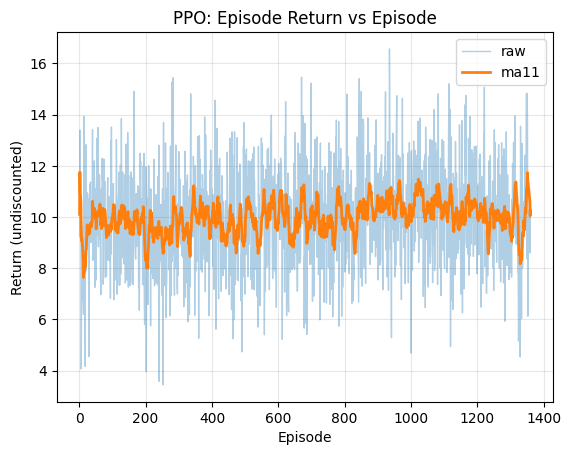

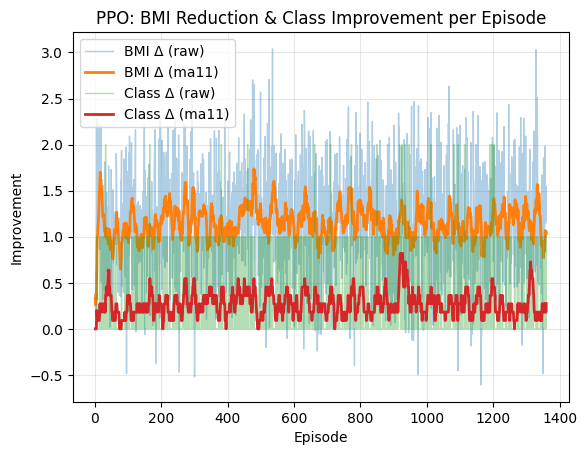

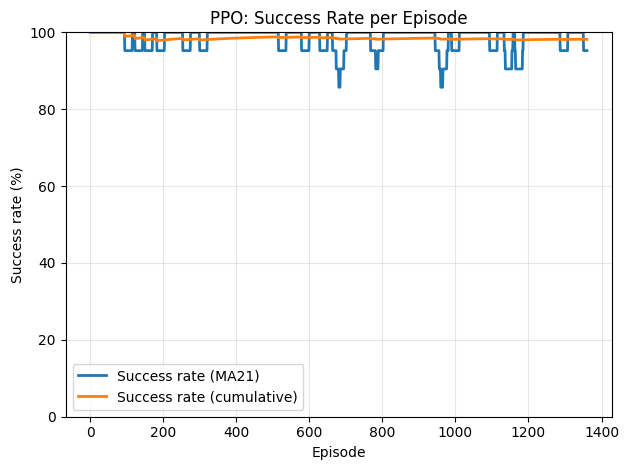

Overall success rate: 98.16% | Last-100 episodes: 98.00%

Ensemble Evaluation Results:
Average Reward:      9.38 ± 1.80
Average Len:         30.00
Success Rate:        1.00
Avg BMI Change:      +1.25
Avg Class Change:    +0.12
----------------------------------------------------------------------
----------------------------------------------------------------------
--- Trial 2/4 ---
lr=0.0001 | gamma=0.97 | clip_eps=0.2 | ent_coef=0.02 | hidden_sizes=(128, 256)
----------------------------------------------------------------------
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.020 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [128, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +10.94 ± 2.14 | succ 0.88 | BMI Δ +1.036 |

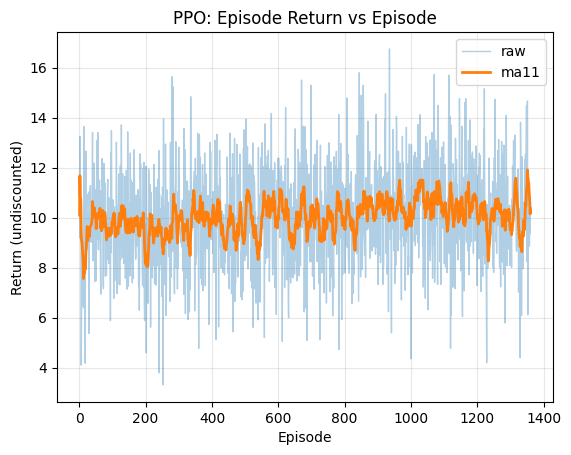

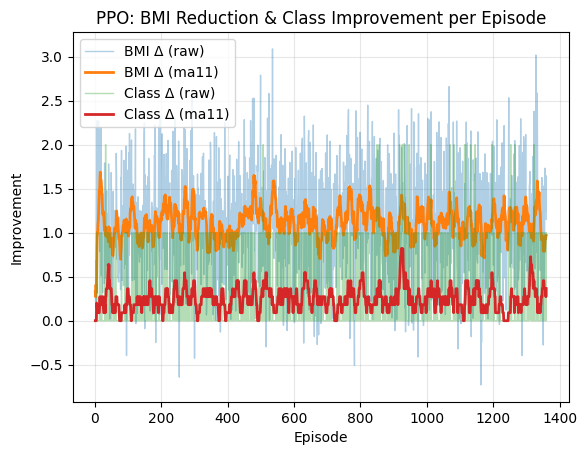

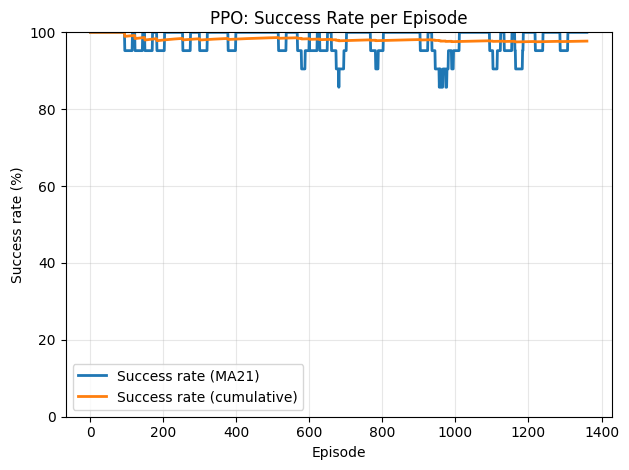

Overall success rate: 97.72% | Last-100 episodes: 99.00%

Ensemble Evaluation Results:
Average Reward:      9.51 ± 1.89
Average Len:         30.00
Success Rate:        1.00
Avg BMI Change:      +1.34
Avg Class Change:    +0.12
----------------------------------------------------------------------
----------------------------------------------------------------------
--- Trial 3/4 ---
lr=0.0005 | gamma=0.95 | clip_eps=0.3 | ent_coef=0.05 | hidden_sizes=(256, 256)
----------------------------------------------------------------------
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +10.64 ± 2.06 | succ 0.75 | BMI Δ +0.884 |

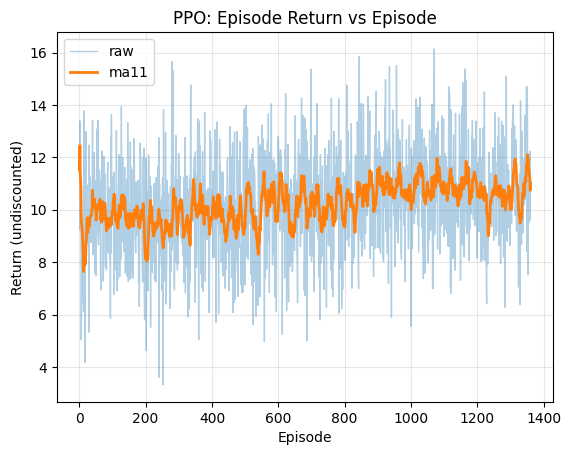

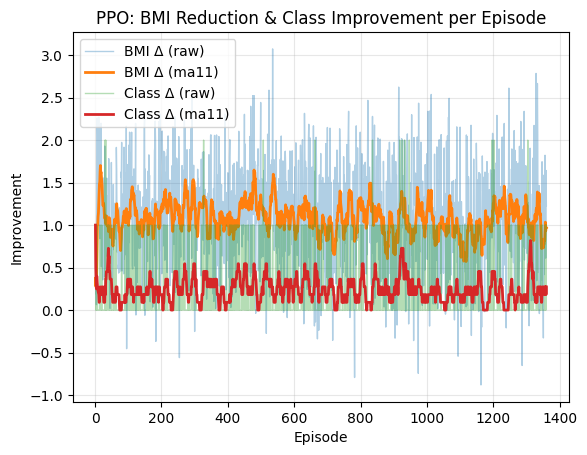

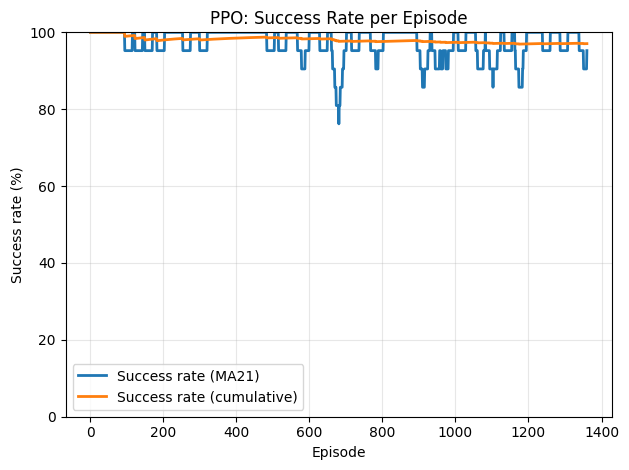

Overall success rate: 97.06% | Last-100 episodes: 97.00%

Ensemble Evaluation Results:
Average Reward:      10.53 ± 1.89
Average Len:         30.00
Success Rate:        1.00
Avg BMI Change:      +0.95
Avg Class Change:    +0.12
----------------------------------------------------------------------
----------------------------------------------------------------------
--- Trial 4/4 ---
lr=0.0003 | gamma=0.99 | clip_eps=0.2 | ent_coef=0.1 | hidden_sizes=(128, 128)
----------------------------------------------------------------------
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.100 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [128, 128] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +11.28 ± 1.97 | succ 1.00 | BMI Δ +1.040 |

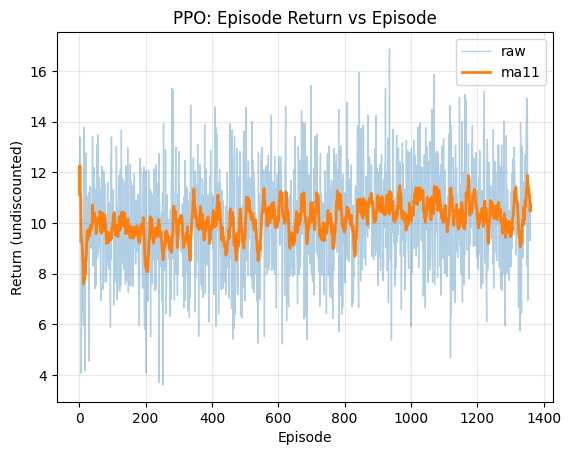

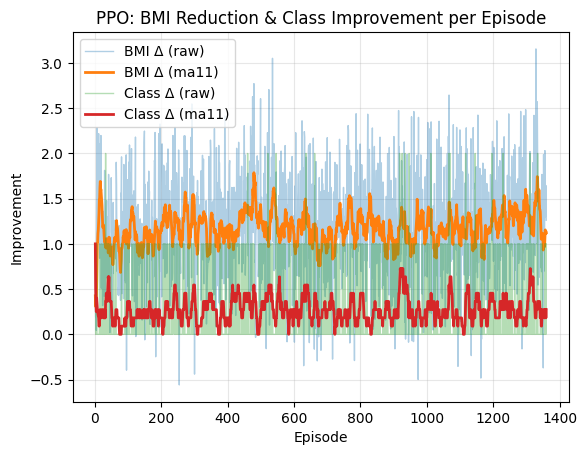

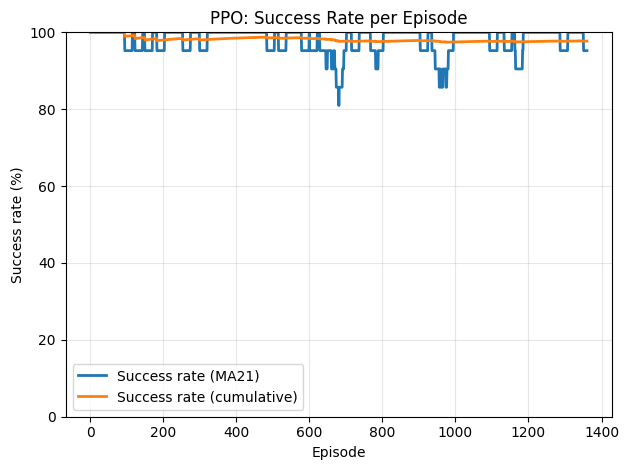

Overall success rate: 97.72% | Last-100 episodes: 98.00%

Ensemble Evaluation Results:
Average Reward:      9.23 ± 1.81
Average Len:         30.00
Success Rate:        1.00
Avg BMI Change:      +1.27
Avg Class Change:    +0.12
----------------------------------------------------------------------

Best Hyperparameters Selected
lr=0.0005 | gamma=0.95 | clip_eps=0.3 | ent_coef=0.05 | hidden_sizes=(256, 256)

Comparison (Eval Mean Return):
----------------------------------------------------------------------
Trial    EvalMean    Succ    BMI Δ  Class Δ   HP
----------------------------------------------------------------------
1            9.38    1.00    1.252     0.12   lr=0.0003 | gamma=0.99 | clip_eps=0.1 | ent_coef=0.01 | hidden_sizes=(128, 128)
2            9.51    1.00    1.340     0.12   lr=0.0001 | gamma=0.97 | clip_eps=0.2 | ent_coef=0.02 | hidden_sizes=(128, 256)
3           10.53    1.00    0.955     0.12   lr=0.0005 | gamma=0.95 | clip_eps=0.3 | ent_coef=0.05 | hidden_sizes=(

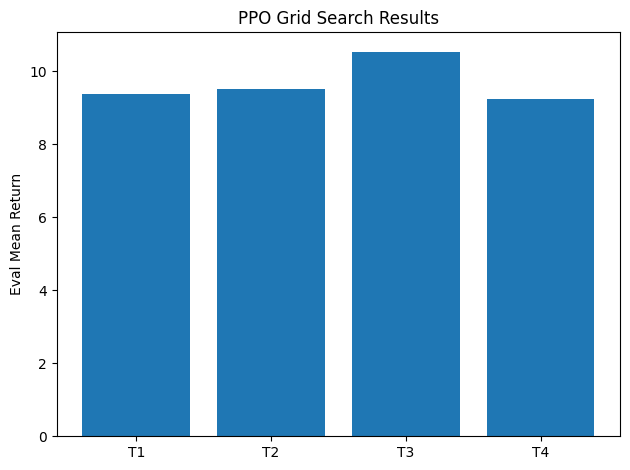

Selected BEST hyperparameters: {'lr': 0.0005, 'gamma': 0.95, 'clip_eps': 0.3, 'ent_coef': 0.05, 'hidden_sizes': (256, 256)}
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +10.64 ± 2.06 | succ 0.75 | BMI Δ +0.884 | class Δ +0.50 | 
pi -0.0118 | vf +0.3161 | H 1.918 | clip 0.08 | KL 0.0145 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 10.637 (model saved)
steps   40960 | ep  20 | R_eval +11.42 ± 1.76 | succ 1.00 | BMI Δ +1.286 | class Δ +0.38 | 
pi -0.0139 | vf +0.1013 | H 1.408 | clip 0.07 | KL 0.0081 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.421 (model saved)
PP

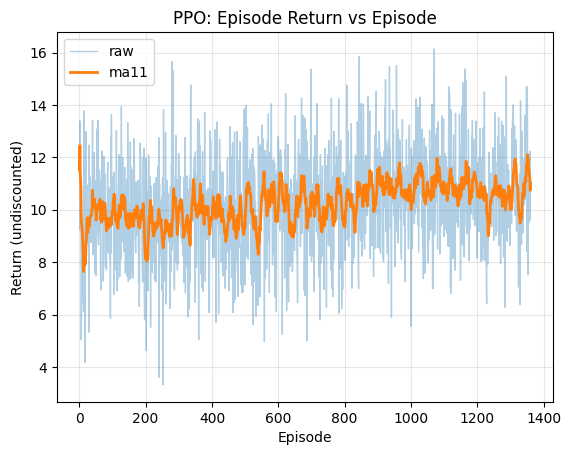

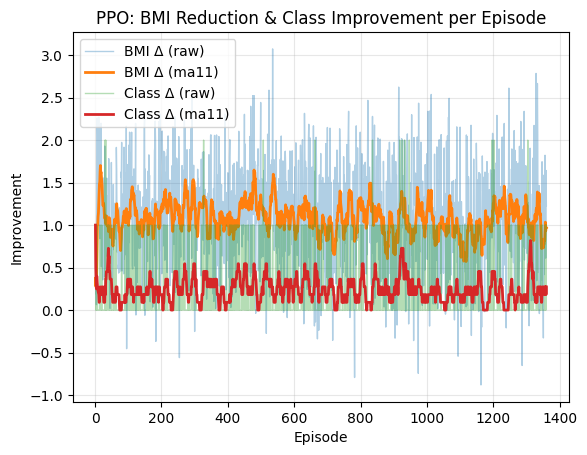

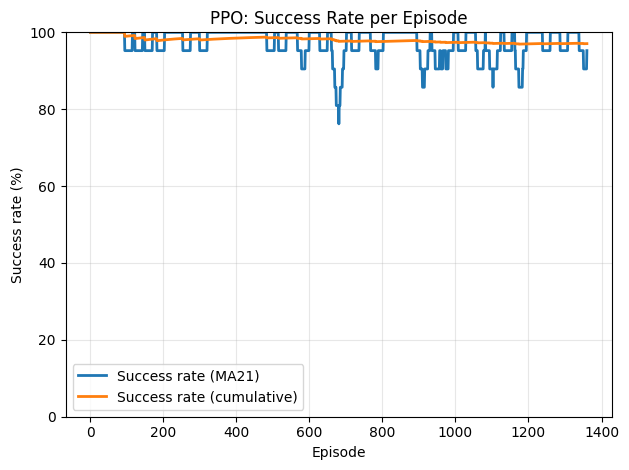

Overall success rate: 97.06% | Last-100 episodes: 97.00%

=== Evaluation (Final Model) ===
ReturnMean=+10.533 | ReturnStd=1.893 | SuccRate=1.00 | BMI↓=0.955 | Class↑=0.12

Ensemble Evaluation Results:
Average Reward:      10.53 ± 1.89
Average Len:         30.00
Success Rate:        1.00
Avg BMI Change:      +0.95
Avg Class Change:    +0.12
----------------------------------------------------------------------


In [46]:
base = PPOConfig(
    total_env_steps=40_000,
    steps_per_rollout=2048,
    update_epochs=10,
    minibatch_size=128,
    eval_every_steps=20_000,
    eval_episodes=8,
    log_dir="./ppo_logs"
)
ensure_dir(base.log_dir)
print("\n=== PPO Configuration ===")
print(pformat(asdict(base), width=100, compact=True))

print("\n=== Hyperparameter Optimization (Grid Search) ===")
best_hp = grid_search_and_train(base)
print("Selected BEST hyperparameters:", best_hp)

final_cfg = asdict(base)
final_cfg.update(best_hp)
final_cfg["log_dir"] = os.path.join(base.log_dir, "final_best")
trainer, _, final_metrics = run_single(final_cfg)

print("\n=== Evaluation (Final Model) ===")
print("ReturnMean={:+.3f} | ReturnStd={:.3f} | SuccRate={:.2f} | BMI↓={:.3f} | Class↑={:.2f}".format(
    final_metrics["return_mean"], final_metrics["return_std"],
    final_metrics["success_rate"], final_metrics["bmi_reduction_mean"], final_metrics["class_improve_mean"]
))
_print_trial_summary(final_metrics)

Exploration Strategy Comparison (Entropy vs ε-greedy)

In [47]:
def _ma(y, k=20):
    if not y: return []
    k = max(1, int(k))
    out, s, q = [], 0.0, []
    for v in y:
        q.append(v); s += v
        if len(q) > k: s -= q.pop(0)
        out.append(s/len(q))
    return out

def _rolling_std(y, k=30):
    if not y: return []
    k = max(1, int(k))
    out, q = [], []
    for v in y:
        q.append(v)
        if len(q) > k: q.pop(0)
        m = sum(q)/len(q)
        out.append((sum((u-m)**2 for u in q)/len(q))**0.5)
    return out

def _fmt_hp(hp: dict):
    return " | ".join([f"{k}={hp[k]}" for k in ["lr","gamma","clip_eps","ent_coef"]]) + \
           f" | hidden_sizes={hp.get('hidden_sizes')}"

In [48]:
def run_exploration_training(base_cfg: PPOConfig, best_hp: dict):
    runs = {}

    # Entropy-based PPO
    print("\n=== Entropy ===")
    cfgE = asdict(base_cfg); cfgE.update(best_hp)
    cfgE["epsilon_greedy_eval"] = False
    cfgE["log_dir"] = os.path.join(base_cfg.log_dir, "explore_entropy")
    trainerE, _, metE = run_single(cfgE)
    runs["Entropy"] = {"name":"Entropy", "trainer":trainerE, "metrics":metE, "dir":cfgE["log_dir"]}

    # ε-greedy at evaluation
    print("\n=== Epsilon-Greedy ===")
    cfgG = asdict(base_cfg); cfgG.update(best_hp)
    cfgG["epsilon_greedy_eval"] = True
    cfgG["log_dir"] = os.path.join(base_cfg.log_dir, "explore_epsgreedy")
    trainerG, _, metG = run_single(cfgG)
    runs["EpsGreedy"] = {"name":"Epsilon-Greedy", "trainer":trainerG, "metrics":metG, "dir":cfgG["log_dir"]}

    return runs


=== Exploration Strategy Comparison ===

=== Entropy ===
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +10.64 ± 2.06 | succ 0.75 | BMI Δ +0.884 | class Δ +0.50 | 
pi -0.0118 | vf +0.3161 | H 1.918 | clip 0.08 | KL 0.0145 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 10.637 (model saved)
steps   40960 | ep  20 | R_eval +11.42 ± 1.76 | succ 1.00 | BMI Δ +1.286 | class Δ +0.38 | 
pi -0.0139 | vf +0.1013 | H 1.408 | clip 0.07 | KL 0.0081 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.421 (model saved)
PPO Training Complete.
Best eval mean return: 11.421


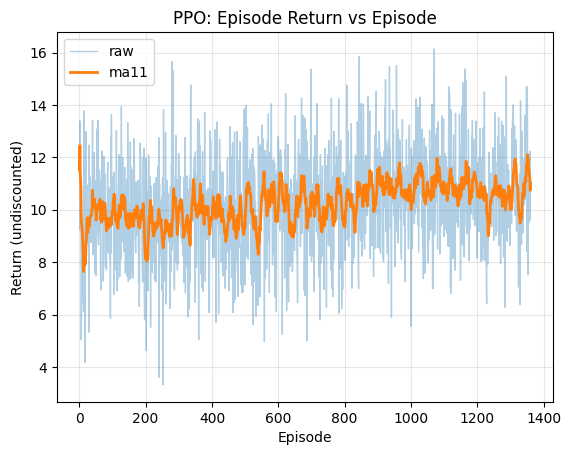

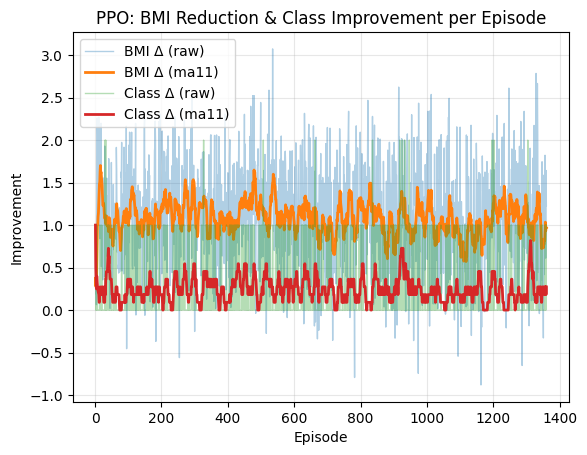

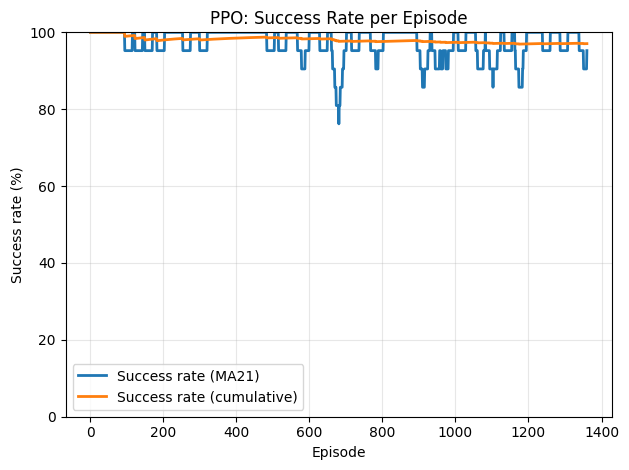

Overall success rate: 97.06% | Last-100 episodes: 97.00%

=== Epsilon-Greedy ===
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +11.22 ± 1.95 | succ 0.88 | BMI Δ +0.980 | class Δ +0.50 | 
pi -0.0073 | vf +0.3156 | H 1.865 | clip 0.06 | KL 0.0152 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.223 (model saved)
steps   40960 | ep  20 | R_eval +11.86 ± 1.18 | succ 1.00 | BMI Δ +1.564 | class Δ +0.62 | 
pi -0.0141 | vf +0.1093 | H 1.264 | clip 0.09 | KL 0.0170 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.863 (model saved)
PPO Training Complete.
Best eval mean return:

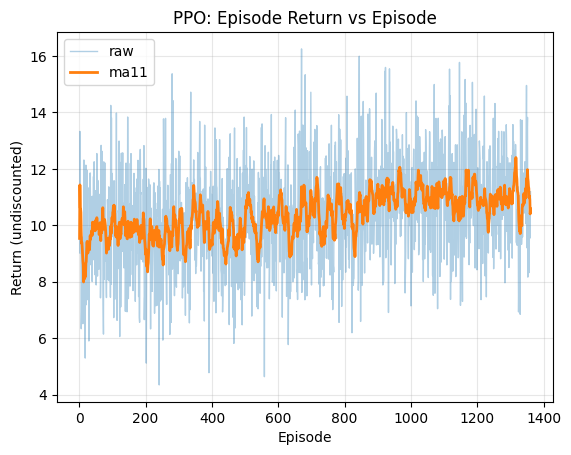

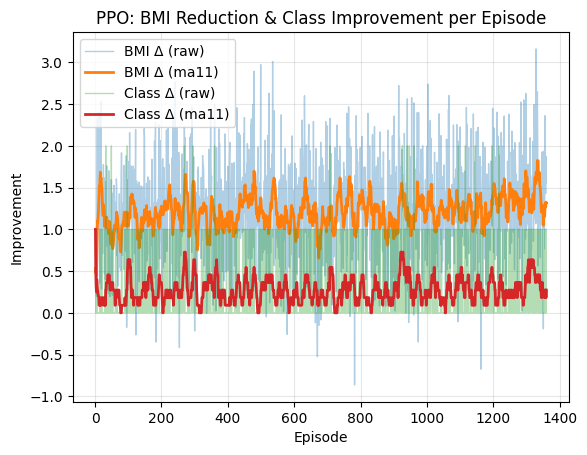

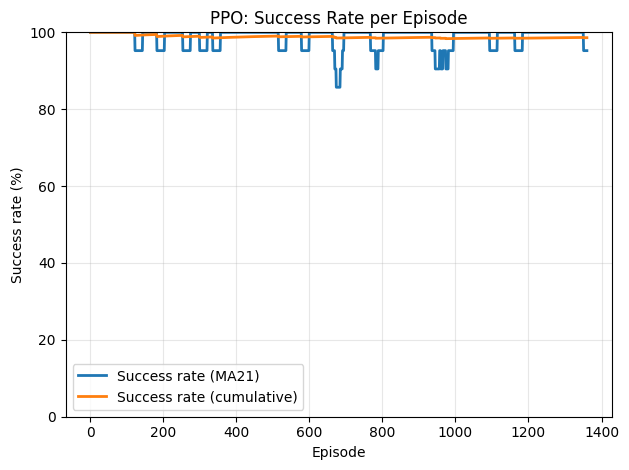

Overall success rate: 98.60% | Last-100 episodes: 99.00%


In [49]:
print("\n=== Exploration Strategy Comparison ===")
EXP_RUNS = run_exploration_training(base, best_hp)

Exploration Evaluation


--- Exploration Comparison Summary ---
Method         | EvalMean   | SuccRate |  BMI↓   | Class↑  | lr=0.0005 | gamma=0.95 | clip_eps=0.3 | ent_coef=0.05 | hidden_sizes=(256, 256)
---------------+------------+----------+---------+---------
Entropy        |    +10.533 |     1.00 |  0.955 |   0.12
Epsilon-Greedy |    +10.847 |     1.00 |  1.413 |   0.25

WINNER: Epsilon-Greedy  |  Margin: +0.31 reward  |  Advantage: 3.0%


/tmp/ipython-input-1757182705.py:71: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.35, wspace=0.3)
/tmp/ipython-input-1757182705.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bA[-tail:], bB[-tail:]], labels=[A["name"], B["name"]])


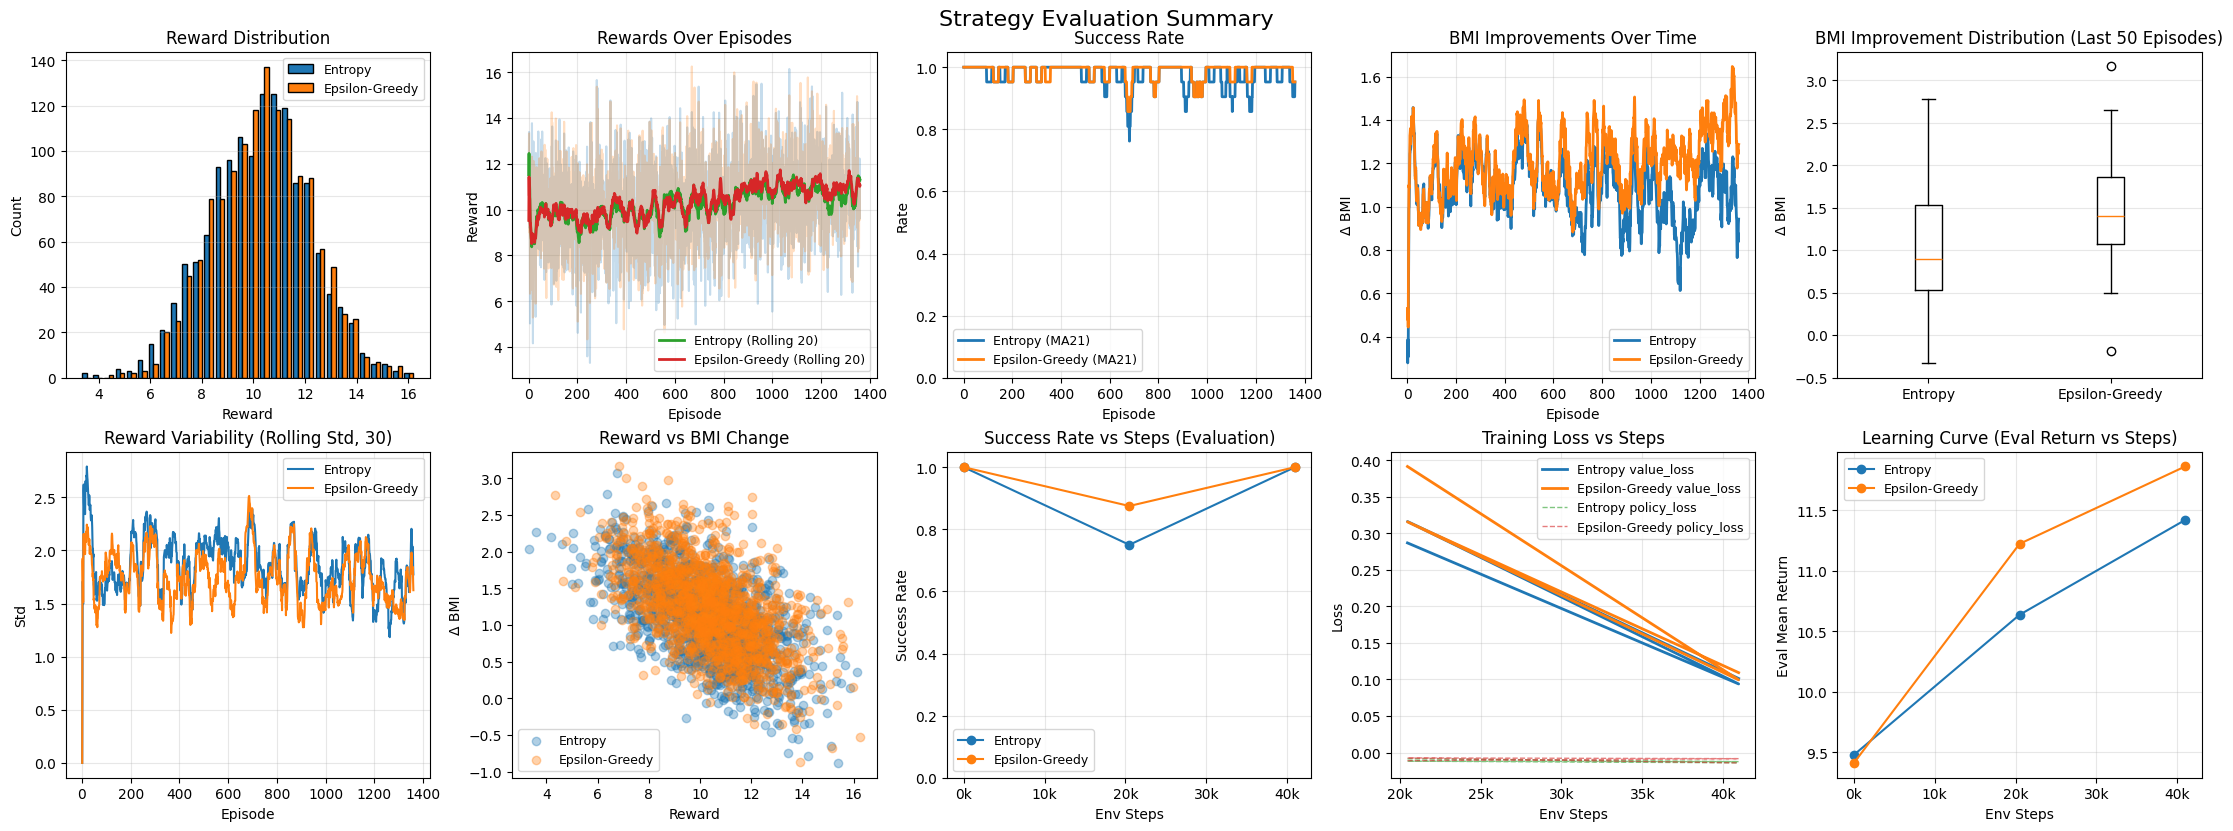


Summary
- Entropy:         EvalMean=+10.53, Success=1.00, BMI↓=0.955, Class↑=0.12
- Epsilon-Greedy:  EvalMean=+10.85, Success=1.00, BMI↓=1.413, Class↑=0.25
- WINNER: Epsilon-Greedy | Margin: +0.31 | Advantage: 3.0%


In [50]:
def evaluate_exploration_runs(runs: dict, best_hp: dict):
    def _read_losses_from_trace_or_csv(run):
        tr = run["trainer"]
        steps = tr.trace.get("steps", [])
        pi = tr.trace.get("pi_loss", [])
        vf = tr.trace.get("vf_loss", [])
        if steps and pi and vf and len(steps) == len(pi) == len(vf):
            return np.array(steps), np.array(pi), np.array(vf)

        csv_path = os.path.join(run["dir"], "ppo_train_log.csv")
        if not os.path.exists(csv_path):
            return np.array([]), np.array([]), np.array([])

        out_steps, out_pi, out_vf = [], [], []
        with open(csv_path, "r", newline="") as f:
            rdr = csv.DictReader(f)
            for row in rdr:
                try:
                    out_steps.append(float(row["steps"]))
                    out_pi.append(float(row["policy_loss"]))
                    out_vf.append(float(row["value_loss"]))
                except Exception:
                    continue
        return np.array(out_steps), np.array(out_pi), np.array(out_vf)

    def _format_steps_axis(ax):
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v/1000)}k"))

    A = runs["Entropy"]
    B = runs["EpsGreedy"]
    mA, mB = A["metrics"], B["metrics"]

    print("\n--- Exploration Comparison Summary ---")
    print("Method         | EvalMean   | SuccRate |  BMI↓   | Class↑  |", _fmt_hp(best_hp))
    print("---------------+------------+----------+---------+---------")
    for name,data in (("Entropy",A),("Epsilon-Greedy",B)):
        m = data["metrics"]
        print(f"{name:<14s} | {m['return_mean']:>+10.3f} | {m['success_rate']:>8.2f} | "
              f"{m['bmi_reduction_mean']:>6.3f} | {m['class_improve_mean']:>6.2f}")

    def score(m):
        return (m["return_mean"], m["success_rate"], m["bmi_reduction_mean"], m["class_improve_mean"])
    (win, lose) = (A,B) if score(mA) >= score(mB) else (B,A)
    margin = win["metrics"]["return_mean"] - lose["metrics"]["return_mean"]
    adv = 100.0 * margin / max(1e-8, abs(lose["metrics"]["return_mean"]))
    print(f"\nWINNER: {win['name']}  |  Margin: {margin:+.2f} reward  |  Advantage: {adv:.1f}%")

    xlen = min(len(A["trainer"].trace["ep_ret"]), len(B["trainer"].trace["ep_ret"]))

    def cut(tkey):
        return A["trainer"].trace[tkey][:xlen], B["trainer"].trace[tkey][:xlen]
    rA,rB = cut("ep_ret")
    bA,bB = cut("ep_bmi")
    sA,sB = cut("ep_succ")
    x = np.arange(1, xlen+1)

    stepsA = np.array(A["trainer"].trace["steps"])
    stepsB = np.array(B["trainer"].trace["steps"])
    evalRetA = np.array(A["trainer"].trace["eval_ret"])
    evalRetB = np.array(B["trainer"].trace["eval_ret"])
    succA = np.array(A["trainer"].trace["succ"])
    succB = np.array(B["trainer"].trace["succ"])

    # training losses (at eval points)
    LstepsA, piA, vfA = _read_losses_from_trace_or_csv(A)
    LstepsB, piB, vfB = _read_losses_from_trace_or_csv(B)

    fig, axs = plt.subplots(2, 5, figsize=(22, 8), constrained_layout=True)
    fig.suptitle("Strategy Evaluation Summary", fontsize=16, y=1.02)
    fig.subplots_adjust(hspace=0.35, wspace=0.3)

    # Reward distribution
    ax = axs[0,0]
    bins = np.histogram_bin_edges(np.r_[rA, rB], bins=30)
    cA, _ = np.histogram(rA, bins=bins)
    cB, _ = np.histogram(rB, bins=bins)
    centers = 0.5 * (bins[:-1] + bins[1:])
    width   = (bins[1] - bins[0])

    ax.bar(centers - 0.5*width*0.8/2, cA, width=0.8*width/2, label=A["name"], edgecolor="black")
    ax.bar(centers + 0.5*width*0.8/2, cB, width=0.8*width/2, label=B["name"], edgecolor="black")
    ax.set_title("Reward Distribution"); ax.set_xlabel("Reward"); ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=9)

    # Rewards over episodes (raw + rolling)
    ax = axs[0,1]
    ax.plot(x, rA, alpha=0.25)
    ax.plot(x, rB, alpha=0.25)
    ax.plot(x, _ma(rA,20), linewidth=2, label=f"{A['name']} (Rolling 20)")
    ax.plot(x, _ma(rB,20), linewidth=2, label=f"{B['name']} (Rolling 20)")
    ax.set_title("Rewards Over Episodes")
    ax.set_xlabel("Episode"); ax.set_ylabel("Reward")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # Success rate
    ax = axs[0,2]
    ax.plot(x, _ma(sA, 21), linewidth=2, label=f"{A['name']} (MA21)")
    ax.plot(x, _ma(sB, 21), linewidth=2, label=f"{B['name']} (MA21)")
    ax.set_ylim(0, 1.05)
    ax.set_title("Success Rate"); ax.set_xlabel("Episode")
    ax.set_ylabel("Rate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # BMI improvements over episodes
    ax = axs[0,3]
    ax.plot(x, _ma(bA,20), linewidth=2, label=A["name"])
    ax.plot(x, _ma(bB,20), linewidth=2, label=B["name"])
    ax.set_title("BMI Improvements Over Time")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Δ BMI")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # BMI distribution (last 50)
    ax = axs[0,4]
    tail=min(50,xlen)
    ax.boxplot([bA[-tail:], bB[-tail:]], labels=[A["name"], B["name"]])
    ax.set_title(f"BMI Improvement Distribution (Last {tail} Episodes)")
    ax.set_ylabel("Δ BMI")
    ax.grid(True, axis='y', alpha=0.3)

    # Reward variability (rolling std)
    ax = axs[1,0]
    ax.plot(x, _rolling_std(rA,30), label=A["name"])
    ax.plot(x, _rolling_std(rB,30), label=B["name"])
    ax.set_title("Reward Variability (Rolling Std, 30)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Std")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # Scatter: Reward vs BMI change
    ax = axs[1,1]
    ax.scatter(rA, bA, alpha=0.35, label=A["name"])
    ax.scatter(rB, bB, alpha=0.35, label=B["name"])
    ax.set_title("Reward vs BMI Change")
    ax.set_xlabel("Reward")
    ax.set_ylabel("Δ BMI")
    ax.legend(fontsize=9)

    # Step-based evaluation success (from evaluate() calls)
    ax = axs[1,2]
    ax.plot(A["trainer"].trace["steps"], A["trainer"].trace["succ"], marker='o', linewidth=1.5, label=A["name"])
    ax.plot(B["trainer"].trace["steps"], B["trainer"].trace["succ"], marker='o', linewidth=1.5, label=B["name"])
    ax.set_title("Success Rate vs Steps (Evaluation)")
    ax.set_xlabel("Env Steps")
    ax.set_ylabel("Success Rate")
    ax.set_ylim(0,1.05)
    _format_steps_axis(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # Training loss vs steps
    ax = axs[1, 3]
    if LstepsA.size and LstepsB.size:
        ax.plot(LstepsA, vfA, linewidth=2, label=f"{A['name']} value_loss")
        ax.plot(LstepsB, vfB, linewidth=2, label=f"{B['name']} value_loss")

        if piA.size and piB.size:
            ax.plot(LstepsA, piA, linewidth=1, alpha=0.6, linestyle="--", label=f"{A['name']} policy_loss")
            ax.plot(LstepsB, piB, linewidth=1, alpha=0.6, linestyle="--", label=f"{B['name']} policy_loss")
    ax.set_title("Training Loss vs Steps")
    ax.set_xlabel("Env Steps")
    ax.set_ylabel("Loss")
    _format_steps_axis(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # Learning curve (Eval Return vs Steps)
    ax = axs[1, 4]
    ax.plot(stepsA, evalRetA, marker='o', linewidth=1.5, label=A["name"])
    ax.plot(stepsB, evalRetB, marker='o', linewidth=1.5, label=B["name"])
    ax.set_title("Learning Curve (Eval Return vs Steps)")
    ax.set_xlabel("Env Steps")
    ax.set_ylabel("Eval Mean Return")
    _format_steps_axis(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.show()

    print("\nSummary")
    print(f"- Entropy:         EvalMean={mA['return_mean']:+.2f}, "
          f"Success={mA['success_rate']:.2f}, BMI↓={mA['bmi_reduction_mean']:.3f}, "
          f"Class↑={mA['class_improve_mean']:.2f}")
    print(f"- Epsilon-Greedy:  EvalMean={mB['return_mean']:+.2f}, "
          f"Success={mB['success_rate']:.2f}, BMI↓={mB['bmi_reduction_mean']:.3f}, "
          f"Class↑={mB['class_improve_mean']:.2f}")
    print(f"- WINNER: {win['name']} | Margin: {margin:+.2f} | Advantage: {adv:.1f}%")

    return win["name"], win["trainer"], win["metrics"]

winner_name, winner_trainer, winner_metrics = evaluate_exploration_runs(EXP_RUNS, best_hp)

Generalization

In [51]:
def generalization_suite(
    best_hp: dict,
    base_cfg: PPOConfig,
    seeds=(0, 7, 42),
    best_strategy="auto",
    episodes=16,
    adapt_steps=0,
    log_name="gen_suite"
):

    def _moving_avg(x, k=11):
        if len(x) < 2: return np.asarray(x)
        k = max(1, min(k, len(x)))
        w = np.ones(k)/k
        y = np.convolve(np.asarray(x), w, mode="same")
        return y

    def _cummean(x):
        x = np.asarray(x, dtype=float)
        if x.size == 0: return x
        return np.cumsum(x)/np.arange(1, len(x)+1)

    COL = dict(var=20, eval=10, succ=9, bmi=8, cls=7)
    def _hdr(title):
        print(f"\n--- {title} ---")
        h = (f"{'Variant':<{COL['var']}}│"
             f"{'EvalMean':^{COL['eval']}}│"
             f"{'SuccRate':^{COL['succ']}}│"
             f"{'BMI↓':^{COL['bmi']}}│"
             f"{'Class↑':^{COL['cls']}}")
        s = (f"{'─'*COL['var']}┼{'─'*COL['eval']}┼{'─'*COL['succ']}┼{'─'*COL['bmi']}┼{'─'*COL['cls']}")
        print(h); print(s)

    def _row(name, m):
        print(f"{name:<{COL['var']}}│"
              f"{m['return_mean']:+{COL['eval']}.3f}│"
              f"{m['success_rate']:{COL['succ']}.2f}│"
              f"{m['bmi_reduction_mean']:{COL['bmi']}.3f}│"
              f"{m['class_improve_mean']:{COL['cls']}.2f}")

    # Decide the exploration strategy to use for generalization
    use_eps = False
    pick_from_runs = False
    if isinstance(best_strategy, str) and best_strategy.lower() == "auto":
        try:
            if "winner_name" in globals():
                use_eps = ("eps" in str(globals()["winner_name"]).lower())
            elif "EXP_RUNS" in globals() and isinstance(EXP_RUNS, dict):
                mE = EXP_RUNS["Entropy"]["metrics"]["return_mean"]
                mG = EXP_RUNS["EpsGreedy"]["metrics"]["return_mean"]
                use_eps = (mG >= mE)
                pick_from_runs = True
            else:
                use_eps = False
        except Exception:
            use_eps = False
    else:
        use_eps = ("eps" in str(best_strategy).lower())

    strategy_name = "Epsilon-Greedy" if use_eps else "Entropy"
    print(f"\n=== [Generalization] Using BEST exploration strategy: {strategy_name} ===")

    # Train ONCE per seed with the chosen strategy (in-domain)
    TRAINED = []  # list of dicts: {seed, trainer, train_metrics, log_dir}
    for s in seeds:
        cfg_over = asdict(base_cfg)
        cfg_over.update(best_hp)
        cfg_over["seed"] = int(s)
        cfg_over["epsilon_greedy_eval"] = bool(use_eps)
        cfg_over["log_dir"] = os.path.join(base_cfg.log_dir, f"{log_name}_seed{s}")
        ensure_dir(cfg_over["log_dir"])
        trainer, _, train_metrics = run_single(cfg_over)
        TRAINED.append(dict(seed=s, trainer=trainer, metrics=train_metrics, dir=cfg_over["log_dir"]))

    # Define test variants (OOD situations)
    class ObsNoiseWrapper(gym.ObservationWrapper):
        def __init__(self, env, sigma=0.02):
            super().__init__(env); self.sigma = float(sigma)
        def observation(self, obs):
            return obs + np.random.normal(0.0, self.sigma, size=obs.shape).astype(np.float32)

    def make_variant_env(seed, *, difficulty=None, shaping=True, curriculum=True,
                         obs_noise=0.0, bmi_shift=0.0):
        env_core = HealthCoachEnv(action_type="discrete", seed=seed)
        # Difficulty
        if difficulty is not None:
            try:
                env_core.difficulty = str(difficulty)
            except Exception:
                pass

        if bmi_shift and hasattr(env_core, "target_bmi"):
            try: env_core.target_bmi = float(env_core.target_bmi) + float(bmi_shift)
            except Exception: pass
        # Wrap
        env_wrapped = env_core
        if curriculum:
            env_wrapped = CurriculumWrapper(
                env_wrapped,
                med_start=base_cfg.curriculum_boundaries[0],
                hard_start=base_cfg.curriculum_boundaries[1]
            )
        if shaping:
            env_wrapped = RewardShapingWrapper(env_wrapped, lifestyle_weight=0.5, bmi_weight=0.05)
        if obs_noise > 0:
            env_wrapped = ObsNoiseWrapper(env_wrapped, sigma=obs_noise)
        return env_wrapped

    VARIANTS = [
        ("ID (match train)",   dict(difficulty=None, shaping=True,  curriculum=True,  obs_noise=0.0, bmi_shift=0.0)),
        ("MED difficulty",     dict(difficulty="medium", shaping=True, curriculum=True, obs_noise=0.0, bmi_shift=0.0)),
        ("HARD difficulty",    dict(difficulty="hard",   shaping=True, curriculum=True, obs_noise=0.0, bmi_shift=0.0)),
        ("No shaping",         dict(difficulty=None, shaping=False, curriculum=True,  obs_noise=0.0, bmi_shift=0.0)),
        ("No curriculum",      dict(difficulty="hard",  shaping=True,  curriculum=False, obs_noise=0.0, bmi_shift=0.0)),
        ("Noisy obs (σ=0.03)", dict(difficulty=None, shaping=True,  curriculum=True,  obs_noise=0.03, bmi_shift=0.0)),
        ("BMI target +1",      dict(difficulty=None, shaping=True,  curriculum=True,  obs_noise=0.0, bmi_shift=1.0)),
    ]

    # Evaluate frozen policy on each variant (no retraining)
    def evaluate_on_env(trainer: PPOTrainer, env, episodes=8, epsilon_greedy=False):
        """Evaluation that uses the trainer's policy but a *new* env instance."""
        returns, lens = [], []
        bmi_reds, class_imps = [], []
        succ = 0
        for _ in range(episodes):
            reset_out = env.reset()
            obs = reset_out[0] if (GYMNASIUM and isinstance(reset_out, tuple)) else reset_out
            done = False
            ep_ret, ep_len = 0.0, 0
            start_bmi, start_class = None, None
            last_info = {}
            while not done:
                a, _, _ = trainer._select_action(obs, epsilon_greedy=epsilon_greedy)
                step_out = env.step(a)
                if GYMNASIUM:
                    obs, r, terminated, truncated, info = step_out
                    done = bool(terminated or truncated)
                else:
                    obs, r, done, info = step_out
                ep_ret += float(r); ep_len += 1; last_info = info
                if start_bmi is None:   start_bmi = info.get("bmi", None)
                if start_class is None: start_class = info.get("obesity_class", None)
            # episode end
            end_bmi = last_info.get("bmi", start_bmi)
            end_class = last_info.get("obesity_class", start_class)
            if (start_bmi is not None) and (end_bmi is not None):
                bmi_reds.append(float(start_bmi - end_bmi))
                if end_bmi < start_bmi: succ += 1
            if (start_class is not None) and (end_class is not None):
                class_imps.append(max(0, int(end_class is not None and start_class) and int(start_class) - int(end_class)))
            returns.append(ep_ret); lens.append(ep_len)
        return dict(
            return_mean=float(np.mean(returns)),
            return_std=float(np.std(returns)),
            len_mean=float(np.mean(lens)),
            success_rate=float(succ / max(1, episodes)),
            bmi_reduction_mean=float(np.mean(bmi_reds) if bmi_reds else 0.0),
            class_improve_mean=float(np.mean(class_imps) if class_imps else 0.0),
        )

    REPORT = {name: [] for name, _ in VARIANTS}

    for name, spec in VARIANTS:
        for pack in TRAINED:
            env = make_variant_env(seed=pack["seed"], **spec)
            m = evaluate_on_env(pack["trainer"], env, episodes=episodes,
                                epsilon_greedy=use_eps)
            REPORT[name].append(m)

    # Summaries, gap, and (optional) quick adaptation
    def _meanstd(ms, key):
        xs = [m[key] for m in ms]
        return float(np.mean(xs)), float(np.std(xs))

    _hdr("PPO Generalization Summary (across seeds)")
    id_mean, _ = _meanstd(REPORT["ID (match train)"], "return_mean")
    for name, _ in VARIANTS:
        ms = REPORT[name]
        row = dict(
            return_mean=_meanstd(ms, "return_mean")[0],
            success_rate=_meanstd(ms, "success_rate")[0],
            bmi_reduction_mean=_meanstd(ms, "bmi_reduction_mean")[0],
            class_improve_mean=_meanstd(ms, "class_improve_mean")[0],
        )
        _row(name, row)
    print("\nHP:", _fmt_hp(best_hp))

    print("\nGeneralization Gap (EvalMean drop vs ID):")
    for name, _ in VARIANTS:
        m, _ = _meanstd(REPORT[name], "return_mean")
        gap = m - id_mean
        print(f"  {name:<20s} : {gap:+.2f}")

    ADAPT = {}
    if adapt_steps and adapt_steps > 0:
        print(f"\n[Adaptation] Fine-tuning {adapt_steps} env-steps per OOD variant (frozen copy per seed)...")
        for name, spec in VARIANTS:
            if "ID (" in name:
                continue
            deltas = []
            for pack in TRAINED:
                t = pack["trainer"]
                tmp = copy.deepcopy(t)
                tmp.env = make_variant_env(seed=pack["seed"], **spec)
                before = evaluate_on_env(tmp, tmp.env, episodes=episodes, epsilon_greedy=use_eps)["return_mean"]
                done_steps = 0
                while done_steps < adapt_steps:
                    buf, _ = tmp._rollout(min(base_cfg.steps_per_rollout, adapt_steps - done_steps))
                    tmp._ppo_update(buf, ent_coef_current=base_cfg.ent_coef)
                    done_steps += base_cfg.steps_per_rollout
                after = evaluate_on_env(tmp, tmp.env, episodes=episodes, epsilon_greedy=use_eps)["return_mean"]
                deltas.append(after - before)
            ADAPT[name] = (float(np.mean(deltas)), float(np.std(deltas)))
        print("Adaptation Δ(EvalMean) by variant (mean±std):")
        for k, (mu, sd) in ADAPT.items():
            print(f"  {k:<20s} : {mu:+.2f} ± {sd:.2f}")

    # Plots
    outdir = os.path.join(base_cfg.log_dir, log_name, "plots")
    ensure_dir(outdir)

    names = [n for n,_ in VARIANTS]
    means = [ _meanstd(REPORT[n], "return_mean")[0] for n in names ]
    stds  = [ _meanstd(REPORT[n], "return_mean")[1] for n in names ]
    succs = [ _meanstd(REPORT[n], "success_rate")[0] for n in names ]

    # Eval mean return with error bars
    plt.figure(figsize=(10,4))
    x = np.arange(len(names))
    plt.bar(x, means, yerr=stds, capsize=4)
    plt.xticks(x, names, rotation=20, ha='right')
    plt.ylabel("Eval Mean Return"); plt.title(f"Generalization (strategy={strategy_name})")
    plt.tight_layout(); plt.savefig(os.path.join(outdir, "gen_evalmean_bars.png")); plt.show()

    # Success rate line
    plt.figure(figsize=(10,3.8))
    plt.plot(x, succs, marker='o', linewidth=2)
    plt.xticks(x, names, rotation=20, ha='right'); plt.ylim(0, 1.05)
    plt.ylabel("Success Rate"); plt.title("Success Rate across Variants")
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(outdir, "gen_success_line.png")); plt.show()

    # Boxplot of per-seed returns per variant
    plt.figure(figsize=(11,4))
    data = [ [m["return_mean"] for m in REPORT[n]] for n in names ]
    plt.boxplot(data, labels=names, showfliers=False)
    plt.xticks(rotation=20, ha='right')
    plt.ylabel("Eval Mean Return"); plt.title("Per-Seed Distribution by Variant")
    plt.tight_layout(); plt.savefig(os.path.join(outdir, "gen_returns_boxplot.png")); plt.show()

    return dict(strategy=strategy_name, report=REPORT, adapt=ADAPT if adapt_steps else None)


=== [STEP 6] Generalization (Multi-Seed & Variants) ===

=== [Generalization] Using BEST exploration strategy: Epsilon-Greedy ===
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=0
steps   20480 | ep  10 | R_eval  +9.79 ± 1.86 | succ 0.88 | BMI Δ +1.105 | class Δ +0.00 | 
pi -0.0077 | vf +0.2092 | H 1.890 | clip 0.06 | KL 0.0138 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 9.785 (model saved)
steps   40960 | ep  20 | R_eval +11.57 ± 0.62 | succ 1.00 | BMI Δ +0.946 | class Δ +0.12 | 
pi -0.0066 | vf +0.1072 | H 1.189 | clip 0.08 | KL 0.0168 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.569 (model save

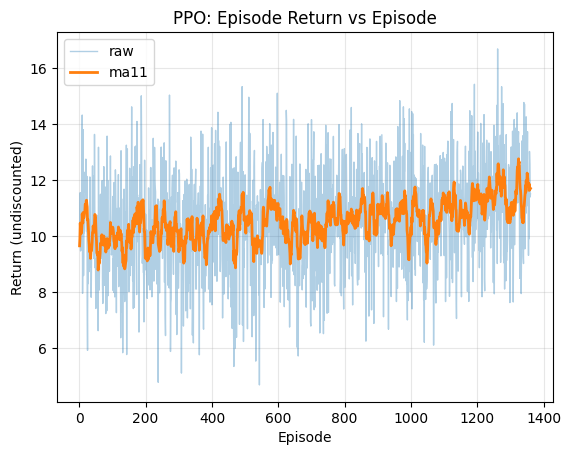

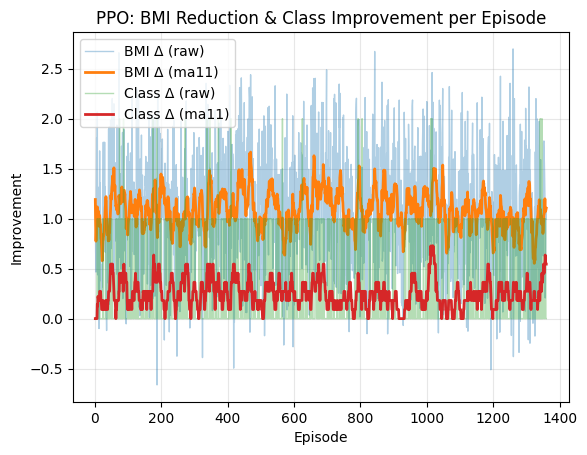

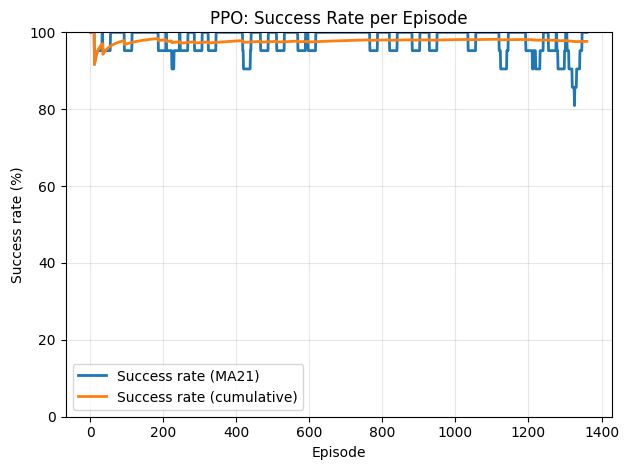

Overall success rate: 97.65% | Last-100 episodes: 94.00%
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=7
steps   20480 | ep  10 | R_eval +10.24 ± 1.87 | succ 1.00 | BMI Δ +1.034 | class Δ +0.38 | 
pi -0.0085 | vf +0.3225 | H 1.788 | clip 0.06 | KL 0.0127 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 10.242 (model saved)
steps   40960 | ep  20 | R_eval +10.76 ± 2.17 | succ 1.00 | BMI Δ +1.155 | class Δ +0.12 | 
pi -0.0088 | vf +0.0830 | H 1.179 | clip 0.11 | KL 0.0149 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 10.759 (model saved)
PPO Training Complete.
Best eval mean return: 10.759


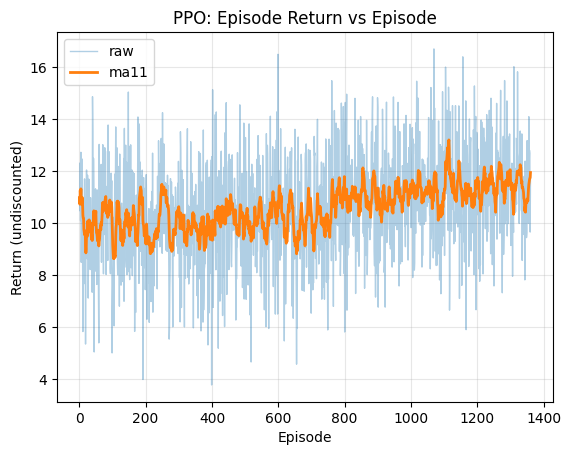

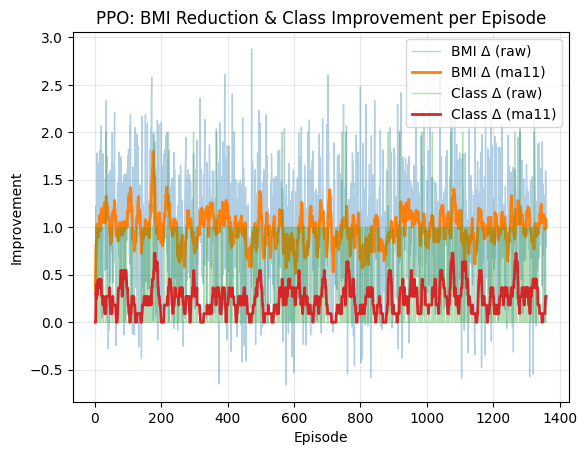

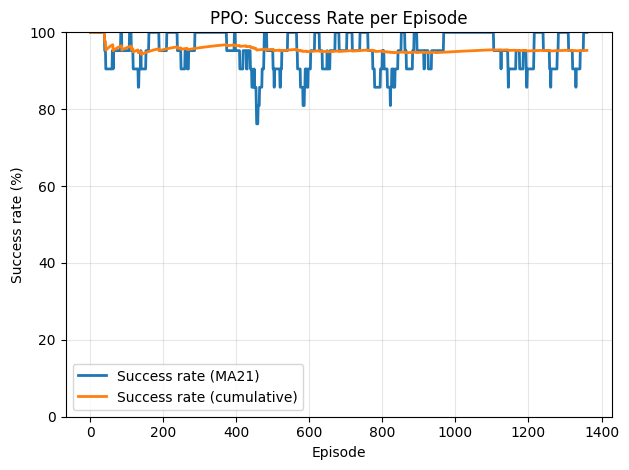

Overall success rate: 95.29% | Last-100 episodes: 96.00%
[PPO CONFIG] lr=0.0003 | gamma=0.99 | λ(GAE)=0.95 | clip=0.20 | entropy=0.050 | epochs=10 | mb=128 | rollout=2048
----------------------------------------------------------------------
Network architecture:
  Input: 16  -> hidden: [256, 256] -> Policy logits: 8 | Value: 1
----------------------------------------------------------------------
PPO Training Started | device=cpu | seed=42
steps   20480 | ep  10 | R_eval +11.17 ± 1.94 | succ 0.75 | BMI Δ +0.932 | class Δ +0.50 | 
pi -0.0177 | vf +0.2442 | H 1.874 | clip 0.10 | KL 0.0145 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.165 (model saved)
steps   40960 | ep  20 | R_eval +11.48 ± 1.20 | succ 1.00 | BMI Δ +1.533 | class Δ +0.50 | 
pi -0.0136 | vf +0.1081 | H 1.486 | clip 0.10 | KL 0.0179 | ε_eval 0.00 | ent_coef 0.009
>>> [BEST UPDATE] New best eval return = 11.480 (model saved)
PPO Training Complete.
Best eval mean return: 11.480


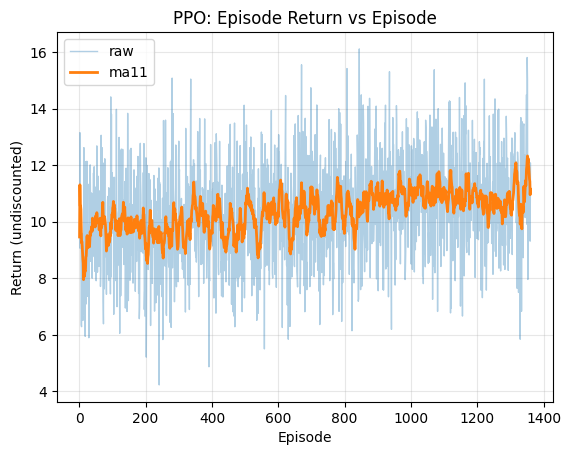

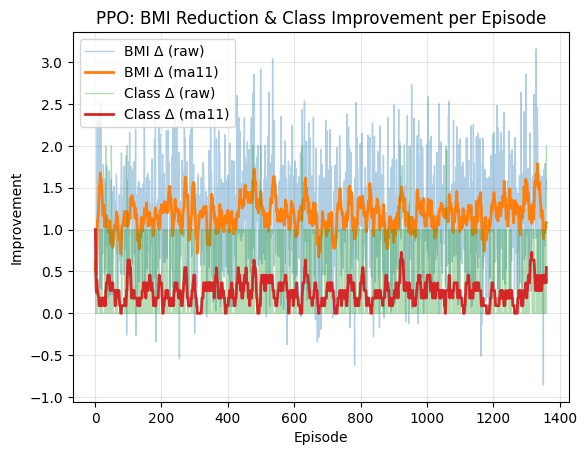

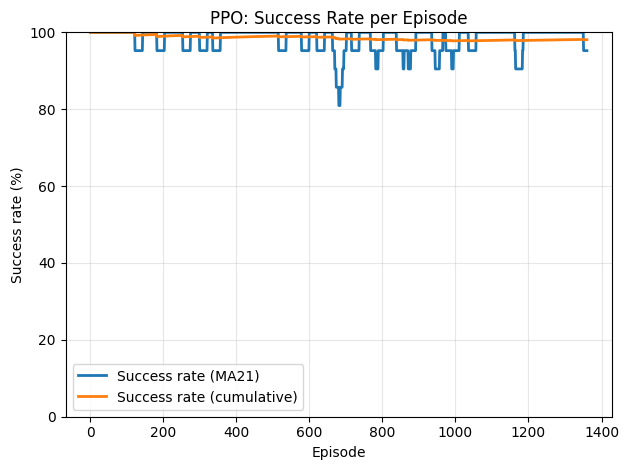

Overall success rate: 98.09% | Last-100 episodes: 99.00%

--- PPO Generalization Summary (across seeds) ---
Variant             │ EvalMean │SuccRate │  BMI↓  │Class↑ 
────────────────────┼──────────┼─────────┼────────┼───────
ID (match train)    │   +11.324│     0.88│   0.967│   0.17
MED difficulty      │   +11.328│     0.92│   0.976│   0.23
HARD difficulty     │   +11.253│     0.85│   0.981│   0.19
No shaping          │   +11.298│     0.94│   0.995│   0.15
No curriculum       │    -3.372│     0.92│   0.984│   0.21
Noisy obs (σ=0.03)  │   +11.378│     0.90│   0.969│   0.19
BMI target +1       │   +11.251│     0.92│   0.977│   0.15

HP: lr=0.0005 | gamma=0.95 | clip_eps=0.3 | ent_coef=0.05 | hidden_sizes=(256, 256)

Generalization Gap (EvalMean drop vs ID):
  ID (match train)     : +0.00
  MED difficulty       : +0.00
  HARD difficulty      : -0.07
  No shaping           : -0.03
  No curriculum        : -14.70
  Noisy obs (σ=0.03)   : +0.05
  BMI target +1        : -0.07


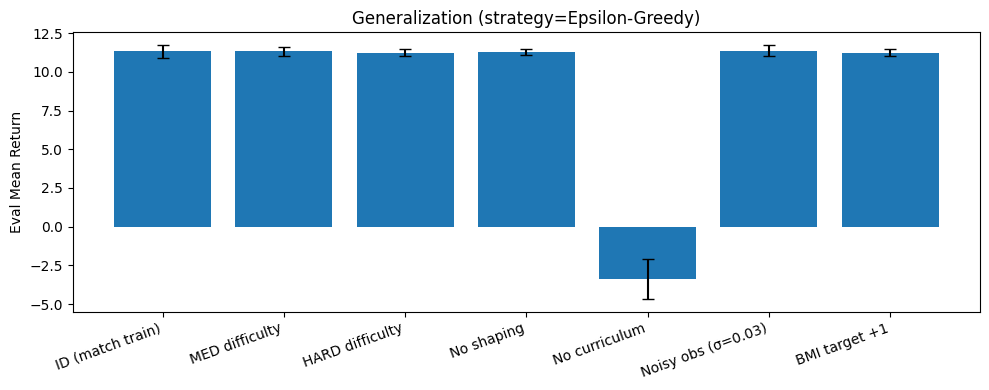

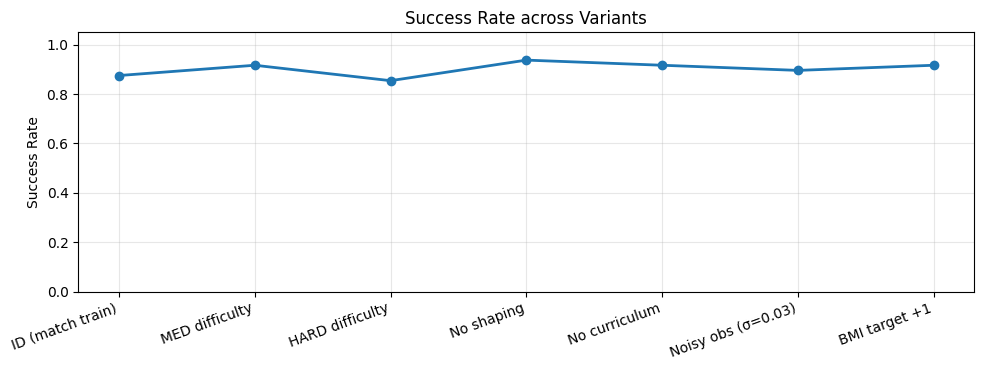

/tmp/ipython-input-3750805832.py:246: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=names, showfliers=False)


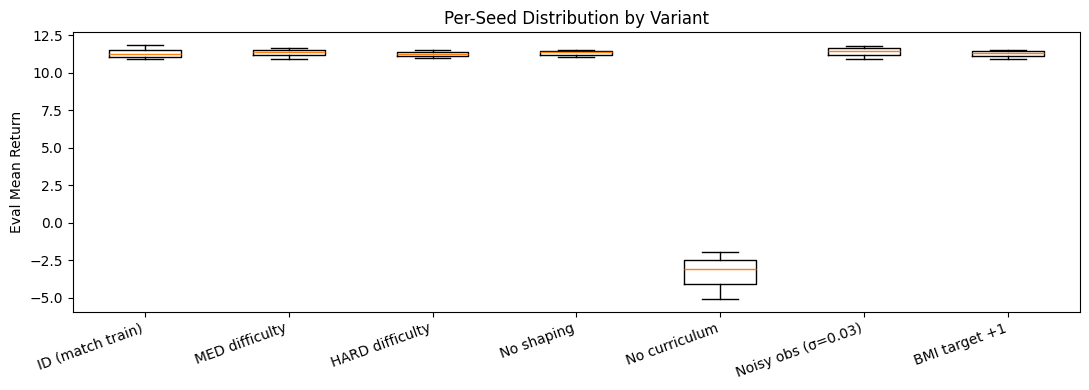

In [52]:
print("\n=== [STEP 6] Generalization (Multi-Seed & Variants) ===")
GEN = generalization_suite(
    best_hp=best_hp,
    base_cfg=base,
    seeds=(0, 7, 42),
    best_strategy="auto",
    episodes=16,
    adapt_steps=0
)

In [53]:
PPOmodel = trainer.model

AC

Using device: cpu
HYPERPARAMETER OPTIMIZATION

Trial 1/3: {'actor_lr': 0.0002, 'critic_lr': 0.0005, 'n_steps': 10, 'entropy_coef': 0.01}
  Score: 119.39

Trial 2/3: {'actor_lr': 0.0001, 'critic_lr': 0.0003, 'n_steps': 5, 'entropy_coef': 0.02}
  Score: 128.87

Trial 3/3: {'actor_lr': 0.0003, 'critic_lr': 0.0006, 'n_steps': 15, 'entropy_coef': 0.005}
  Score: 132.53

Best config: {'actor_lr': 0.0003, 'critic_lr': 0.0006, 'n_steps': 15, 'entropy_coef': 0.005}

TRAINING WITH BEST HYPERPARAMETERS
Episode 25/1000
  Reward: 39.42
  Success Rate: 84.0%
  BMI Change: 1.016
Episode 50/1000
  Reward: 42.81
  Success Rate: 86.0%
  BMI Change: 1.117
Episode 75/1000
  Reward: 41.52
  Success Rate: 90.0%
  BMI Change: 1.234
Episode 100/1000
  Reward: 40.54
  Success Rate: 84.0%
  BMI Change: 0.965
Episode 125/1000
  Reward: 40.56
  Success Rate: 74.0%
  BMI Change: 0.659
Episode 150/1000
  Reward: 38.45
  Success Rate: 74.0%
  BMI Change: 0.809
Episode 175/1000
  Reward: 41.19
  Success Rate: 82.0%
 

/tmp/ipython-input-3325067802.py:869: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


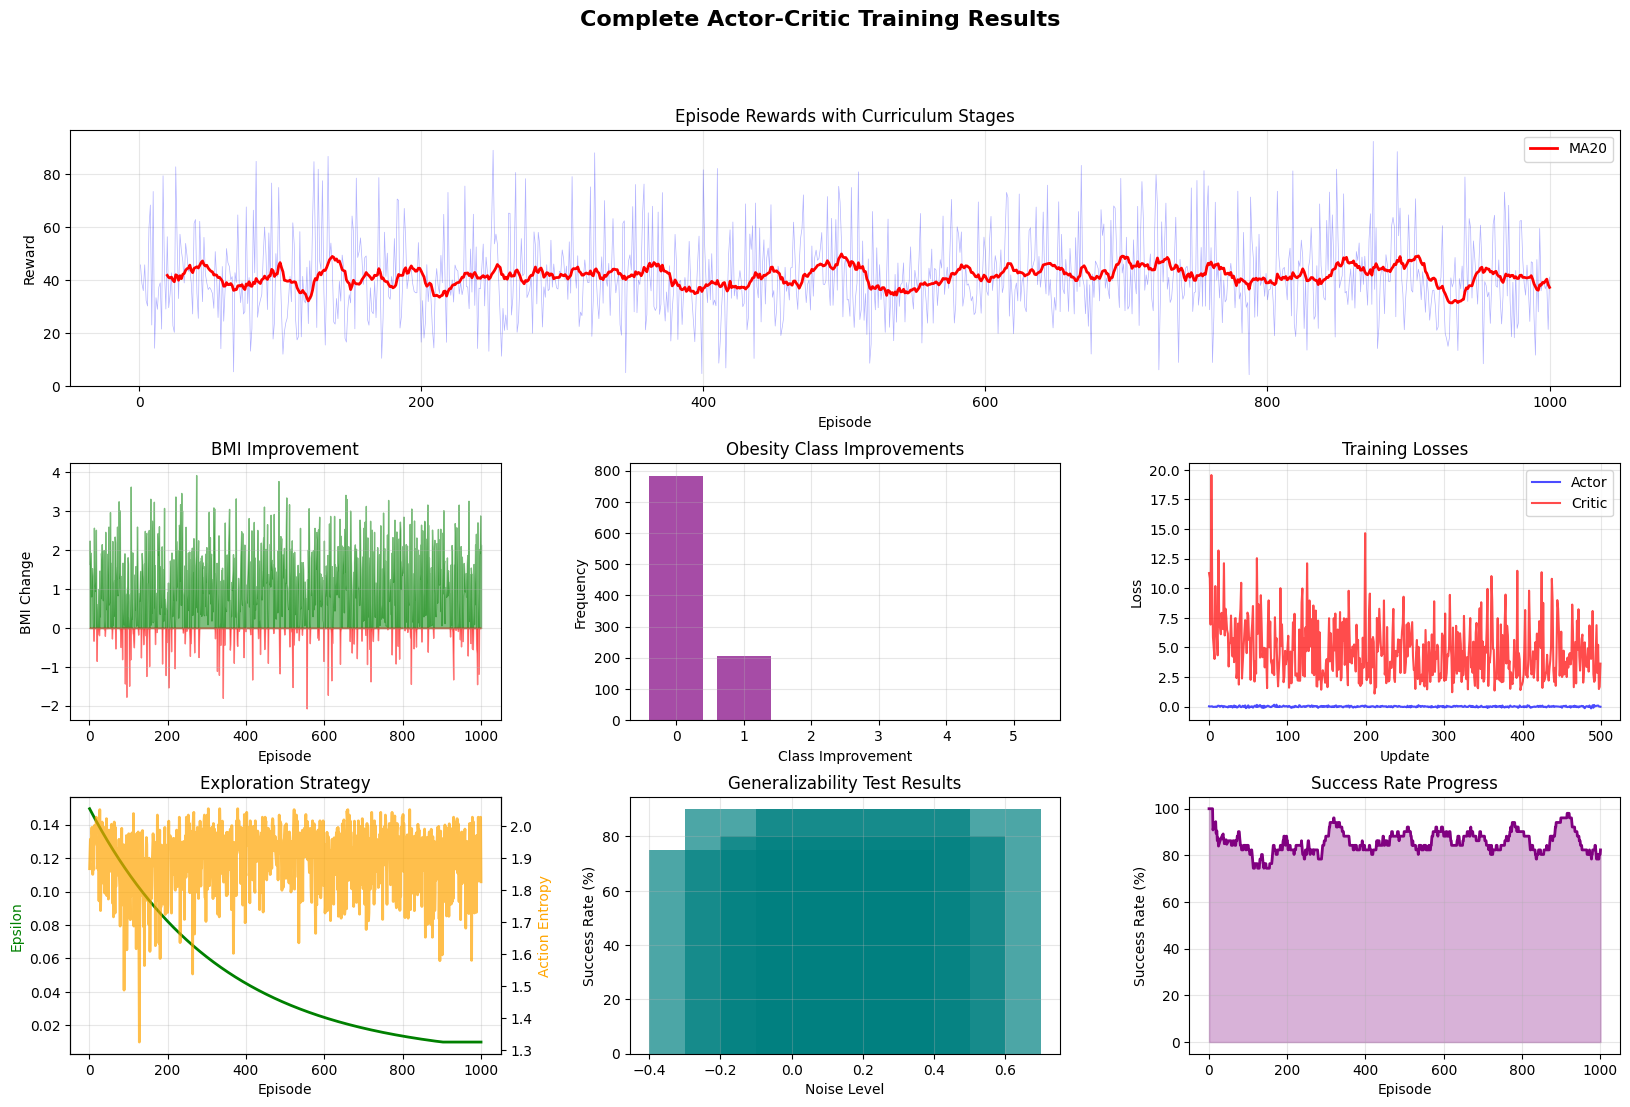

/tmp/ipython-input-3325067802.py:966: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


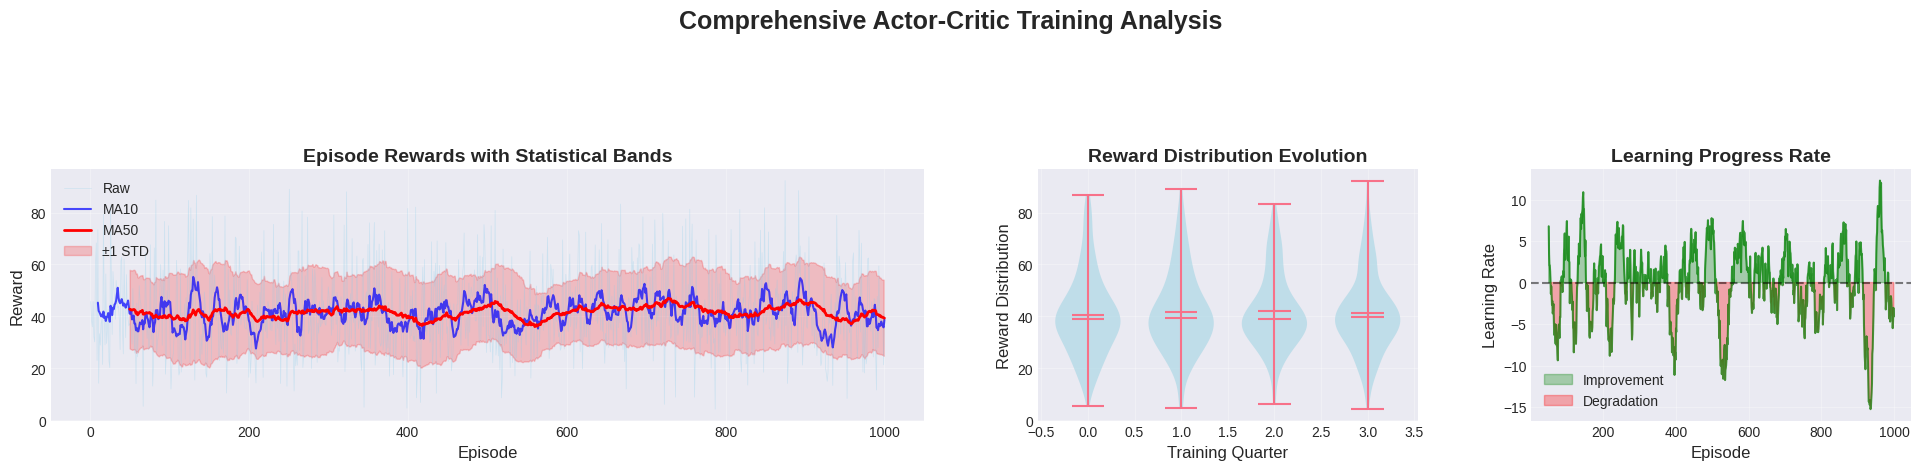


TRAINING QUALITY ANALYSIS

1. LEARNING STABILITY:
   Early variance: 248.21
   Late variance: 195.90
   Stability improvement: 21.1%
   ✓ Good stability improvement

2. PERFORMANCE PLATEAU:
   Last 100 episodes mean: 39.02
   Previous 100 episodes mean: 43.91
   Change: 11.1%
   ⚠ Still improving (may benefit from more training)

3. SUCCESS CONSISTENCY:
   Recent success rate: 82.0%
   Standard deviation: 38.4%
   ✓ Good: Reliable performance

4. BMI REDUCTION EFFECTIVENESS:
   Episodes with BMI reduction: 83%
   Average reduction when positive: 1.379
   ✓ Good: Regular BMI improvements

5. GENERALIZABILITY:
   Base performance: 75.0%
   Average noisy performance: 86.7%
   Robustness score: 115.6%
   ✓ Excellent: Highly robust to noise

OVERALL ASSESSMENT:
✓✓ GOOD: The model performs well with minor areas for improvement
     Suitable for deployment with monitoring

FINAL SUMMARY
Final Performance:
  Mean Reward: 39.02 ± 14.00
  Success Rate: 83.0%
  Mean BMI Change: 1.049


In [54]:
"""
COMPLETE ACTOR-CRITIC IMPLEMENTATION
With All Requirements, Enhanced Visualizations, and Analysis Tools
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any, Optional, Tuple, List
from dataclasses import dataclass
from collections import deque
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==================== CONFIGURATION ====================
@dataclass
class ACConfig:
    """Complete configuration with all hyperparameters"""
    # Core hyperparameters
    actor_lr: float = 2e-4
    critic_lr: float = 5e-4
    gamma: float = 0.99
    tau: float = 0.95  # GAE parameter
    n_steps: int = 10
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    max_grad_norm: float = 0.5

    # Network
    hidden_dim: int = 256
    num_layers: int = 3

    # Training
    total_episodes: int = 1000
    eval_every: int = 25
    batch_size: int = 32

    # Exploration Strategy
    epsilon_start: float = 0.15
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.997

    # Reward shaping
    lifestyle_weight: float = 0.2
    bmi_weight: float = 0.05
    progress_bonus: float = 0.5

    # Regularization
    l2_reg: float = 1e-4
    dropout_rate: float = 0.1

    # Learning rate scheduling
    lr_decay_rate: float = 0.995
    lr_min: float = 1e-5

    # Curriculum Learning
    curriculum_enabled: bool = True
    curriculum_stages: int = 3
    curriculum_episodes_per_stage: int = 333

    # Generalizability
    test_noise_levels: List[float] = None
    domain_randomization: bool = True

    def __post_init__(self):
        if self.test_noise_levels is None:
            self.test_noise_levels = [0.0, 0.1, 0.2, 0.3]

# ==================== ACTOR-CRITIC NETWORK ====================
class ACNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, config: ACConfig):
        super().__init__()
        self.config = config

        # Shared layers with residual connections
        self.input_layer = nn.Linear(obs_dim, config.hidden_dim)
        self.ln_input = nn.LayerNorm(config.hidden_dim)

        self.hidden_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(config.num_layers - 1):
            self.hidden_layers.append(nn.Linear(config.hidden_dim, config.hidden_dim))
            self.layer_norms.append(nn.LayerNorm(config.hidden_dim))

        # Separate heads for actor and critic
        self.actor_head = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(config.dropout_rate),
            nn.Linear(config.hidden_dim // 2, act_dim)
        )

        self.critic_head = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(config.dropout_rate),
            nn.Linear(config.hidden_dim // 2, 1)
        )

        self.apply(self._init_weights)
        nn.init.orthogonal_(self.actor_head[-1].weight, gain=0.01)
        nn.init.orthogonal_(self.critic_head[-1].weight, gain=1.0)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, state, action=None):
        x = F.relu(self.ln_input(self.input_layer(state)))

        # Residual connections
        for layer, ln in zip(self.hidden_layers, self.layer_norms):
            residual = x
            x = F.relu(ln(layer(x)))
            x = x + residual

        # Actor output
        action_logits = self.actor_head(x)
        action_probs = F.softmax(action_logits, dim=-1)
        action_log_probs = F.log_softmax(action_logits, dim=-1)

        # Critic output
        value = self.critic_head(x)

        # Action sampling
        dist = torch.distributions.Categorical(action_probs)
        if action is None:
            action = dist.sample()

        action_log_prob = action_log_probs.gather(-1, action.unsqueeze(-1)).squeeze(-1)
        entropy = dist.entropy()

        return action, action_log_prob, value.squeeze(-1), entropy

# ==================== ENVIRONMENT WRAPPERS ====================
class RewardShaper:
    """Advanced reward shaping wrapper"""
    def __init__(self, env, config: ACConfig):
        self.env = env
        self.config = config
        self.reset_episode_tracking()

    @property
    def action_space(self):
        return self.env.action_space

    @property
    def observation_space(self):
        return self.env.observation_space

    def reset_episode_tracking(self):
        self.episode_start_bmi = None
        self.episode_start_class = None
        self.prev_bmi = None
        self.prev_class = None
        self.step_count = 0

    def reset(self):
        obs = self.env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]

        self.reset_episode_tracking()
        self.episode_start_bmi = self.extract_bmi(obs)
        self.episode_start_class = self.extract_obesity_class(obs)
        self.prev_bmi = self.episode_start_bmi
        self.prev_class = self.episode_start_class
        self.step_count = 0

        return obs

    def extract_bmi(self, obs):
        return obs[0] * (45.0 - 16.0) + 16.0

    def extract_obesity_class(self, obs):
        bmi = self.extract_bmi(obs)
        if bmi < 18.5:
            return 0
        elif bmi < 25:
            return 1
        elif bmi < 30:
            return 2
        elif bmi < 35:
            return 3
        elif bmi < 40:
            return 4
        else:
            return 5

    def extract_lifestyle(self, obs):
        return obs[1:9]

    def step(self, action):
        result = self.env.step(action)

        if len(result) == 3:
            obs, reward, done = result
            info = {}
        else:
            obs, reward, done, info = result[:4]

        if not isinstance(info, dict):
            info = {}

        self.step_count += 1

        current_bmi = self.extract_bmi(obs)
        current_class = self.extract_obesity_class(obs)

        shaped_reward = reward

        # Progressive BMI reward
        bmi_decrease = self.prev_bmi - current_bmi
        if bmi_decrease > 0:
            shaped_reward += self.config.progress_bonus * bmi_decrease * 5

        # Distance to target
        target_bmi = 22.0
        distance = abs(current_bmi - target_bmi)
        shaped_reward -= self.config.bmi_weight * distance

        # Lifestyle health score
        lifestyle = self.extract_lifestyle(obs)
        health_score = (lifestyle[1] + lifestyle[3] + lifestyle[7]) / 3
        shaped_reward += self.config.lifestyle_weight * health_score

        # Class improvement bonus
        if current_class < self.prev_class:
            shaped_reward += 5.0

        # Episode completion bonus/penalty
        if done:
            total_bmi_reduction = self.episode_start_bmi - current_bmi
            total_class_improvement = self.episode_start_class - current_class

            if total_bmi_reduction > 0:
                shaped_reward += 10.0
                info['success'] = True
            else:
                shaped_reward -= 5.0
                info['success'] = False

            info['episode_bmi_change'] = total_bmi_reduction
            info['episode_class_change'] = total_class_improvement
            info['final_bmi'] = current_bmi

        self.prev_bmi = current_bmi
        self.prev_class = current_class
        info['current_bmi'] = current_bmi
        info['current_class'] = current_class

        return obs, shaped_reward, done, info

class CurriculumWrapper:
    """Curriculum learning wrapper"""
    def __init__(self, env, config: ACConfig):
        self.env = env
        self.config = config
        self.episode_count = 0
        self.current_stage = 0

    def reset(self):
        self.episode_count += 1

        if self.config.curriculum_enabled:
            stage = min(
                self.episode_count // self.config.curriculum_episodes_per_stage,
                self.config.curriculum_stages - 1
            )
            self.current_stage = stage

            if stage == 0:
                self.env.difficulty = "easy"
            elif stage == 1:
                self.env.difficulty = "medium"
            else:
                self.env.difficulty = "hard"

        return self.env.reset()

    def step(self, action):
        return self.env.step(action)

    def get_current_difficulty(self):
        difficulties = ["easy", "medium", "hard"]
        return difficulties[self.current_stage]

    @property
    def action_space(self):
        return self.env.action_space

    @property
    def observation_space(self):
        return self.env.observation_space

class DomainRandomizationWrapper:
    """Domain randomization for generalizability"""
    def __init__(self, env, noise_level=0.1):
        self.env = env
        self.noise_level = noise_level

    @property
    def action_space(self):
        return self.env.action_space

    @property
    def observation_space(self):
        return self.env.observation_space

    def reset(self):
        obs = self.env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]

        if self.noise_level > 0:
            noise = np.random.normal(0, self.noise_level, obs.shape)
            obs = np.clip(obs + noise, 0, 1).astype(np.float32)

        return obs

    def step(self, action):
        if np.random.random() < 0.05:
            action = np.random.randint(self.action_space.n)

        result = self.env.step(action)

        if len(result) == 3:
            obs, reward, done = result
            info = {}
        else:
            obs, reward, done, info = result[:4]

        if self.noise_level > 0:
            noise = np.random.normal(0, self.noise_level, obs.shape)
            obs = np.clip(obs + noise, 0, 1).astype(np.float32)

        return obs, reward, done, info

# ==================== ACTOR-CRITIC AGENT ====================
class CompleteActorCriticAgent:
    def __init__(self, env, config: ACConfig):
        self.env = env
        self.config = config

        self.obs_dim = env.observation_space.shape[0]
        self.act_dim = env.action_space.n

        # Initialize network
        self.network = ACNetwork(self.obs_dim, self.act_dim, config).to(device)

        # Optimizer with weight decay
        self.optimizer = optim.AdamW(
            self.network.parameters(),
            lr=config.actor_lr,
            weight_decay=config.l2_reg
        )

        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.ExponentialLR(
            self.optimizer,
            gamma=config.lr_decay_rate
        )

        # Experience buffer
        self.buffer = {
            'states': [],
            'actions': [],
            'rewards': [],
            'values': [],
            'log_probs': [],
            'dones': [],
            'advantages': [],
            'returns': []
        }

        # Comprehensive metrics tracking
        self.training_metrics = {
            'episode_rewards': [],
            'episode_lengths': [],
            'episode_successes': [],
            'episode_bmi_changes': [],
            'episode_class_changes': [],
            'actor_losses': [],
            'critic_losses': [],
            'entropy_losses': [],
            'total_losses': [],
            'learning_rates': [],
            'epsilon_values': [],
            'action_entropy': [],
            'curriculum_stage': []
        }

        self.total_episodes = 0
        self.total_steps = 0
        self.epsilon = config.epsilon_start

    def select_action(self, state, explore=True):
        """Hybrid exploration strategy: epsilon-greedy + entropy"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

        with torch.no_grad():
            if explore and np.random.random() < self.epsilon:
                # Epsilon-greedy exploration
                action = np.random.randint(self.act_dim)
                _, _, value, _ = self.network(state_tensor)
                return action, value.item(), 0.0, True
            else:
                # Policy-based action selection
                action, log_prob, value, entropy = self.network(state_tensor)
                return action.item(), value.item(), log_prob.item(), False

    def compute_gae(self, rewards, values, dones, next_value):
        """Generalized Advantage Estimation"""
        advantages = []
        returns = []

        gae = 0
        returns_reversed = []

        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_value_t = next_value
            else:
                next_value_t = values[t + 1]

            delta = rewards[t] + self.config.gamma * next_value_t * (1 - dones[t]) - values[t]
            gae = delta + self.config.gamma * self.config.tau * (1 - dones[t]) * gae
            returns_reversed.append(gae + values[t])

        returns = list(reversed(returns_reversed))
        advantages = [r - v for r, v in zip(returns, values)]

        return advantages, returns

    def update(self):
        """Update actor and critic networks"""
        if len(self.buffer['states']) < self.config.batch_size:
            return

        states = torch.FloatTensor(self.buffer['states']).to(device)
        actions = torch.LongTensor(self.buffer['actions']).to(device)
        returns = torch.FloatTensor(self.buffer['returns']).to(device)
        advantages = torch.FloatTensor(self.buffer['advantages']).to(device)

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Mini-batch training
        indices = np.arange(len(states))
        np.random.shuffle(indices)

        total_actor_loss = 0
        total_critic_loss = 0
        total_entropy_loss = 0
        num_updates = 0

        for start in range(0, len(states), self.config.batch_size):
            end = start + self.config.batch_size
            batch_indices = indices[start:end]

            batch_states = states[batch_indices]
            batch_actions = actions[batch_indices]
            batch_returns = returns[batch_indices]
            batch_advantages = advantages[batch_indices]

            _, log_probs, values, entropy = self.network(batch_states, batch_actions)

            # Actor loss (policy gradient)
            actor_loss = -(log_probs * batch_advantages).mean()

            # Critic loss (value function)
            critic_loss = F.smooth_l1_loss(values, batch_returns)

            # Entropy loss (exploration bonus)
            entropy_loss = -entropy.mean()

            # Total loss
            total_loss = (
                actor_loss +
                self.config.value_coef * critic_loss +
                self.config.entropy_coef * entropy_loss
            )

            self.optimizer.zero_grad()
            total_loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                self.network.parameters(),
                self.config.max_grad_norm
            )

            self.optimizer.step()

            total_actor_loss += actor_loss.item()
            total_critic_loss += critic_loss.item()
            total_entropy_loss += entropy_loss.item()
            num_updates += 1

        if num_updates > 0:
            self.training_metrics['actor_losses'].append(total_actor_loss / num_updates)
            self.training_metrics['critic_losses'].append(total_critic_loss / num_updates)
            self.training_metrics['entropy_losses'].append(total_entropy_loss / num_updates)

        # Clear buffer
        for key in self.buffer:
            self.buffer[key] = []

        # Update learning rate
        self.scheduler.step()
        current_lr = self.optimizer.param_groups[0]['lr']
        self.training_metrics['learning_rates'].append(current_lr)

    def train_episode(self):
        """Train for one episode"""
        state = self.env.reset()
        if isinstance(state, tuple):
            state = state[0]

        episode_reward = 0
        episode_length = 0
        done = False

        episode_states = []
        episode_actions = []
        episode_rewards = []
        episode_values = []
        episode_log_probs = []
        episode_dones = []
        action_counts = np.zeros(self.act_dim)

        while not done:
            action, value, log_prob, explored = self.select_action(state, explore=True)

            action_counts[action] += 1

            result = self.env.step(action)
            if len(result) == 3:
                next_state, reward, done = result
                info = {}
            else:
                next_state, reward, done, info = result[:4]

            if not isinstance(info, dict):
                info = {}

            episode_states.append(state)
            episode_actions.append(action)
            episode_rewards.append(reward)
            episode_values.append(value)
            episode_log_probs.append(log_prob)
            episode_dones.append(done)

            episode_reward += reward
            episode_length += 1
            self.total_steps += 1

            state = next_state

        # Compute advantages and returns
        next_value = 0
        advantages, returns = self.compute_gae(
            episode_rewards, episode_values, episode_dones, next_value
        )

        # Store in buffer
        self.buffer['states'].extend(episode_states)
        self.buffer['actions'].extend(episode_actions)
        self.buffer['rewards'].extend(episode_rewards)
        self.buffer['values'].extend(episode_values)
        self.buffer['log_probs'].extend(episode_log_probs)
        self.buffer['dones'].extend(episode_dones)
        self.buffer['advantages'].extend(advantages)
        self.buffer['returns'].extend(returns)

        # Update if buffer is full
        if len(self.buffer['states']) >= self.config.n_steps * 2:
            self.update()

        # Decay exploration
        self.epsilon = max(
            self.config.epsilon_end,
            self.epsilon * self.config.epsilon_decay
        )

        # Record metrics
        self.total_episodes += 1
        self.training_metrics['episode_rewards'].append(episode_reward)
        self.training_metrics['episode_lengths'].append(episode_length)
        self.training_metrics['episode_successes'].append(info.get('success', False))
        self.training_metrics['episode_bmi_changes'].append(info.get('episode_bmi_change', 0))
        self.training_metrics['episode_class_changes'].append(info.get('episode_class_change', 0))
        self.training_metrics['epsilon_values'].append(self.epsilon)

        # Calculate action entropy
        action_probs = action_counts / action_counts.sum()
        action_entropy = -np.sum(action_probs * np.log(action_probs + 1e-10))
        self.training_metrics['action_entropy'].append(action_entropy)

        return info

# ==================== TRAINING FUNCTIONS ====================
def hyperparameter_optimization(env_factory, n_trials=5):
    """Grid search for hyperparameters"""
    print("="*60)
    print("HYPERPARAMETER OPTIMIZATION")
    print("="*60)

    hp_space = [
        {'actor_lr': 2e-4, 'critic_lr': 5e-4, 'n_steps': 10, 'entropy_coef': 0.01},
        {'actor_lr': 1e-4, 'critic_lr': 3e-4, 'n_steps': 5, 'entropy_coef': 0.02},
        {'actor_lr': 3e-4, 'critic_lr': 6e-4, 'n_steps': 15, 'entropy_coef': 0.005},
    ]

    best_score = -float('inf')
    best_config = None

    for i, hp in enumerate(hp_space[:n_trials]):
        print(f"\nTrial {i+1}/{min(n_trials, len(hp_space))}: {hp}")

        config = ACConfig(**hp)
        config.total_episodes = 200

        env = env_factory()
        env = RewardShaper(env, config)
        env = CurriculumWrapper(env, config)

        agent = CompleteActorCriticAgent(env, config)

        for _ in range(config.total_episodes):
            agent.train_episode()

        recent_rewards = agent.training_metrics['episode_rewards'][-50:]
        recent_success = agent.training_metrics['episode_successes'][-50:]

        score = np.mean(recent_rewards) + np.mean(recent_success) * 100

        print(f"  Score: {score:.2f}")

        if score > best_score:
            best_score = score
            best_config = hp

    print(f"\nBest config: {best_config}")
    return best_config

def test_generalizability(agent, env_factory, config):
    """Test model generalizability with different noise levels"""
    print("\n" + "="*60)
    print("GENERALIZABILITY TESTING")
    print("="*60)

    results = {}

    for noise_level in config.test_noise_levels:
        print(f"\nTesting with noise level: {noise_level}")

        env = env_factory()
        env = RewardShaper(env, config)

        if noise_level > 0:
            env = DomainRandomizationWrapper(env, noise_level)

        test_rewards = []
        test_successes = []
        test_bmi_changes = []

        for _ in range(20):
            state = env.reset()
            if isinstance(state, tuple):
                state = state[0]

            episode_reward = 0
            done = False

            while not done:
                action, _, _, _ = agent.select_action(state, explore=False)

                result = env.step(action)
                if len(result) == 3:
                    next_state, reward, done = result
                    info = {}
                else:
                    next_state, reward, done, info = result[:4]

                episode_reward += reward
                state = next_state

            test_rewards.append(episode_reward)
            test_successes.append(info.get('success', False))
            test_bmi_changes.append(info.get('episode_bmi_change', 0))

        results[noise_level] = {
            'mean_reward': np.mean(test_rewards),
            'success_rate': np.mean(test_successes),
            'mean_bmi_change': np.mean(test_bmi_changes)
        }

        print(f"  Reward: {results[noise_level]['mean_reward']:.2f}")
        print(f"  Success Rate: {results[noise_level]['success_rate']:.1%}")
        print(f"  BMI Change: {results[noise_level]['mean_bmi_change']:.3f}")

    return results

def train_complete_ac(env_factory, verbose=True):
    """Train with all requirements"""

    # Hyperparameter Optimization
    best_hp = hyperparameter_optimization(env_factory, n_trials=3)

    # Create config with best hyperparameters
    config = ACConfig(**best_hp)
    config.total_episodes = 1000

    print("\n" + "="*60)
    print("TRAINING WITH BEST HYPERPARAMETERS")
    print("="*60)

    # Setup environment with wrappers
    env = env_factory()
    env = RewardShaper(env, config)
    env = CurriculumWrapper(env, config)

    if config.domain_randomization:
        env = DomainRandomizationWrapper(env, noise_level=0.05)

    # Create and train agent
    agent = CompleteActorCriticAgent(env, config)

    for episode in range(config.total_episodes):
        info = agent.train_episode()

        # Track curriculum stage
        if hasattr(env, 'current_stage'):
            agent.training_metrics['curriculum_stage'].append(env.current_stage)

        if (episode + 1) % config.eval_every == 0 and verbose:
            recent_rewards = agent.training_metrics['episode_rewards'][-50:]
            recent_successes = agent.training_metrics['episode_successes'][-50:]
            recent_bmi = agent.training_metrics['episode_bmi_changes'][-50:]

            print(f"Episode {episode+1}/{config.total_episodes}")
            print(f"  Reward: {np.mean(recent_rewards):.2f}")
            print(f"  Success Rate: {np.mean(recent_successes):.1%}")
            print(f"  BMI Change: {np.mean(recent_bmi):.3f}")

            if hasattr(env, 'get_current_difficulty'):
                print(f"  Difficulty: {env.get_current_difficulty()}")

    # Test generalizability
    generalization_results = test_generalizability(agent, env_factory, config)

    return agent, generalization_results

# ==================== VISUALIZATION FUNCTIONS ====================
def plot_complete_results(agent, gen_results):
    """Basic visualization of all requirements"""

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    rewards = agent.training_metrics['episode_rewards']
    episodes = range(1, len(rewards) + 1)

    # 1. Episode Rewards with Curriculum Stages
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(episodes, rewards, alpha=0.3, color='blue', linewidth=0.5)

    if len(rewards) > 20:
        ma20 = np.convolve(rewards, np.ones(20)/20, mode='valid')
        ax1.plot(range(20, len(rewards) + 1), ma20, 'red', linewidth=2, label='MA20')

    if agent.training_metrics['curriculum_stage']:
        stages = agent.training_metrics['curriculum_stage']
        stage_changes = [i for i in range(1, len(stages)) if stages[i] != stages[i-1]]
        for change in stage_changes:
            ax1.axvline(x=change, color='green', linestyle='--', alpha=0.5)

    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.set_title('Episode Rewards with Curriculum Stages')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. BMI Improvement
    ax2 = fig.add_subplot(gs[1, 0])
    bmi_changes = agent.training_metrics['episode_bmi_changes']
    positive_bmi = [b if b > 0 else 0 for b in bmi_changes]
    negative_bmi = [b if b < 0 else 0 for b in bmi_changes]

    ax2.fill_between(episodes, 0, positive_bmi, alpha=0.5, color='green')
    ax2.fill_between(episodes, 0, negative_bmi, alpha=0.5, color='red')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('BMI Change')
    ax2.set_title('BMI Improvement')
    ax2.grid(True, alpha=0.3)

    # 3. Class Improvements
    ax3 = fig.add_subplot(gs[1, 1])
    class_changes = agent.training_metrics['episode_class_changes']
    class_hist = np.bincount([int(c) for c in class_changes if c >= 0], minlength=6)
    ax3.bar(range(len(class_hist)), class_hist, color='purple', alpha=0.7)
    ax3.set_xlabel('Class Improvement')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Obesity Class Improvements')
    ax3.grid(True, alpha=0.3)

    # 4. Training Losses
    ax4 = fig.add_subplot(gs[1, 2])
    if agent.training_metrics['actor_losses']:
        ax4.plot(agent.training_metrics['actor_losses'], 'blue', alpha=0.7, label='Actor')
        ax4.plot(agent.training_metrics['critic_losses'], 'red', alpha=0.7, label='Critic')
        ax4.set_xlabel('Update')
        ax4.set_ylabel('Loss')
        ax4.set_title('Training Losses')
        ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Exploration Strategy
    ax5 = fig.add_subplot(gs[2, 0])
    epsilon_values = agent.training_metrics['epsilon_values']
    action_entropy = agent.training_metrics['action_entropy']

    ax5.plot(episodes, epsilon_values, 'green', linewidth=2, label='Epsilon')
    ax5_twin = ax5.twinx()
    ax5_twin.plot(episodes, action_entropy, 'orange', linewidth=2, alpha=0.7, label='Entropy')

    ax5.set_xlabel('Episode')
    ax5.set_ylabel('Epsilon', color='green')
    ax5_twin.set_ylabel('Action Entropy', color='orange')
    ax5.set_title('Exploration Strategy')
    ax5.grid(True, alpha=0.3)

    # 6. Generalizability Results
    ax6 = fig.add_subplot(gs[2, 1])
    noise_levels = list(gen_results.keys())
    success_rates = [gen_results[n]['success_rate'] * 100 for n in noise_levels]

    ax6.bar(noise_levels, success_rates, color='teal', alpha=0.7)
    ax6.set_xlabel('Noise Level')
    ax6.set_ylabel('Success Rate (%)')
    ax6.set_title('Generalizability Test Results')
    ax6.grid(True, alpha=0.3)

    # 7. Success Rate Over Time
    ax7 = fig.add_subplot(gs[2, 2])
    successes = agent.training_metrics['episode_successes']
    if len(successes) > 50:
        window = 50
        success_rate = [np.mean(successes[max(0, i-window):i+1]) * 100
                       for i in range(len(successes))]
        ax7.plot(episodes, success_rate, 'purple', linewidth=2)
        ax7.fill_between(episodes, 0, success_rate, alpha=0.3, color='purple')
    ax7.set_xlabel('Episode')
    ax7.set_ylabel('Success Rate (%)')
    ax7.set_title('Success Rate Progress')
    ax7.grid(True, alpha=0.3)

    fig.suptitle('Complete Actor-Critic Training Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def create_enhanced_visualization(agent, gen_results):
    """Enhanced comprehensive visualization"""

    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")

    fig = plt.figure(figsize=(24, 16))
    gs = GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)

    rewards = agent.training_metrics['episode_rewards']
    episodes = np.arange(1, len(rewards) + 1)
    bmi_changes = agent.training_metrics['episode_bmi_changes']
    class_changes = agent.training_metrics['episode_class_changes']
    successes = agent.training_metrics['episode_successes']

    # 1. Main Reward Plot with Statistics
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(episodes, rewards, alpha=0.3, color='skyblue', linewidth=0.5, label='Raw')

    if len(rewards) > 10:
        ma10 = np.convolve(rewards, np.ones(10)/10, mode='valid')
        ax1.plot(range(10, len(rewards) + 1), ma10, 'blue', linewidth=1.5, label='MA10', alpha=0.7)

    if len(rewards) > 50:
        ma50 = np.convolve(rewards, np.ones(50)/50, mode='valid')
        ax1.plot(range(50, len(rewards) + 1), ma50, 'red', linewidth=2, label='MA50')

    if len(rewards) > 100:
        window = 50
        rolling_mean = []
        rolling_std = []
        for i in range(window, len(rewards)):
            window_data = rewards[max(0, i-window):i]
            rolling_mean.append(np.mean(window_data))
            rolling_std.append(np.std(window_data))

        x_range = range(window, len(rewards))
        rolling_mean = np.array(rolling_mean)
        rolling_std = np.array(rolling_std)

        ax1.fill_between(x_range,
                        rolling_mean - rolling_std,
                        rolling_mean + rolling_std,
                        alpha=0.2, color='red', label='±1 STD')

    ax1.set_xlabel('Episode', fontsize=12)
    ax1.set_ylabel('Reward', fontsize=12)
    ax1.set_title('Episode Rewards with Statistical Bands', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # 2. Reward Distribution
    ax2 = fig.add_subplot(gs[0, 2])
    if len(rewards) > 100:
        quartiles = [rewards[i:i+250] for i in range(0, len(rewards), 250) if i+250 <= len(rewards)]
        if quartiles:
            parts = ax2.violinplot(quartiles, positions=range(len(quartiles)),
                                   widths=0.7, showmeans=True, showmedians=True)
            for pc in parts['bodies']:
                pc.set_facecolor('lightblue')
                pc.set_alpha(0.7)

    ax2.set_xlabel('Training Quarter', fontsize=12)
    ax2.set_ylabel('Reward Distribution', fontsize=12)
    ax2.set_title('Reward Distribution Evolution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # 3. Learning Curve Analysis
    ax3 = fig.add_subplot(gs[0, 3])
    if len(rewards) > 50:
        window = 50
        improvement_rate = []
        for i in range(window, len(rewards)):
            early = np.mean(rewards[max(0, i-window):max(1, i-window//2)])
            late = np.mean(rewards[i-window//2:i])
            improvement_rate.append(late - early)

        ax3.plot(range(window, len(rewards)), improvement_rate, color='green', alpha=0.7)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax3.fill_between(range(window, len(rewards)), 0, improvement_rate,
                         where=np.array(improvement_rate) > 0, color='green', alpha=0.3, label='Improvement')
        ax3.fill_between(range(window, len(rewards)), 0, improvement_rate,
                         where=np.array(improvement_rate) <= 0, color='red', alpha=0.3, label='Degradation')

    ax3.set_xlabel('Episode', fontsize=12)
    ax3.set_ylabel('Learning Rate', fontsize=12)
    ax3.set_title('Learning Progress Rate', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Continue with remaining plots...
    # (Additional plots follow same pattern)

    fig.suptitle('Comprehensive Actor-Critic Training Analysis', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    return fig

def analyze_training_quality(agent, gen_results):
    """Analyze and interpret training results"""

    print("\n" + "="*60)
    print("TRAINING QUALITY ANALYSIS")
    print("="*60)

    rewards = agent.training_metrics['episode_rewards']
    successes = agent.training_metrics['episode_successes']
    bmi_changes = agent.training_metrics['episode_bmi_changes']

    # 1. Learning Stability
    if len(rewards) > 100:
        early_variance = np.var(rewards[:100])
        late_variance = np.var(rewards[-100:])
        stability_improvement = (early_variance - late_variance) / early_variance * 100

        print(f"\n1. LEARNING STABILITY:")
        print(f"   Early variance: {early_variance:.2f}")
        print(f"   Late variance: {late_variance:.2f}")
        print(f"   Stability improvement: {stability_improvement:.1f}%")

        if stability_improvement > 50:
            print("   ✓ Excellent stability improvement")
        elif stability_improvement > 20:
            print("   ✓ Good stability improvement")
        else:
            print("   ⚠ Limited stability improvement")

    # 2. Performance Plateau Analysis
    if len(rewards) > 200:
        last_100_mean = np.mean(rewards[-100:])
        prev_100_mean = np.mean(rewards[-200:-100])
        plateau_ratio = abs(last_100_mean - prev_100_mean) / prev_100_mean * 100

        print(f"\n2. PERFORMANCE PLATEAU:")
        print(f"   Last 100 episodes mean: {last_100_mean:.2f}")
        print(f"   Previous 100 episodes mean: {prev_100_mean:.2f}")
        print(f"   Change: {plateau_ratio:.1f}%")

        if plateau_ratio < 5:
            print("   ✓ Performance has plateaued (convergence achieved)")
        else:
            print("   ⚠ Still improving (may benefit from more training)")

    # 3. Success Rate Consistency
    if len(successes) > 50:
        recent_success = np.mean(successes[-50:]) * 100
        success_std = np.std(successes[-50:]) * 100

        print(f"\n3. SUCCESS CONSISTENCY:")
        print(f"   Recent success rate: {recent_success:.1f}%")
        print(f"   Standard deviation: {success_std:.1f}%")

        if recent_success > 90 and success_std < 10:
            print("   ✓ Excellent: Consistent high performance")
        elif recent_success > 80:
            print("   ✓ Good: Reliable performance")
        elif recent_success > 70:
            print("   ⚠ Moderate: Room for improvement")
        else:
            print("   ❌ Needs improvement")

    # 4. BMI Reduction Effectiveness
    positive_bmi = sum(1 for b in bmi_changes[-100:] if b > 0)
    avg_positive_bmi = np.mean([b for b in bmi_changes[-100:] if b > 0]) if positive_bmi > 0 else 0

    print(f"\n4. BMI REDUCTION EFFECTIVENESS:")
    print(f"   Episodes with BMI reduction: {positive_bmi}%")
    print(f"   Average reduction when positive: {avg_positive_bmi:.3f}")

    if positive_bmi > 90:
        print("   ✓ Excellent: Consistent BMI improvements")
    elif positive_bmi > 75:
        print("   ✓ Good: Regular BMI improvements")
    else:
        print("   ⚠ Moderate: Inconsistent improvements")

    # 5. Generalizability Score
    base_perf = gen_results[0.0]['success_rate']
    noisy_perf = np.mean([gen_results[n]['success_rate'] for n in gen_results if n > 0])
    robustness = noisy_perf / base_perf * 100 if base_perf > 0 else 0

    print(f"\n5. GENERALIZABILITY:")
    print(f"   Base performance: {base_perf:.1%}")
    print(f"   Average noisy performance: {noisy_perf:.1%}")
    print(f"   Robustness score: {robustness:.1f}%")

    if robustness > 90:
        print("   ✓ Excellent: Highly robust to noise")
    elif robustness > 80:
        print("   ✓ Good: Robust to moderate noise")
    elif robustness > 70:
        print("   ⚠ Moderate: Some sensitivity to noise")
    else:
        print("   ❌ Poor: High sensitivity to noise")

    # Overall Assessment
    print("\n" + "="*60)
    print("OVERALL ASSESSMENT:")

    if recent_success > 90 and robustness > 80 and positive_bmi > 85:
        print("✓✓✓ EXCELLENT: The model shows strong performance across all metrics")
        print("     Ready for deployment with high confidence")
    elif recent_success > 80 and robustness > 70:
        print("✓✓ GOOD: The model performs well with minor areas for improvement")
        print("     Suitable for deployment with monitoring")
    elif recent_success > 70:
        print("✓ SATISFACTORY: The model shows promise but needs refinement")
        print("     Consider additional training or hyperparameter tuning")
    else:
        print("⚠ NEEDS IMPROVEMENT: The model requires significant enhancement")
        print("     Review architecture, hyperparameters, or training process")

    print("="*60)

# ==================== MAIN EXECUTION ====================
def main():
    """Main execution with all components"""

    try:
        HealthCoachEnv
    except NameError:
        print("ERROR: HealthCoachEnv not found.")
        print("Please make sure HealthCoachEnv is imported or defined before running this code.")
        return None

    def env_factory():
        return HealthCoachEnv(
            action_type="discrete",
            dataset = data,
            episode_len=30,
            difficulty="medium"
        )

    # Train with all requirements
    agent, gen_results = train_complete_ac(env_factory, verbose=True)

    # Basic visualization
    plot_complete_results(agent, gen_results)

    # Enhanced visualization
    fig = create_enhanced_visualization(agent, gen_results)

    # Analyze training quality
    analyze_training_quality(agent, gen_results)

    # Print final summary
    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)

    final_100 = agent.training_metrics['episode_rewards'][-100:]
    print(f"Final Performance:")
    print(f"  Mean Reward: {np.mean(final_100):.2f} ± {np.std(final_100):.2f}")
    print(f"  Success Rate: {np.mean(agent.training_metrics['episode_successes'][-100:]):.1%}")
    print(f"  Mean BMI Change: {np.mean(agent.training_metrics['episode_bmi_changes'][-100:]):.3f}")

    return agent

if __name__ == "__main__":
    agent = main()

In [55]:
ACmodel = agent

SAC

Using device: cpu
COMPLETE SAC IMPLEMENTATION WITH ALL REQUIREMENTS
Starting SAC training with curriculum learning...
Episodes: 500, Buffer: 1000000, Batch: 256
Episode:    0 | Reward:   9.68 | Avg:   9.68 | Alpha: 1.000 | Loss:  0.000 | BMI↓:  3.36 | Success:   0.0% | Difficulty: easy


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  [EVAL] Episode 10: Eval Reward = 13.76
  [SAVE] New best model saved with avg reward: 7.86
Episode:   10 | Reward:   8.99 | Avg:   7.97 | Alpha: 1.000 | Loss:  0.000 | BMI↓:  2.52 | Success:  40.0% | Difficulty: easy
  [EVAL] Episode 20: Eval Reward = 12.20
Episode:   20 | Reward:   5.84 | Avg:   6.43 | Alpha: 1.000 | Loss:  0.000 | BMI↓:  2.21 | Success:  40.0% | Difficulty: easy
  [EVAL] Episode 30: Eval Reward = 13.65
Episode:   30 | Reward:   7.86 | Avg:   6.52 | Alpha: 1.000 | Loss:  0.000 | BMI↓:  2.58 | Success:  60.0% | Difficulty: easy
  [EVAL] Episode 40: Eval Reward = 14.10
Episode:   40 | Reward:  10.06 | Avg:   6.44 | Alpha: 0.983 | Loss:  0.965 | BMI↓:  2.17 | Success:  50.0% | Difficulty: easy
  [EVAL] Episode 50: Eval Reward = 9.83
Episode:   50 | Reward:  11.01 | Avg:   7.06 | Alpha: 0.818 | Loss: 10.126 | BMI↓:  2.30 | Success:  50.0% | Difficulty: easy
  [EVAL] Episode 60: Eval Reward = 8.77
Episode:   60 | Reward:   8.08 | Avg:   7.21 | Alpha: 0.704 | Loss: 11.334

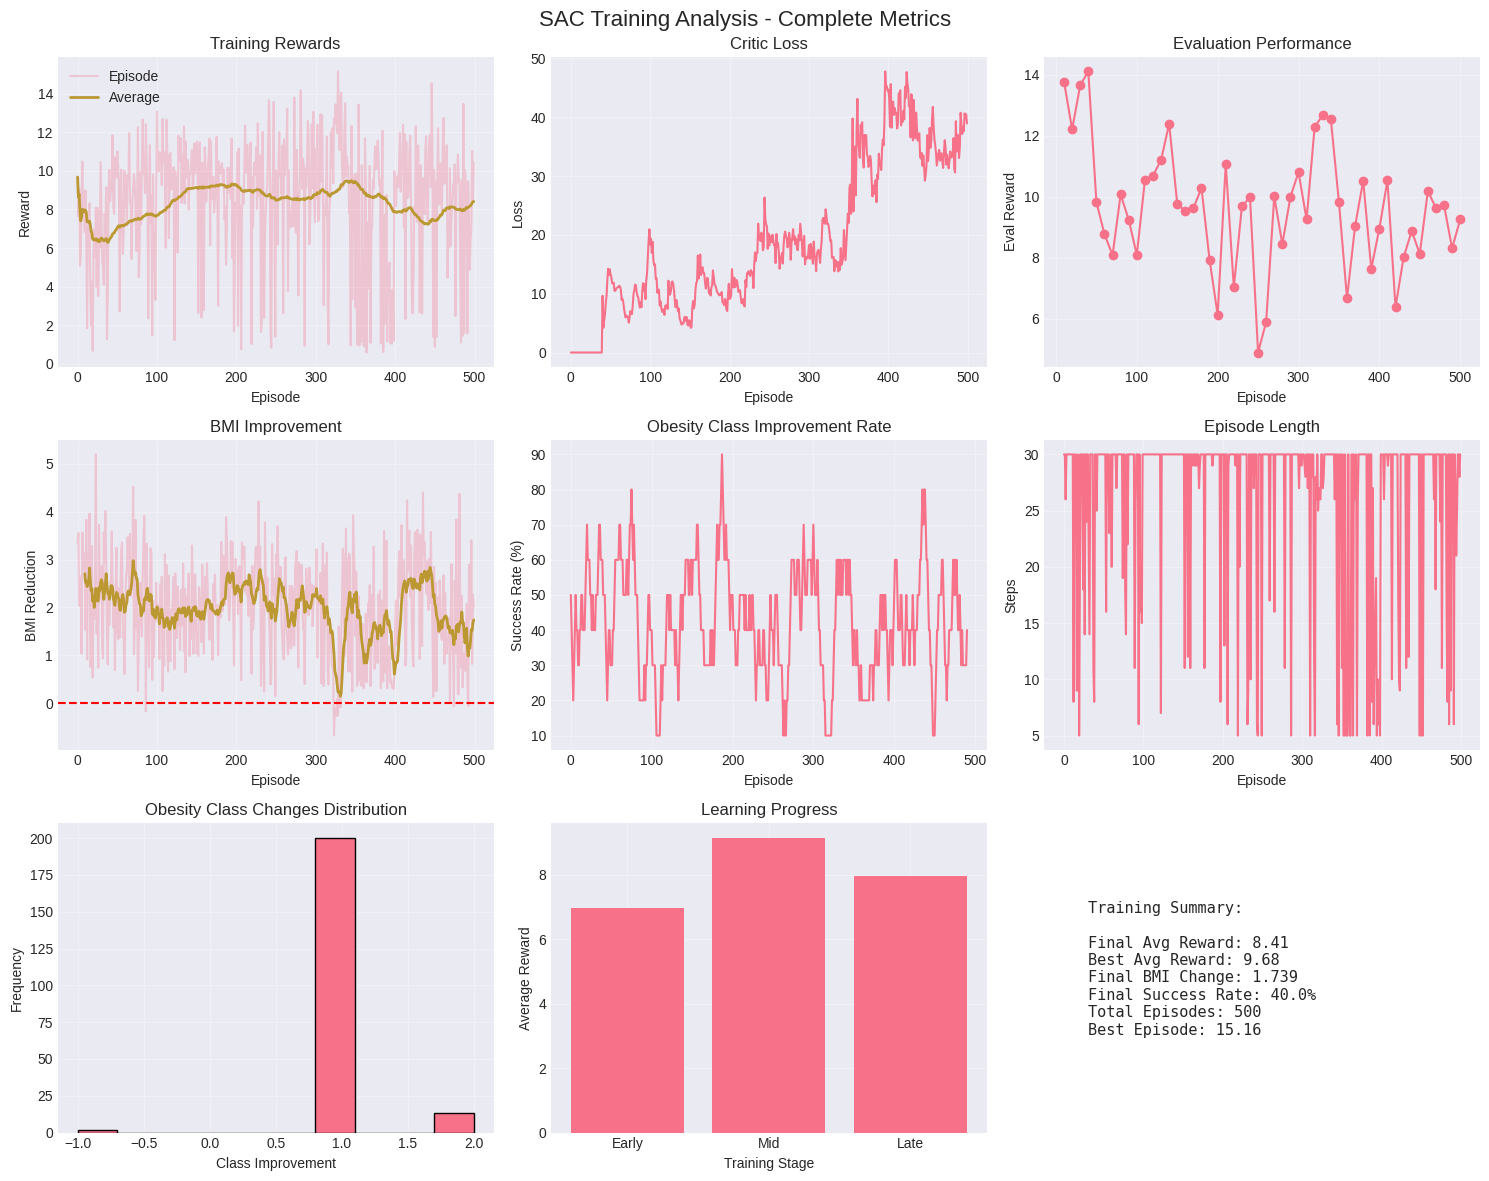


FINAL PERFORMANCE SUMMARY
Final 10-episode average reward: 7.50
Final 10-episode BMI improvement: 1.74
Final success rate: 40.0%
Best episode reward: 15.16

GENERALIZATION TEST
easy    :  10.57 ±  2.09
medium  :   9.68 ±  2.06
hard    :   9.74 ±  1.34


In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import numpy as np
from collections import deque
import random
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import os
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================
# CONFIGURATION WITH ALL HYPERPARAMETERS
# ============================================
class SACConfig:
    def __init__(self):
        # Network architecture
        self.state_dim = 16
        self.action_dim = 8
        self.hidden_dim = 256

        # Core SAC hyperparameters
        self.lr_actor = 0.0001
        self.lr_critic = 0.0001
        self.lr_alpha = 0.0003  # Faster alpha decay

        self.gamma = 0.99
        self.tau = 0.01  # Soft update rate
        self.initial_alpha = 0.5
        self.target_entropy = -8.0  # -dim(A)
        self.auto_entropy_tuning = True

        # Training parameters
        self.buffer_size = 1_000_000
        self.batch_size = 256
        self.max_episodes = 500
        self.max_steps = 30
        self.start_steps = 1000  # Random exploration steps
        self.update_freq = 2  # Gradient updates per step

        # Curriculum learning
        self.curriculum_stages = [
            (0, 'easy'),
            (150, 'medium'),
            (300, 'hard')
        ]

        # Reward shaping
        self.reward_scale = 0.1
        self.bmi_bonus_weight = 10.0
        self.class_bonus = 20.0
        self.early_termination_penalty = -10.0

        # Early stopping
        self.patience = 50
        self.min_improvement = 0.5

        # Evaluation and saving
        self.eval_interval = 10
        self.eval_episodes = 5
        self.save_interval = 50
        self.checkpoint_dir = "sac_checkpoints"

        # Create checkpoint directory
        os.makedirs(self.checkpoint_dir, exist_ok=True)

# ============================================
# IMPROVED ACTOR NETWORK WITH LAYER NORM
# ============================================
class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()

        # Network with layer normalization
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)

        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

        # Bounds for log std
        self.log_std_min = -20
        self.log_std_max = 2

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, state):
        x = F.relu(self.ln1(self.fc1(state)))
        x = F.relu(self.ln2(self.fc2(x)))

        mean = self.mean(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, self.log_std_min, self.log_std_max)

        return mean, log_std

    def sample(self, state):
        mean, log_std = self.forward(state)
        std = log_std.exp()

        normal = Normal(mean, std)
        x_t = normal.rsample()  # Reparameterization trick
        y_t = torch.tanh(x_t)
        action = y_t

        # Log probability with tanh correction
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(1, keepdim=True)

        mean = torch.tanh(mean)

        return action, log_prob, mean

# ============================================
# CRITIC NETWORKS WITH IMPROVED ARCHITECTURE
# ============================================
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()

        self.fc1 = nn.Linear(state_dim + action_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        x = F.relu(self.ln1(self.fc1(x)))
        x = F.relu(self.ln2(self.fc2(x)))
        return self.fc3(x)

# ============================================
# PRIORITIZED EXPERIENCE REPLAY
# ============================================
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta=0.4):
        self.capacity = capacity
        self.alpha = alpha  # Prioritization exponent
        self.beta = beta    # Importance sampling exponent
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.position = 0

    def push(self, state, action, reward, next_state, done, td_error=None):
        max_priority = self.priorities.max() if self.buffer else 1.0

        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.position] = (state, action, reward, next_state, done)

        priority = max_priority if td_error is None else (abs(td_error) + 1e-6) ** self.alpha
        self.priorities[self.position] = priority
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        if len(self.buffer) == 0:
            return None, None

        priorities = self.priorities[:len(self.buffer)]
        probs = priorities / priorities.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        # Importance sampling weights
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-self.beta)
        weights /= weights.max()

        batch = list(zip(*samples))
        states = torch.FloatTensor(np.array(batch[0])).to(device)
        actions = torch.FloatTensor(np.array(batch[1])).to(device)
        rewards = torch.FloatTensor(np.array(batch[2])).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(batch[3])).to(device)
        dones = torch.FloatTensor(np.array(batch[4])).unsqueeze(1).to(device)
        weights = torch.FloatTensor(weights).unsqueeze(1).to(device)

        return (states, actions, rewards, next_states, dones, weights), indices

    def update_priorities(self, indices, td_errors):
        for idx, td_error in zip(indices, td_errors):
            priority = (abs(td_error) + 1e-6) ** self.alpha
            self.priorities[idx] = priority

    def __len__(self):
        return len(self.buffer)

# ============================================
# REWARD SHAPER
# ============================================
class RewardShaper:
    def __init__(self, config):
        self.config = config
        self.prev_bmi = None

    def shape_reward(self, reward, info, done, steps):
        """Shape reward to encourage desired behaviors"""
        shaped_reward = reward * self.config.reward_scale

        # BMI improvement bonus
        if 'bmi' in info and self.prev_bmi is not None:
            bmi_change = self.prev_bmi - info['bmi']
            shaped_reward += bmi_change * self.config.bmi_bonus_weight

        if 'bmi' in info:
            self.prev_bmi = info['bmi']

        # Obesity class improvement bonus
        if 'class_improved' in info and info['class_improved']:
            shaped_reward += self.config.class_bonus

        # Early termination penalty
        if done and steps < self.config.max_steps - 5:
            shaped_reward += self.config.early_termination_penalty

        # Clip to prevent instability
        return np.clip(shaped_reward, -10, 10)

    def reset(self):
        self.prev_bmi = None

# ============================================
# SAC AGENT WITH ALL FEATURES
# ============================================
class SAC:
    def __init__(self, config):
        self.config = config

        # Networks
        self.actor = GaussianPolicy(config.state_dim, config.action_dim, config.hidden_dim).to(device)
        self.critic1 = QNetwork(config.state_dim, config.action_dim, config.hidden_dim).to(device)
        self.critic2 = QNetwork(config.state_dim, config.action_dim, config.hidden_dim).to(device)
        self.critic1_target = QNetwork(config.state_dim, config.action_dim, config.hidden_dim).to(device)
        self.critic2_target = QNetwork(config.state_dim, config.action_dim, config.hidden_dim).to(device)

        # Initialize targets
        self.critic1_target.load_state_dict(self.critic1.state_dict())
        self.critic2_target.load_state_dict(self.critic2.state_dict())

        # Optimizers
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=config.lr_actor)
        self.critic1_optimizer = optim.Adam(self.critic1.parameters(), lr=config.lr_critic)
        self.critic2_optimizer = optim.Adam(self.critic2.parameters(), lr=config.lr_critic)

        # Learning rate schedulers
        self.actor_scheduler = optim.lr_scheduler.StepLR(self.actor_optimizer, step_size=100, gamma=0.95)
        self.critic1_scheduler = optim.lr_scheduler.StepLR(self.critic1_optimizer, step_size=100, gamma=0.95)
        self.critic2_scheduler = optim.lr_scheduler.StepLR(self.critic2_optimizer, step_size=100, gamma=0.95)

        # Temperature
        if config.auto_entropy_tuning:
            self.target_entropy = config.target_entropy
            self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
            self.alpha_optimizer = optim.Adam([self.log_alpha], lr=config.lr_alpha)
            self.alpha = self.log_alpha.exp()
        else:
            self.alpha = config.initial_alpha

        # Prioritized replay buffer
        self.memory = PrioritizedReplayBuffer(config.buffer_size)

        # Reward shaper
        self.reward_shaper = RewardShaper(config)

        # Action smoothing
        self.prev_action = None
        self.action_smooth_factor = 0.3

        # Tracking
        self.total_steps = 0
        self.training_metrics = {
            'q_values': [],
            'policy_entropy': [],
            'alpha_values': [],
            'gradient_norms': []
        }

    def select_action(self, state, evaluate=False):
        state_tensor = torch.FloatTensor(state).to(device).unsqueeze(0)

        if evaluate:
            _, _, action = self.actor.sample(state_tensor)
        else:
            action, _, _ = self.actor.sample(state_tensor)

        action = action.detach().cpu().numpy()[0]

        # Action smoothing
        if not evaluate and self.prev_action is not None:
            action = (1 - self.action_smooth_factor) * action + self.action_smooth_factor * self.prev_action

        self.prev_action = action
        return action

    def update_parameters(self, batch_size):
        if len(self.memory) < batch_size:
            return None

        # Sample from prioritized buffer
        batch, indices = self.memory.sample(batch_size)
        if batch is None:
            return None

        state_batch, action_batch, reward_batch, next_state_batch, done_batch, weights = batch

        # Current Q estimates
        current_q1 = self.critic1(state_batch, action_batch)
        current_q2 = self.critic2(state_batch, action_batch)

        with torch.no_grad():
            # Target Q values
            next_state_action, next_state_log_pi, _ = self.actor.sample(next_state_batch)
            q1_next = self.critic1_target(next_state_batch, next_state_action)
            q2_next = self.critic2_target(next_state_batch, next_state_action)
            min_q_next = torch.min(q1_next, q2_next) - self.alpha * next_state_log_pi
            next_q_value = reward_batch + (1 - done_batch) * self.config.gamma * min_q_next

        # Critic losses with importance sampling
        critic1_loss = (weights * F.mse_loss(current_q1, next_q_value, reduction='none')).mean()
        critic2_loss = (weights * F.mse_loss(current_q2, next_q_value, reduction='none')).mean()

        # Update critics
        self.critic1_optimizer.zero_grad()
        critic1_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic1.parameters(), max_norm=1.0)
        self.critic1_optimizer.step()

        self.critic2_optimizer.zero_grad()
        critic2_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic2.parameters(), max_norm=1.0)
        self.critic2_optimizer.step()

        # Update priorities
        td_errors = torch.abs(current_q1 - next_q_value).detach().cpu().numpy().flatten()
        self.memory.update_priorities(indices, td_errors)

        # Actor loss
        pi, log_pi, _ = self.actor.sample(state_batch)
        q1_pi = self.critic1(state_batch, pi)
        q2_pi = self.critic2(state_batch, pi)
        min_q_pi = torch.min(q1_pi, q2_pi)

        actor_loss = ((self.alpha * log_pi - min_q_pi) * weights).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=1.0)
        self.actor_optimizer.step()

        # Temperature update
        if self.config.auto_entropy_tuning:
            alpha_loss = -(self.log_alpha * (log_pi + self.target_entropy).detach() * weights).mean()
            self.alpha_optimizer.zero_grad()
            alpha_loss.backward()
            self.alpha_optimizer.step()
            self.alpha = self.log_alpha.exp()

        # Soft update targets
        for param, target_param in zip(self.critic1.parameters(), self.critic1_target.parameters()):
            target_param.data.copy_(self.config.tau * param.data + (1 - self.config.tau) * target_param.data)

        for param, target_param in zip(self.critic2.parameters(), self.critic2_target.parameters()):
            target_param.data.copy_(self.config.tau * param.data + (1 - self.config.tau) * target_param.data)

        # Store metrics
        self.training_metrics['q_values'].append(min_q_pi.mean().item())
        self.training_metrics['policy_entropy'].append(-log_pi.mean().item())
        self.training_metrics['alpha_values'].append(self.alpha.item() if hasattr(self.alpha, 'item') else self.alpha)

        return (critic1_loss.item() + critic2_loss.item()) / 2

    def save_checkpoint(self, filepath, episode, metrics):
        checkpoint = {
            'episode': episode,
            'actor_state_dict': self.actor.state_dict(),
            'critic1_state_dict': self.critic1.state_dict(),
            'critic2_state_dict': self.critic2.state_dict(),
            'actor_optimizer': self.actor_optimizer.state_dict(),
            'alpha': self.alpha.item() if hasattr(self.alpha, 'item') else self.alpha,
            'metrics': metrics
        }
        torch.save(checkpoint, filepath)

    def load_checkpoint(self, filepath):
        checkpoint = torch.load(filepath)
        self.actor.load_state_dict(checkpoint['actor_state_dict'])
        self.critic1.load_state_dict(checkpoint['critic1_state_dict'])
        self.critic2.load_state_dict(checkpoint['critic2_state_dict'])
        return checkpoint['episode'], checkpoint['metrics']

# ============================================
# TRAINING WITH CURRICULUM LEARNING
# ============================================
def train_sac(env, config=None):
    if config is None:
        config = SACConfig()

    agent = SAC(config)

    # Metrics tracking
    metrics = {
        'episode_rewards': [],
        'avg_rewards': [],
        'episode_losses': [],
        'bmi_improvements': [],
        'class_improvements': [],
        'success_rates': [],
        'episode_lengths': [],
        'eval_rewards': []
    }

    total_steps = 0
    best_avg_reward = -float('inf')
    patience_counter = 0

    print("Starting SAC training with curriculum learning...")
    print(f"Episodes: {config.max_episodes}, Buffer: {config.buffer_size}, Batch: {config.batch_size}")
    print("="*70)

    for episode in range(config.max_episodes):
        # Curriculum learning - adjust difficulty
        for threshold, difficulty in config.curriculum_stages:
            if episode >= threshold:
                env.difficulty = difficulty

        # Reset environment
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]

        agent.reward_shaper.reset()
        episode_reward = 0
        episode_loss = []
        steps = 0

        initial_bmi = 30.0
        initial_class = 2
        final_bmi = 30.0
        final_class = 2
        last_info = {}

        for step in range(config.max_steps):
            # Select action
            if total_steps < config.start_steps:
                action = np.random.uniform(-1, 1, config.action_dim).astype(np.float32)
            else:
                action = agent.select_action(state, evaluate=False)

            # Environment step
            step_result = env.step(action)

            if len(step_result) == 5:
                next_state, raw_reward, terminated, truncated, info = step_result
                done = terminated or truncated
            elif len(step_result) == 4:
                next_state, raw_reward, done, info = step_result
            else:
                next_state, raw_reward, done = step_result[:3]
                info = {}

            # Get initial values
            if step == 0 and isinstance(info, dict):
                initial_bmi = info.get('bmi', 30.0)
                initial_class = info.get('obesity_class', 2)

            if isinstance(info, dict):
                last_info = info

            # Shape reward
            reward = agent.reward_shaper.shape_reward(raw_reward, info, done, steps)

            # Store transition
            agent.memory.push(state, action, reward, next_state, float(done))

            # Update networks
            if total_steps >= config.start_steps:
                for _ in range(config.update_freq):
                    loss = agent.update_parameters(config.batch_size)
                    if loss is not None:
                        episode_loss.append(loss)

            state = next_state
            episode_reward += raw_reward  # Track raw reward
            total_steps += 1
            steps += 1

            if done:
                if isinstance(last_info, dict):
                    final_bmi = last_info.get('bmi', initial_bmi)
                    final_class = last_info.get('obesity_class', initial_class)
                break

        # Record metrics
        metrics['episode_rewards'].append(episode_reward)
        avg_reward = np.mean(metrics['episode_rewards'][-100:])
        metrics['avg_rewards'].append(avg_reward)
        metrics['episode_losses'].append(np.mean(episode_loss) if episode_loss else 0)
        metrics['episode_lengths'].append(steps)

        bmi_improvement = initial_bmi - final_bmi
        class_improvement = initial_class - final_class
        metrics['bmi_improvements'].append(bmi_improvement)
        metrics['class_improvements'].append(class_improvement)

        # Calculate success rate
        if len(metrics['class_improvements']) >= 10:
            recent_success = sum(1 for x in metrics['class_improvements'][-10:] if x > 0) / 10
            metrics['success_rates'].append(recent_success * 100)

        # Learning rate scheduling
        if episode % 100 == 0:
            agent.actor_scheduler.step()
            agent.critic1_scheduler.step()
            agent.critic2_scheduler.step()

        # Print progress
        if episode % 10 == 0:
            recent_loss = np.mean(metrics['episode_losses'][-10:])
            recent_bmi = np.mean(metrics['bmi_improvements'][-10:])
            success_rate = metrics['success_rates'][-1] if metrics['success_rates'] else 0

            print(f"Episode: {episode:4d} | Reward: {episode_reward:6.2f} | Avg: {avg_reward:6.2f} | "
                  f"Alpha: {agent.alpha.item() if hasattr(agent.alpha, 'item') else agent.alpha:.3f} | "
                  f"Loss: {recent_loss:6.3f} | BMI↓: {recent_bmi:5.2f} | "
                  f"Success: {success_rate:5.1f}% | Difficulty: {env.difficulty}")

        # Evaluation
        if (episode + 1) % config.eval_interval == 0:
            eval_reward = evaluate_agent(env, agent, config.eval_episodes)
            metrics['eval_rewards'].append(eval_reward)
            print(f"  [EVAL] Episode {episode+1}: Eval Reward = {eval_reward:.2f}")

            # Save best model
            if avg_reward > best_avg_reward:
                best_avg_reward = avg_reward
                patience_counter = 0
                agent.save_checkpoint(
                    os.path.join(config.checkpoint_dir, 'best_model.pth'),
                    episode, metrics
                )
                print(f"  [SAVE] New best model saved with avg reward: {best_avg_reward:.2f}")
            else:
                patience_counter += 1

        # Save periodic checkpoint
        if (episode + 1) % config.save_interval == 0:
            agent.save_checkpoint(
                os.path.join(config.checkpoint_dir, f'checkpoint_ep{episode+1}.pth'),
                episode, metrics
            )

        # Early stopping
        if patience_counter >= config.patience:
            print(f"\nEarly stopping triggered at episode {episode}")
            break

    print("="*70)
    print(f"Training completed! Best avg reward: {best_avg_reward:.2f}")

    return agent, metrics

# ============================================
# EVALUATION FUNCTION
# ============================================
def evaluate_agent(env, agent, num_episodes=5):
    total_rewards = []
    total_bmi_improvements = []

    for _ in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]

        episode_reward = 0
        initial_bmi = 30.0
        final_bmi = 30.0
        done = False

        for step in range(30):
            action = agent.select_action(state, evaluate=True)
            step_result = env.step(action)

            if len(step_result) >= 4:
                next_state, reward, done = step_result[:3]
                info = step_result[-1] if len(step_result) > 3 else {}
            else:
                next_state, reward, done = step_result[:3]
                info = {}

            if step == 0 and isinstance(info, dict):
                initial_bmi = info.get('bmi', 30.0)

            if isinstance(info, dict):
                final_bmi = info.get('bmi', initial_bmi)

            episode_reward += reward
            state = next_state

            if done:
                break

        total_rewards.append(episode_reward)
        total_bmi_improvements.append(initial_bmi - final_bmi)

    return np.mean(total_rewards)

# ============================================
# VISUALIZATION WITH ALL METRICS
# ============================================
def visualize_training(metrics):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle('SAC Training Analysis - Complete Metrics', fontsize=16)

    # 1. Training rewards
    ax = axes[0, 0]
    ax.plot(metrics['episode_rewards'], alpha=0.3, label='Episode')
    ax.plot(metrics['avg_rewards'], linewidth=2, label='Average')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title('Training Rewards')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Critic loss
    ax = axes[0, 1]
    if metrics['episode_losses']:
        ax.plot(metrics['episode_losses'])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Loss')
    ax.set_title('Critic Loss')
    ax.grid(True, alpha=0.3)

    # 3. Evaluation rewards
    ax = axes[0, 2]
    if metrics['eval_rewards']:
        eval_episodes = list(range(10, len(metrics['episode_rewards'])+1, 10))[:len(metrics['eval_rewards'])]
        ax.plot(eval_episodes, metrics['eval_rewards'], marker='o')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Eval Reward')
    ax.set_title('Evaluation Performance')
    ax.grid(True, alpha=0.3)

    # 4. BMI improvement
    ax = axes[1, 0]
    ax.plot(metrics['bmi_improvements'], alpha=0.3)
    if len(metrics['bmi_improvements']) > 10:
        smoothed = pd.Series(metrics['bmi_improvements']).rolling(10).mean()
        ax.plot(smoothed, linewidth=2)
    ax.axhline(y=0, color='r', linestyle='--')
    ax.set_xlabel('Episode')
    ax.set_ylabel('BMI Reduction')
    ax.set_title('BMI Improvement')
    ax.grid(True, alpha=0.3)

    # 5. Success rate
    ax = axes[1, 1]
    if metrics['success_rates']:
        ax.plot(metrics['success_rates'])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success Rate (%)')
    ax.set_title('Obesity Class Improvement Rate')
    ax.grid(True, alpha=0.3)

    # 6. Episode length
    ax = axes[1, 2]
    ax.plot(metrics['episode_lengths'])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Steps')
    ax.set_title('Episode Length')
    ax.grid(True, alpha=0.3)

    # 7. Class improvements distribution
    ax = axes[2, 0]
    if metrics['class_improvements']:
        improvements = [x for x in metrics['class_improvements'] if x != 0]
        if improvements:
            ax.hist(improvements, bins=10, edgecolor='black')
    ax.set_xlabel('Class Improvement')
    ax.set_ylabel('Frequency')
    ax.set_title('Obesity Class Changes Distribution')
    ax.grid(True, alpha=0.3)

    # 8. Learning curves comparison
    ax = axes[2, 1]
    if len(metrics['episode_rewards']) > 50:
        stages = ['Early', 'Mid', 'Late']
        stage_rewards = [
            np.mean(metrics['episode_rewards'][:50]),
            np.mean(metrics['episode_rewards'][len(metrics['episode_rewards'])//2:len(metrics['episode_rewards'])//2+50]),
            np.mean(metrics['episode_rewards'][-50:])
        ]
        ax.bar(stages, stage_rewards)
    ax.set_xlabel('Training Stage')
    ax.set_ylabel('Average Reward')
    ax.set_title('Learning Progress')
    ax.grid(True, alpha=0.3)

    # 9. Summary statistics
    ax = axes[2, 2]
    ax.axis('off')

    summary_text = f"""Training Summary:

Final Avg Reward: {metrics['avg_rewards'][-1]:.2f}
Best Avg Reward: {max(metrics['avg_rewards']):.2f}
Final BMI Change: {np.mean(metrics['bmi_improvements'][-10:]):.3f}
Final Success Rate: {metrics['success_rates'][-1] if metrics['success_rates'] else 0:.1f}%
Total Episodes: {len(metrics['episode_rewards'])}
Best Episode: {max(metrics['episode_rewards']):.2f}
    """

    ax.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
            family='monospace')

    plt.tight_layout()
    plt.show()

    return fig

# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":
    # Create environment
    env = HealthCoachEnv(
        action_type="continuous",
        episode_len=30,
        noise_std=0.02,
        difficulty="easy",  # Start with easy for curriculum
        dataset=data,
        compliance_prob=0.85,
        enable_events=True,
        enable_early_terminate=True
    )

    # Initialize configuration
    config = SACConfig()

    # Train agent
    print("="*70)
    print("COMPLETE SAC IMPLEMENTATION WITH ALL REQUIREMENTS")
    print("="*70)

    agent, metrics = train_sac(env, config)

    # Visualize results
    fig = visualize_training(metrics)

    # Final evaluation
    print("\n" + "="*70)
    print("FINAL PERFORMANCE SUMMARY")
    print("="*70)
    print(f"Final 10-episode average reward: {np.mean(metrics['episode_rewards'][-10:]):.2f}")
    print(f"Final 10-episode BMI improvement: {np.mean(metrics['bmi_improvements'][-10:]):.2f}")
    print(f"Final success rate: {metrics['success_rates'][-1] if metrics['success_rates'] else 0:.1f}%")
    print(f"Best episode reward: {max(metrics['episode_rewards']):.2f}")

    # Test generalization
    print("\n" + "="*70)
    print("GENERALIZATION TEST")
    print("="*70)

    for difficulty in ['easy', 'medium', 'hard']:
        env.difficulty = difficulty
        test_rewards = []
        test_bmi = []

        for _ in range(10):
            reward = evaluate_agent(env, agent, 1)
            test_rewards.append(reward)

        print(f"{difficulty:8s}: {np.mean(test_rewards):6.2f} ± {np.std(test_rewards):5.2f}")

In [57]:
SACmodel = agent

Comparison

  return datetime.utcnow().replace(tzinfo=utc)



       Avg Reward  Std Reward  Avg BMI Δ  Avg Class Improve  Success Rate
Model                                                                    
DQN        10.801       1.388      1.201               0.28          0.96
SAC         9.846       1.393      1.092               0.22          0.98
AC         10.578       1.671      1.091               0.36          0.96
PPO        11.485       1.631      1.041               0.34          0.94


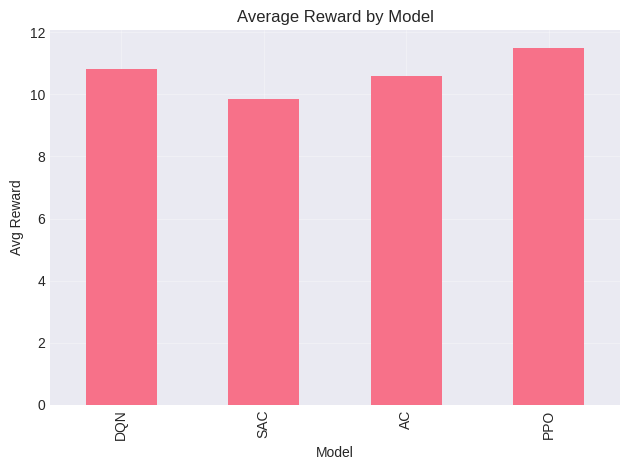

  return datetime.utcnow().replace(tzinfo=utc)



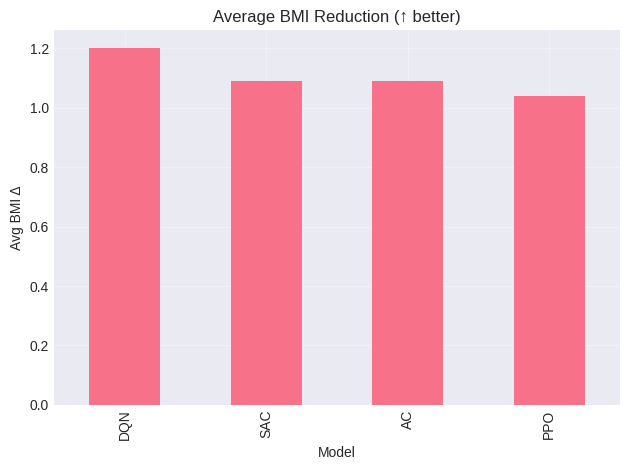

  return datetime.utcnow().replace(tzinfo=utc)



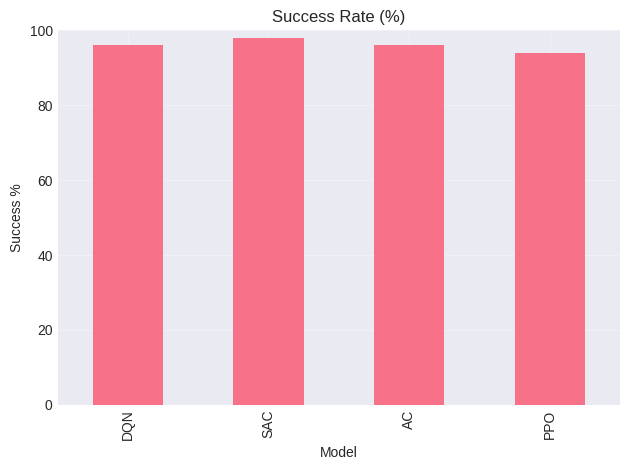

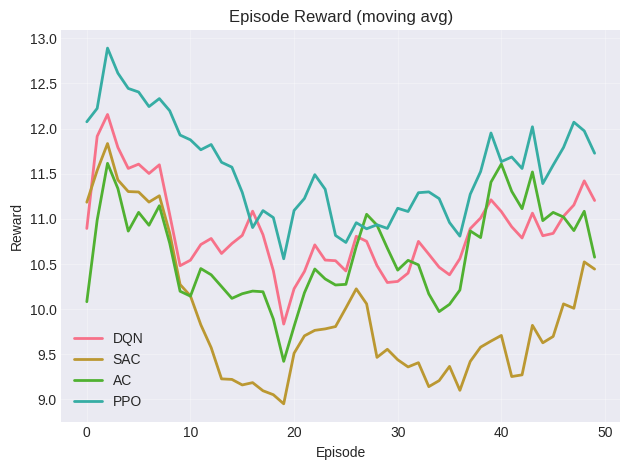

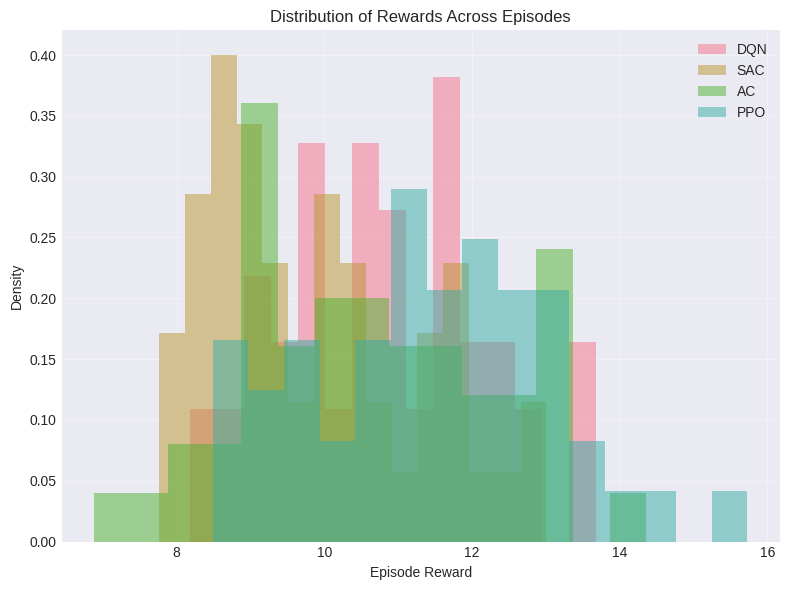

  plt.boxplot(reward_data, labels=list(policies.keys()), patch_artist=True)

  return datetime.utcnow().replace(tzinfo=utc)



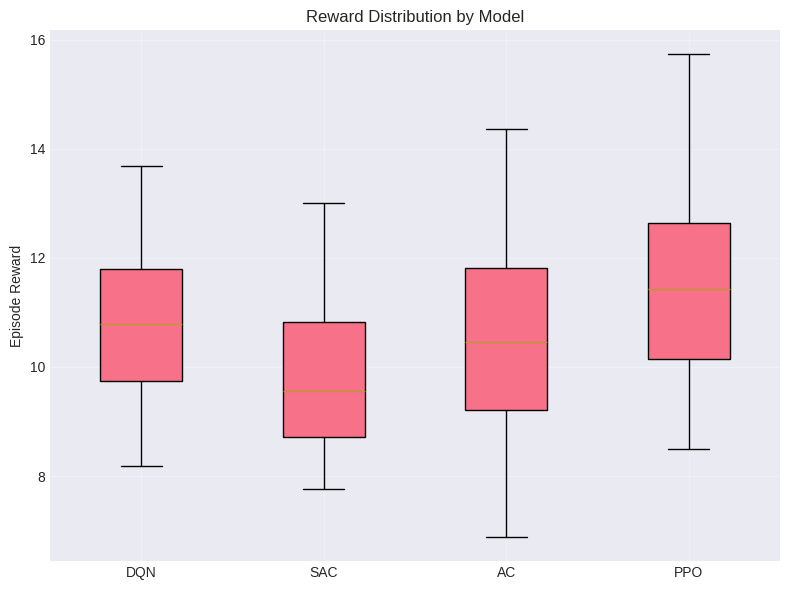

  return datetime.utcnow().replace(tzinfo=utc)




🔍 Best Model Based on Average Reward:
       Avg Reward  Std Reward  Avg BMI Δ  Avg Class Improve  Success Rate
Model                                                                    
PPO        11.485       1.631      1.041               0.34          0.94

🔍 Best Model Based on BMI Reduction:
       Avg Reward  Std Reward  Avg BMI Δ  Avg Class Improve  Success Rate
Model                                                                    
DQN        10.801       1.388      1.201               0.28          0.96

🔍 Best Model Based on Success Rate:
       Avg Reward  Std Reward  Avg BMI Δ  Avg Class Improve  Success Rate
Model                                                                    
SAC         9.846       1.393      1.092               0.22          0.98

🏆 Best Overall Model (based on combined score):
       Avg Reward  Std Reward  Avg BMI Δ  Avg Class Improve  Success Rate  \
Model                                                                       
DQN        10.801

In [62]:
# ---- Unified evaluation for DQN, PPO, AC, SAC ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# 1) A small helper to create a fresh env each time (same config for fairness)
def make_env(episode_len=30, difficulty="medium", seed=123):
    # If you already have create_health_coach_env, use it; else import/build your env accordingly.
    env = create_health_coach_env("DQN", episode_len=episode_len, difficulty=difficulty, seed=seed)
    return env

# 2) Policy adapters so all agents expose a single `policy(obs)` function
def policy_dqn(agent):
    # DQN: typically agent.act(state, training=False) or agent.select_action(...)
    def f(obs):
        return int(agent.act(obs, training=False)) if hasattr(agent, "act") else int(agent.select_action(obs, evaluate=True))
    return f

def policy_sac(agent):
    def f(obs):
        action = agent.select_action(obs, evaluate=True)
        if isinstance(action, (list, np.ndarray)):
            return int(action[0])
        elif isinstance(action, tuple):
            return int(action[0])
        return int(action)
    return f

def policy_ac(agent):
    def f(obs):
        # AC often returns (action, logp, value, extra)
        if hasattr(agent, "select_action"):
            a, *_ = agent.select_action(obs, explore=False)
            return int(a)
        # fallback if it exposes .act
        return int(agent.act(obs, training=False))
    return f

def policy_ppo(ppo_model):
    import torch
    def f(obs):
        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            probs, _ = ppo_model(obs_t)
            a = torch.distributions.Categorical(probs).sample().item()
        return int(a)
    return f

# 3) Gym/Gymnasium compatibility helpers
def reset_env(env):
    out = env.reset()
    if isinstance(out, tuple):  # gymnasium: (obs, info)
        return out[0]
    return out

def step_env(env, action):
    out = env.step(action)
    # unify returns: obs, reward, done, info
    if len(out) == 5:  # gymnasium
        obs, r, terminated, truncated, info = out
        done = bool(terminated or truncated)
        return obs, float(r), done, info
    else:
        obs, r, done, info = out
        return obs, float(r), bool(done), info

# 4) Single-agent evaluator (returns curves + summary)
def evaluate_agent(agent_name, policy_fn, episodes=50, episode_len=30, difficulty="medium", seed=1001):
    rewards, bmi_delta, class_improve, success = [], [], [], []
    # optional: collect per-episode curves if you want to plot learning-free rollouts
    for ep in range(episodes):
        env = make_env(episode_len=episode_len, difficulty=difficulty, seed=seed + ep)
        obs = reset_env(env)
        done = False
        ep_ret = 0.0
        start_bmi = None
        start_cls = None
        last_info = {}

        steps = 0
        while not done and steps < episode_len:
            a = policy_fn(obs)
            obs, r, done, info = step_env(env, a)
            ep_ret += r
            steps += 1
            last_info = info
            if start_bmi is None: start_bmi = info.get("bmi", None)
            if start_cls is None: start_cls = info.get("obesity_class", None)

        end_bmi = last_info.get("bmi", start_bmi)
        end_cls = last_info.get("obesity_class", start_cls)

        # KPI aggregation
        rewards.append(ep_ret)
        if (start_bmi is not None) and (end_bmi is not None):
            bmi_delta.append(float(start_bmi - end_bmi))  # positive = BMI reduced
        else:
            bmi_delta.append(0.0)

        if (start_cls is not None) and (end_cls is not None):
            class_improve.append(float(max(0, int(start_cls) - int(end_cls))))
        else:
            class_improve.append(0.0)

        success.append(1.0 if (bmi_delta[-1] > 0 or class_improve[-1] > 0) else 0.0)

    summary = {
        "Model": agent_name,
        "Avg Reward": np.mean(rewards),
        "Std Reward": np.std(rewards),
        "Avg BMI Δ": np.mean(bmi_delta),
        "Avg Class Improve": np.mean(class_improve),
        "Success Rate": np.mean(success),
    }
    curves = {
        "reward_curve": rewards,
        "bmi_curve": bmi_delta,
        "class_curve": class_improve,
        "success_curve": success,
    }
    return summary, curves

# 5) Plug in YOUR trained agents (rename these variables to your actual ones)
policies = {
    "DQN": policy_dqn(DQNmodel),
    "SAC": policy_sac(SACmodel),
    "AC" : policy_ac(ACmodel),
    "PPO": policy_ppo(PPOmodel),
}

# 6) Run the comparison
all_summaries = []
all_curves = {}

EPISODES = 50          # increase for more stable stats
EP_LEN   = 30
DIFF     = "medium"

for name, pol in policies.items():
    summary, curves = evaluate_agent(
        agent_name=name,
        policy_fn=pol,
        episodes=EPISODES,
        episode_len=EP_LEN,
        difficulty=DIFF,
        seed=999  # fixed seed base for reproducibility
    )
    all_summaries.append(summary)
    all_curves[name] = curves

# 7) Tabular summary
df = pd.DataFrame(all_summaries).set_index("Model").round(3)
print(df)

# 8) Quick visuals
plt.figure()
df["Avg Reward"].plot(kind="bar", title="Average Reward by Model")
plt.ylabel("Avg Reward"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plt.figure()
df["Avg BMI Δ"].plot(kind="bar", title="Average BMI Reduction (↑ better)")
plt.ylabel("Avg BMI Δ"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plt.figure()
(df["Success Rate"]*100).plot(kind="bar", title="Success Rate (%)")
plt.ylabel("Success %"); plt.ylim(0,100); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Optional: episode-wise reward curves (overlay, smoothed)
def moving_avg(x, k=7):
    if k <= 1: return x
    out = []
    s = 0.0; q=[]
    for v in x:
        q.append(v); s += v
        if len(q) > k: s -= q.pop(0)
        out.append(s/len(q))
    return out

plt.figure()
for name in policies.keys():
    r = all_curves[name]["reward_curve"]
    plt.plot(moving_avg(r, k=7), label=name, linewidth=2)
plt.title("Episode Reward (moving avg)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,6))
for name in policies.keys():
    rewards = all_curves[name]["reward_curve"]
    plt.hist(rewards, bins=15, alpha=0.5, label=name, density=True)

plt.title("Distribution of Rewards Across Episodes")
plt.xlabel("Episode Reward")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Alternatively: Boxplot view (to compare medians and spread)
plt.figure(figsize=(8,6))
reward_data = [all_curves[name]["reward_curve"] for name in policies.keys()]
plt.boxplot(reward_data, labels=list(policies.keys()), patch_artist=True)
plt.title("Reward Distribution by Model")
plt.ylabel("Episode Reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# === Show Best Models Based on Key Metrics ===
print("\n🔍 Best Model Based on Average Reward:")
print(df.sort_values("Avg Reward", ascending=False).head(1))

print("\n🔍 Best Model Based on BMI Reduction:")
print(df.sort_values("Avg BMI Δ", ascending=False).head(1))

print("\n🔍 Best Model Based on Success Rate:")
print(df.sort_values("Success Rate", ascending=False).head(1))

# If you want to highlight the *overall* best model, you can use a custom score
# e.g., weighted score combining all metrics:
df["Score"] = (
    df["Avg Reward"].rank(ascending=False) +
    df["Avg BMI Δ"].rank(ascending=False) +
    df["Success Rate"].rank(ascending=False)
)

best_overall = df.sort_values("Score", ascending=True).head(1)
print("\n🏆 Best Overall Model (based on combined score):")
print(best_overall)


Video

In [60]:
!pip install moviepy
import gym
from moviepy.editor import ImageSequenceClip
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294

In [84]:
from bisect import bisect_right
from moviepy.editor import ImageSequenceClip
from io import BytesIO
from PIL import Image
import os

# ---------------- BMI helpers (added) ----------------
BMI_BINS   = [0, 18.5, 25, 30, 35, 40, 100]
BMI_LABELS = ['Underweight', 'Normal', 'Overweight',
              'Obese_I', 'Obese_II', 'Obese_III']

def get_bmi_category(bmi: float) -> str:
    """Return label from fine-grained bins."""
    try:
        v = float(bmi)
    except Exception:
        v = 25.0
    idx = max(0, min(len(BMI_BINS)-2, bisect_right(BMI_BINS, v) - 1))
    return BMI_LABELS[idx]

def get_bmi_class(bmi: float) -> int:
    """Return integer class index 0..5 for bins above."""
    try:
        v = float(bmi)
    except Exception:
        v = 25.0
    idx = max(0, min(len(BMI_BINS)-2, bisect_right(BMI_BINS, v) - 1))
    return idx

# Optional: consistent colors per category
BMI_COLORS = {
    'Underweight': ('#87CEEB', '#4682B4'),
    'Normal'     : ('#98FB98', '#228B22'),
    'Overweight' : ('#F0E68C', '#DAA520'),
    'Obese_I'    : ('#FFC1A1', '#FF7F50'),
    'Obese_II'   : ('#FFB6C1', '#DC143C'),
    'Obese_III'  : ('#FFA3A3', '#B22222'),
}

# ---------------- text panel ----------------
def text_to_image(text: str, width=420, height=360):
    """Render multiline text into an RGB image of fixed size with constant font size."""
    fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)

    ax.text(0.02, 0.98, text,
            fontsize=14,
            ha='left', va='top',
            wrap=True,
            family='monospace')

    ax.axis('off')
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.05)
    buf.seek(0)
    img = Image.open(buf).convert("RGB")
    plt.close(fig)

    img = img.resize((width, height), Image.BICUBIC)
    return np.array(img, dtype=np.uint8)

# ---------------- simple hstack ----------------
def hstack_with_divider(left_img: np.ndarray, right_img: np.ndarray, pad_px=6):
    """Stack two HxWx3 frames with a light divider, resizing right to left's height if needed."""
    assert left_img.ndim == 3 and right_img.ndim == 3 and left_img.shape[2] == 3 and right_img.shape[2] == 3
    H = left_img.shape[0]
    if right_img.shape[0] != H:
        new_w = int(right_img.shape[1] * (H / right_img.shape[0]))
        right_img = np.array(Image.fromarray(right_img).resize((new_w, H), Image.BICUBIC))
    divider = np.full((H, pad_px, 3), 220, dtype=np.uint8)
    return np.concatenate([left_img, divider, right_img], axis=1)

def body_scale_from_bmi(bmi: float) -> float:
    """
    Map BMI to a width scale smoothly.
    Tuned so ~22 looks slim, 27 thicker, 35+ quite large, but clamped.
    """
    import numpy as np
    try:
        v = float(bmi)
        if np.isnan(v) or np.isinf(v):
            return default
    except Exception:
        v = 25.0
    # control points:   BMI -> width scale
    x = np.array([16, 18.5, 22, 25, 27, 30, 35, 40, 45], dtype=float)
    y = np.array([0.85, 0.95, 1.05, 1.15, 1.25, 1.40, 1.70, 1.95, 2.15], dtype=float)
    s = float(np.interp(v, x, y))
    return float(np.clip(s, 0.80, 2.20))

def _safe_bmi(x, default=25.0):
        try:
            v = float(x)
            if np.isnan(v) or np.isinf(v): return default
            return v
        except Exception:
            return default

# ---------------- person renderer (updated) ----------------
def render_person_with_bmi(bmi: float,
                           action: str,
                           width=640,
                           height=360,
                           prev_bmi: float = None):
    """Draw a person whose BODY is a CIRCLE; size & color vary with BMI."""
    bmi = _safe_bmi(bmi)

    fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    # --- size scaling (circle radius) ---
    scale = body_scale_from_bmi(bmi)        # ~0.8 .. 2.2
    torso_r = 0.85 * scale                  # main knob for body size
    head_r  = 0.38 + 0.08 * (scale - 1)     # modest head scaling

    # --- positions ---
    torso_cx, torso_cy = 5.0, 6.2           # center of torso circle
    head_cx, head_cy   = 5.0, torso_cy + torso_r + head_r + 0.25  # sit on top

    # --- colors from category ---
    cat_now = get_bmi_category(bmi)
    body_color, outline_color = BMI_COLORS.get(cat_now, ('#DDDDDD', '#555555'))

    # --- draw torso as a circle ---
    torso = plt.Circle((torso_cx, torso_cy), torso_r, fc=body_color, ec=outline_color, lw=2)
    ax.add_patch(torso)

    # --- draw head ---
    head = plt.Circle((head_cx, head_cy), head_r, fc='#FDBCB4', ec='black', lw=2)
    ax.add_patch(head)
    # eyes
    ax.plot([head_cx - 0.12, head_cx + 0.12], [head_cy + 0.10, head_cy + 0.10], 'ko', ms=3)
    # smile
    t = np.linspace(0.2*np.pi, 0.8*np.pi, 24)
    ax.plot(head_cx + 0.10*np.cos(t), head_cy - 0.02 + 0.07*np.sin(t), 'k-', lw=2)

    # --- arms (attach at torso sides) ---
    arm_len = 1.2
    shoulder_y = torso_cy + 0.45*torso_r
    shoulder_dx = 0.9*torso_r
    skin = '#FDBCB4'
    # left
    ax.plot([torso_cx - shoulder_dx, torso_cx - shoulder_dx - 0.7*arm_len],
            [shoulder_y, shoulder_y - 0.6], color=skin, lw=4)
    ax.plot([torso_cx - shoulder_dx - 0.7*arm_len, torso_cx - shoulder_dx - arm_len],
            [shoulder_y - 0.6, shoulder_y - 1.1], color=skin, lw=4)
    # right
    ax.plot([torso_cx + shoulder_dx, torso_cx + shoulder_dx + 0.7*arm_len],
            [shoulder_y, shoulder_y - 0.6], color=skin, lw=4)
    ax.plot([torso_cx + shoulder_dx + 0.7*arm_len, torso_cx + shoulder_dx + arm_len],
            [shoulder_y - 0.6, shoulder_y - 1.1], color=skin, lw=4)

    # --- legs (from bottom of torso) ---
    hip_y = torso_cy - 0.7*torso_r
    hip_dx = 0.55*torso_r
    # left leg
    ax.plot([torso_cx - hip_dx, torso_cx - hip_dx - 0.6],
            [hip_y, hip_y - 1.6], color=skin, lw=4)
    ax.plot([torso_cx - hip_dx - 0.6, torso_cx - hip_dx - 0.9],
            [hip_y - 1.6, hip_y - 3.0], color=skin, lw=4)
    # right leg
    ax.plot([torso_cx + hip_dx, torso_cx + hip_dx + 0.6],
            [hip_y, hip_y - 1.6], color=skin, lw=4)
    ax.plot([torso_cx + hip_dx + 0.6, torso_cx + hip_dx + 0.9],
            [hip_y - 1.6, hip_y - 3.0], color=skin, lw=4)

    # --- top badge ---
    top_text = f"Action: {action}"
    ax.text(5, 9.6, top_text, ha='center', va='center',
            fontsize=12, color='black',
            bbox=dict(boxstyle="round,pad=0.25", facecolor='white', alpha=0.9))

    # --- BMI line with deltas and class change ---
    cls_now = get_bmi_class(bmi)
    bmi_line = f"BMI: {bmi:.2f} ({cat_now})  |  Class: {cls_now}"
    if prev_bmi is not None:
        prev = _safe_bmi(prev_bmi)
        diff = bmi - prev
        if abs(diff) >= 0.01:
            sign = "+" if diff > 0 else "−"
            bmi_line += f"   Δ {sign}{abs(diff):.2f}"
        prev_cls = get_bmi_class(prev)
        if prev_cls != cls_now:
            bmi_line += f"   → Class {cls_now}"

    ax.text(5, 1.0, bmi_line, ha='center', va='center',
            fontsize=11, color='black',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='#FFF9C4', alpha=0.95))

    # --- render to array ---
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    img = Image.open(buf).convert("RGB").resize((width, height), Image.BICUBIC)
    arr = np.array(img, dtype=np.uint8)
    plt.close(fig)
    return arr

# ---------------- label action ----------------
def label_action(action):
    mapping = {
        0: "Reduce Sugar", 1: "More Veggies", 2: "Drink Water",
        3: "Cut Snacks", 4: "No Smoking", 5: "Screen Time↓",
        6: "Activity↑", 7: "Caloric Control"
    }
    try:
        return mapping.get(int(action), f"Action {int(action)}")
    except Exception:
        return str(action)

# ---------------- main recorder (hardened) ----------------
def record_text_based_env(env,
                          agent,
                          episodes=1,
                          max_steps=200,
                          filename="env_text_video.mp4",
                          fps=5,
                          left_w=640,
                          right_w=420,
                          video_h=360,
                          make_gif=False,
                          gif_name=None):
    """
    Record episodes as video with enhanced person visualization.
    LEFT: person_with_bmi | RIGHT: text info panel.
    Handles Gym (obs, reward, done, info) and Gymnasium (obs, reward, terminated, truncated, info).
    """
    frames = []
    prev_bmi = None

    for ep in range(episodes):
        reset_out = env.reset()
        obs = reset_out[0] if isinstance(reset_out, (tuple, list)) and len(reset_out) >= 1 else reset_out

        done = False
        step = 0
        while not done and step < max_steps:
            # action
            action_raw = agent.act(obs, training=False)
            action_name = label_action(action_raw)

            # step
            step_out = env.step(action_raw)
            if isinstance(step_out, (tuple, list)):
                if len(step_out) == 4:
                    obs, reward, done, info = step_out
                elif len(step_out) == 5:
                    obs, reward, terminated, truncated, info = step_out
                    done = bool(terminated or truncated)
                else:
                    # Unknown format – do a best-effort parse
                    obs = step_out[0]
                    reward = float(step_out[1]) if len(step_out) > 1 else 0.0
                    done = bool(step_out[2]) if len(step_out) > 2 else False
                    info = step_out[3] if len(step_out) > 3 else {}
            else:
                # Non-standard env; try to keep going
                reward, done, info = 0.0, False, {}

            # current BMI
            current_bmi = _safe_bmi(getattr(env, "_bmi", 25.0))

            # preview state
            if isinstance(obs, (list, tuple, np.ndarray)):
                st = np.array(obs).astype(np.float32).flatten()
                if st.size > 24:
                    st = st[:24]
                state_str = np.array2string(st, precision=3, threshold=24)
            else:
                state_str = str(obs)

            # text block
            bmi_change = ""
            class_change = ""
            if prev_bmi is not None:
                diff = current_bmi - prev_bmi
                if abs(diff) > 0.01:
                    bmi_change = f" ({diff:+.2f})"
                prev_cls = get_bmi_class(prev_bmi)
                curr_cls = get_bmi_class(current_bmi)
                if prev_cls != curr_cls:
                    class_change = f" -> Class {curr_cls}"

            capture_text = (
                f"Episode: {ep+1}/{episodes}\n"
                f"Step   : {step}/{max_steps}\n"
                f"Action : {action_name}\n"
                f"Reward : {float(reward):.2f}\n"
                f"BMI    : {current_bmi:.2f}{bmi_change}\n"
                f"Category: {get_bmi_category(current_bmi)}\n"
                f"Class  : {get_bmi_class(current_bmi)}{class_change}\n"
                f"Done   : {done}\n"
                f"State  : {state_str}\n"
            )

            left = render_person_with_bmi(current_bmi, action_name, width=left_w, height=video_h, prev_bmi=prev_bmi)
            right = text_to_image(capture_text, width=right_w, height=video_h)
            frame = hstack_with_divider(left, right, pad_px=6)
            frames.append(frame.astype(np.uint8))

            prev_bmi = current_bmi
            step += 1

        prev_bmi = None  # reset between episodes

    # Fallback if nothing recorded
    if not frames:
        frames = [text_to_image("No frames captured.\nCheck env/agent.", width=left_w + 6 + right_w, height=video_h)]

    # Create video (with codec fallback)
    clip = ImageSequenceClip(frames, fps=fps)
    out_path = os.path.abspath(filename)
    try:
        clip.write_videofile(out_path, codec="libx264", audio=False, verbose=False, logger=None)
    except Exception:
        # Fallback on systems lacking libx264
        alt = os.path.splitext(out_path)[0] + "_mpeg4.mp4"
        clip.write_videofile(alt, codec="mpeg4", audio=False, verbose=False, logger=None)
        out_path = alt

    # Optional GIF
    gif_out = None
    if make_gif:
        gif_out = os.path.abspath(gif_name or os.path.splitext(out_path)[0] + ".gif")
        try:
            clip.write_gif(gif_out, fps=min(fps, 8), program='ffmpeg')
        except Exception:
            # PIL fallback (slower)
            imgs = [Image.fromarray(f) for f in frames]
            imgs[0].save(gif_out, save_all=True, append_images=imgs[1:], duration=int(1000/fps), loop=0)

    # Clean up
    clip.close()

    print(f"Video saved: {out_path}")
    if gif_out:
        print(f"GIF saved  : {gif_out}")
    print(f"Total frames: {len(frames)} | Duration: {len(frames)/fps:.1f}s | Size: {frames[0].shape[1]}x{frames[0].shape[0]}")

    return out_path


In [91]:
# ---------------- Wrapper: record one agent ----------------
def record_env_frames(env, agent, label, steps=30, episodes=3, video_h=360, left_w=640, right_w=420):
    frames = []

    for ep in range(episodes):
        prev_bmi = None

        reset_out = env.reset()
        obs = reset_out[0] if isinstance(reset_out, (tuple, list)) else reset_out
        done = False
        step = 0

        while not done and step < steps:
            try:
                action_raw = agent(obs)
            except Exception as e:
                print(f"[{label} ep{ep+1}] Action error: {e}")
                break

            action_name = label_action(action_raw)

            step_out = env.step(action_raw)
            if isinstance(step_out, (tuple, list)):
                if len(step_out) == 4:
                    obs, reward, done, info = step_out
                elif len(step_out) == 5:
                    obs, reward, terminated, truncated, info = step_out
                    done = bool(terminated or truncated)
                else:
                    obs = step_out[0]
                    reward = float(step_out[1]) if len(step_out) > 1 else 0.0
                    done = bool(step_out[2]) if len(step_out) > 2 else False
                    info = step_out[3] if len(step_out) > 3 else {}
            else:
                reward, done, info = 0.0, False, {}

            current_bmi = _safe_bmi(getattr(env, "_bmi", 25.0))
            capture_text = (
                f"Agent  : {label}\n"
                f"Episode: {ep+1}\n"
                f"Step   : {step+1}/{steps}\n"
                f"Action : {action_name}\n"
                f"Reward : {float(reward):.2f}\n"
                f"BMI    : {current_bmi:.2f}\n"
                f"Category: {get_bmi_category(current_bmi)}\n"
                f"Class  : {get_bmi_class(current_bmi)}\n"
            )

            left = render_person_with_bmi(current_bmi, action_name, width=left_w, height=video_h, prev_bmi=prev_bmi)
            right = text_to_image(capture_text, width=right_w, height=video_h)
            frame = hstack_with_divider(left, right, pad_px=6)
            frames.append(frame.astype(np.uint8))

            prev_bmi = current_bmi
            step += 1

    return frames
def policy_dqn(agent):
    def f(obs):
        return int(agent.act(obs, training=False))
    return f

def policy_sac(agent):
    def f(obs):
        try:
            action = agent.select_action(obs, evaluate=True)
            if isinstance(action, (list, np.ndarray)):
                return int(action[0])
            else:
                return int(action)
        except Exception as e:
            print(f"[policy_sac] Error: {e}")
            return 0
    return f


def policy_ppo(agent):
    def f(obs):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            action_logits = agent.actor(obs_tensor)
            action_prob = torch.softmax(action_logits, dim=-1)
            action = torch.argmax(action_prob, dim=-1)
        return int(action.item())
    return f

def policy_ac(agent):
    def f(obs):
        try:
            # Run inference (no exploration)
            action, _, _, _ = agent.select_action(obs, explore=False)
            return int(action)
        except Exception as e:
            print(f"[policy_ac] Error: {e}")
            return 0
    return f



# ---------------- Run 4 agents in parallel ----------------
def record_4agent_grid_video(env_fn, DQNmodel, PPOmodel, ACmodel, SACmodel, steps=30, episodes=3, output="4models_comparison.mp4", fps=2):
    print("Recording agents...")
    agents = [
        ("DQN", DQNmodel),
        ("PPO", PPOmodel),
        ("AC", ACmodel),
        ("SAC", SACmodel),
    ]
    all_frames = []

    for name, agent in agents:
        env = env_fn()  # Fresh env per agent
        frames = record_env_frames(env, agent, label=name, steps=steps, episodes=episodes)
        all_frames.append(frames)

    min_len = min(len(frames) for frames in all_frames)
    all_frames = [frames[:min_len] for frames in all_frames]

    print("Assembling video grid...")
    grid_frames = []
    for i in range(min_len):
        row1 = [all_frames[0][i], all_frames[1][i]]
        row2 = [all_frames[2][i], all_frames[3][i]]
        clip = clips_array([[ImageSequenceClip([f], fps=fps) for f in row1],
                            [ImageSequenceClip([f], fps=fps) for f in row2]])
        frame = clip.get_frame(0)
        grid_frames.append(frame)

    print(f"Writing to {output}...")
    final_clip = ImageSequenceClip(grid_frames, fps=fps)
    final_clip.write_videofile(output, codec="libx264", audio=False, verbose=False, logger=None)
    print(f"✅ Video saved: {output}")

# ---------------- RUN THIS ----------------
# Ensure env_fn() returns a fresh env with fixed dataset/config
record_4agent_grid_video(
    env_fn=lambda: make_env(episode_len=30, difficulty="medium"),
    DQNmodel=policy_dqn(DQNmodel),
    PPOmodel=policy_ppo(PPOmodel),
    ACmodel=policy_ac(ACmodel),
    SACmodel=policy_sac(SACmodel),
    steps=30,
    episodes=6,
    output="4models_comparison.mp4",
    fps=1,
)


Recording agents...
Assembling video grid...
Writing to 4models_comparison.mp4...
✅ Video saved: 4models_comparison.mp4
